---

# A Retrieval-Augmented Generation (RAG) Approach to Financial
# Advisory in Ghana's Financial Sector

---

**Author:** Evans Ataaya  
**Degree:** MTech, Data Science and Industrial Analytics  
**Certifications:**  
- IBM Data Science Professional Certificate Coursera (December 2025)  
- IBM Generative AI Engineering Professional Certificate Coursera (April 2026)  

**Project Supervisor / Scrum Lead:** Claude (Anthropic)  
**Version:** v1.0  
**Date:** April 2026  

**GitHub Repository:** https://github.com/Evans-Ataaya/ghana-rag-financial-advisor

---

**Keywords:** retrieval-augmented generation, RAG, LangChain, vector database,
ChromaDB, financial advisory, Ghana, Bank of Ghana, financial inclusion,
natural language processing, large language models, financial regulation

---

## Abstract

Ghana's financial sector operates under a complex regulatory framework
spanning multiple regulatory bodies the Bank of Ghana, the Securities
and Exchange Commission, the National Insurance Commission, and the
National Pensions Regulatory Authority each producing legislation,
directives, and guidelines that govern financial activity across the
country. Despite achieving a 96% financial-service access rate, a
persistent information asymmetry exists between the availability of
regulatory knowledge and the public's ability to access and interpret it
for informed financial decision-making. This study develops a
Retrieval-Augmented Generation (RAG) system that ingests, indexes, and
retrieves information from a curated knowledge base of Ghana's financial
regulatory documents to provide accurate, contextual, and cited financial
advisory responses through a conversational interface. The system is built
using LangChain for orchestration, sentence-transformers for embedding
generation, ChromaDB for vector storage, and a large language model for
response generation. A comprehensive evaluation framework using the RAGAS
methodology assesses retrieval accuracy, response faithfulness, answer
relevancy, and context precision. The study compares multiple chunking
strategies and embedding approaches to identify the optimal configuration
for legal and regulatory document retrieval. The project contributes an
open-source, reproducible RAG pipeline designed explicitly for the
Ghanaian financial context, with direct applicability to comparable
regulatory environments across sub-Saharan Africa. A fully interactive
Streamlit chat interface is developed and deployed as a practical
financial information tool for citizens, fintech professionals, and
financial institutions.

In [1]:
# ============================================================
# SECTION 0 — ENVIRONMENT VERIFICATION
# Project: Ghana RAG Financial Advisor Bot
# Author: Evans Ataaya
# Date: April 2026
# ============================================================

import sys
print("=" * 55)
print("ENVIRONMENT VERIFICATION")
print("=" * 55)
print(f"Python        : {sys.version.split()[0]}")
print(f"Kernel        : ghana-portfolio")
print()

# --- Core Data Science ---
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import sklearn
print("--- Core Data Science ---")
print(f"pandas        : {pd.__version__}")
print(f"numpy         : {np.__version__}")
print(f"matplotlib    : {matplotlib.__version__}")
print(f"seaborn       : {sns.__version__}")
print(f"scikit-learn  : {sklearn.__version__}")
print()

# --- Document Processing ---
import pypdf
import pdfplumber
import bs4
import requests
print("--- Document Processing ---")
print(f"pypdf         : {pypdf.__version__}")
print(f"pdfplumber    : {pdfplumber.__version__}")
print(f"beautifulsoup : {bs4.__version__}")
print(f"requests      : {requests.__version__}")
print()

# --- LangChain Ecosystem ---
import langchain
import langchain_text_splitters
from importlib.metadata import version as pkg_version
print("--- LangChain Ecosystem ---")
print(f"langchain     : {langchain.__version__}")
print(f"text-splitter : {pkg_version('langchain-text-splitters')}")
print()

# --- Embeddings ---
import sentence_transformers
import tiktoken
print("--- Embeddings ---")
print(f"sentence-trans: {sentence_transformers.__version__}")
print(f"tiktoken      : {tiktoken.__version__}")
print()

# --- Vector Stores ---
import chromadb
import faiss
print("--- Vector Stores ---")
print(f"chromadb      : {chromadb.__version__}")
print(f"faiss-cpu     : {faiss.__version__}")
print()

# --- LLM Integration ---
import openai
print("--- LLM Integration ---")
print(f"openai        : {openai.__version__}")
print()

# --- Evaluation ---
import ragas
print("--- Evaluation ---")
print(f"ragas         : {ragas.__version__}")
print()

# --- UI Deployment ---
import streamlit
import gradio
print("--- UI Deployment ---")
print(f"streamlit     : {streamlit.__version__}")
print(f"gradio        : {gradio.__version__}")

print()
print("=" * 55)
print("✅ ALL PACKAGES VERIFIED SUCCESSFULLY")
print("=" * 55)

ENVIRONMENT VERIFICATION
Python        : 3.10.20
Kernel        : ghana-portfolio

--- Core Data Science ---
pandas        : 2.3.3
numpy         : 2.2.6
matplotlib    : 3.10.8
seaborn       : 0.13.2
scikit-learn  : 1.7.2

--- Document Processing ---
pypdf         : 6.9.2
pdfplumber    : 0.11.9
beautifulsoup : 4.14.3
requests      : 2.33.1

--- LangChain Ecosystem ---
langchain     : 1.2.15
text-splitter : 1.1.1

--- Embeddings ---
sentence-trans: 5.3.0
tiktoken      : 0.12.0

--- Vector Stores ---
chromadb      : 1.5.7
faiss-cpu     : 1.13.2

--- LLM Integration ---
openai        : 2.31.0

--- Evaluation ---
ragas         : 0.4.3

--- UI Deployment ---
streamlit     : 1.56.0
gradio        : 6.11.0

✅ ALL PACKAGES VERIFIED SUCCESSFULLY


## Section 1 - Introduction

### 1.1 Background
Ghana's financial sector has undergone one of the most significant digital transformations in Africa over the past decade. Mobile money transaction values surpassed approximately 300 billion US dollars annually by 2025, active mobile money accounts reached 26.7 million, and the country achieved first place globally on the GSMA Mobile Money Regulatory Index with a score of 95.06%. This growth has been driven by the proliferation of mobile money platforms such as MTN MoMo, Telecel Cash, and AirtelTigo Money, the expansion of digital payment infrastructure, and an evolving regulatory landscape designed to balance innovation with consumer protection.

However, the complexity and pace of regulatory development have created a significant information asymmetry between regulators, financial institutions, and the general public. The Bank of Ghana, the Securities and Exchange Commission (SEC), the National Insurance Commission (NIC), the National Pensions Regulatory Authority (NPRA), and the Ministry of Finance collectively produce a vast corpus of legislation, directives, guidelines, and educational materials governing every aspect of financial activity in the country. From the Payment Systems and Services Act of 2019 (Act 987) to the newly launched Cyber and Information Security Directive (CISD) 2026, the regulatory framework is both comprehensive and continually evolving.

For the average Ghanaian citizen, small business owner, or emerging fintech professional, navigating this regulatory and financial landscape presents formidable challenges. Questions such as "How do I invest in Treasury bills?", "What are the requirements for a digital lending licence?", "How does the three-tier pension system work?", or "What protections exist for mobile money users?" require accessing, interpreting, and synthesising information from multiple regulatory sources, a task that is both time-consuming and prone to error.

Simultaneously, the field of artificial intelligence has witnessed the emergence of Retrieval-Augmented Generation (RAG), an architecture that addresses the fundamental limitations of large language models (LLMs) by grounding their responses in authoritative, domain-specific knowledge sources retrieved at query time. Unlike traditional chatbots that rely solely on pre-trained knowledge which may be outdated, generic, or hallucinatory. RAG systems retrieve verified, contextually relevant documents before generating responses, ensuring accuracy, currency, and traceability.

This project, applies the RAG architecture to build an intelligent Financial Advisor Bot specifically designed for the Ghanaian financial context. The system ingests and indexes authoritative documents from Ghana's key financial regulators, enabling users to query a conversational interface that provides accurate, cited, and contextually appropriate financial guidance grounded in the country's actual regulatory framework.

### 1.2 Problem Statement
Despite Ghana's impressive strides in digital financial inclusion achieving a reported 96% financial-service access rate a persistent gap remains between the availability of financial services and the public's ability to make informed financial decisions. This gap manifests in several interconnected challenges.

First, information fragmentation: Ghana's financial regulatory corpus is distributed across multiple regulatory bodies (Bank of Ghana, SEC, NIC, NPRA), each publishing documents in different formats, on separate platforms, and with varying degrees of accessibility. There is no unified, queryable interface for citizens to access authoritative financial guidance.

Second, regulatory complexity: legislation such as the Payment Systems and Services Act (Act 987), the Securities Industry Act (Act 929), and the Anti-Money Laundering Act (Act 1044) employ dense legal language that is inaccessible to non-specialist users. Over 150 active digital loan applications operate in Ghana, yet many users lack understanding of their regulatory protections under the Digital Credit Directive.

Third, financial literacy deficit: while the Bank of Ghana has invested in financial literacy programmes, these materials are often static, one-directional, and unable to address the specific, contextual questions that individual users have about their unique financial situations.

Fourth, generic AI limitations: standard LLM-based chatbots, when applied to Ghana-specific financial queries, frequently produce responses based on generic global financial knowledge that may not reflect Ghana's specific regulatory requirements, interest rates, tax structures, or institutional arrangements. This can lead to misinformation and poor financial decision-making.

Fifth, trust and accountability: in the financial advisory domain, the provenance of information is critically important. Users, regulators, and institutions need to verify that any AI-generated advice is grounded in authoritative sources, with clear citation trails linking responses to specific regulatory documents.

### 1.3 Research Objectives
This project pursues the following objectives:
1. To collect, preprocess, and organise a comprehensive knowledge base of Ghana's financial regulatory documents spanning six knowledge domains: regulatory framework, digital financial services, investment and securities, financial inclusion, consumer protection, and fintech innovation.
2. To design and implement an optimal document chunking and embedding pipeline that preserves regulatory context and enables accurate semantic retrieval from the knowledge base.
3. To build a RAG retrieval chain integrating vector similarity search with metadata filtering, connected to a large language model capable of generating grounded, cited responses in natural language.
4. To develop a comprehensive evaluation framework assessing retrieval accuracy, response faithfulness, answer relevancy, context precision, and citation accuracy using the RAGAS evaluation methodology.
5. To deploy an interactive chat interface enabling users to query the system on Ghana-specific financial topics and receive responses with source attribution and confidence indicators.

### 1.4 Scope of the Study
This study focuses on the Ghanaian financial sector, specifically targeting documents produced by the Bank of Ghana, the Securities and Exchange Commission, the National Insurance Commission, the National Pensions Regulatory Authority, the Ministry of Finance, and the Ghana Stock Exchange. The knowledge base encompasses legislation, directives, guidelines, policy documents, educational materials, and statistical reports published in English.

The system is designed as a financial information and education tool, not as a licensed financial advisory service. All responses include disclaimers directing users to seek professional financial advice for specific investment or regulatory compliance decisions. The RAG system does not process real-time market data, execute financial transactions, or access users' personal financial information.

The current implementation supports English-language queries and documents. Future work (discussed in Section 5) proposes multilingual expansion to Ghanaian languages including Twi, Ewe, and Dagbani to enhance accessibility for non-English-speaking populations.

### 1.5 Significance of the Study
This project holds significance at multiple levels.

At the academic level, empirical evidence on the effectiveness of RAG architectures for regulatory and legal document retrieval in an African financial context, contributing to the growing body of literature on domain-specific RAG applications. It offers comparative analysis of chunking strategies and embedding models specifically evaluated against regulatory text, a document genre underrepresented in current RAG research.

At the practical level, the deployed system serves as a prototype for a nationally scalable financial literacy tool that could be adopted or adapted by the Bank of Ghana, SEC, or other regulatory bodies to improve public access to financial information. By democratising access to regulatory knowledge, the system has the potential to reduce information asymmetry and empower citizens to make more informed financial decisions.

At the policy level, the project aligns with Ghana's Digital Financial Services Policy goal of creating a digitally empowered citizenry and the Bank of Ghana's emphasis on financial literacy as essential to the success of the country's cash-lite and inclusive financial agenda. The system demonstrates how AI can be responsibly deployed in regulated environments with appropriate safeguards for accuracy and attribution.

At the portfolio level, as the second project in the Ghana Financial Sector portfolio, this work builds on the credit risk scoring model developed in Project 1 and establishes the natural language processing and generative AI capabilities that will be extended in subsequent projects addressing fraud detection, customer segmentation, economic forecasting, and financial dashboard development.

### 1.6 Research Questions
This study is guided by the following research questions:
1. How effectively can a RAG-based system retrieve contextually relevant information from Ghana's fragmented financial regulatory corpus to answer domain-specific queries?
2. What chunking strategy (fixed-size, recursive character, or semantic) yields the highest retrieval precision and response faithfulness for legal and regulatory documents?
3. To what extent does grounding LLM responses in Ghana-specific regulatory documents reduce hallucination and improve factual accuracy compared to ungrounded responses?
4. How do users perceive the quality, trustworthiness, and usefulness of RAG-generated financial advisory responses when source citations are provided?

### 1.7 Organisation of the Report
This report is organised into seven sections.
- Section 1: presents the introduction, background, problem statement, and research objectives.
- Section 2: reviews relevant literature on RAG architectures, vector databases, financial chatbots in Africa, and Ghana's regulatory landscape.
- Section 3: details the document collection pipeline, chunking strategies, embedding generation, vector store design, RAG retrieval chain, and evaluation framework.
- Section 4: presents the results, retrieval accuracy analysis, response quality evaluation, and comparative analysis of chunking and embedding approaches.
- Section 5: offers recommendations for deployment, multilingual expansion, regulatory compliance, and ethical AI considerations, discusses limitations, and outlines directions for future work.
- Section 6: provides the complete reference list for all citations used throughout the report.
- Section 7: contains the project appendix including the GitHub repository, document corpus metadata, system prompts, evaluation rubrics, and software environment.

### 1.8 Document Corpus Registry
The following table documents all source materials targeted for the RAG knowledge base, organised by knowledge domain. Each document has been identified through systematic review of publications from Ghana's financial regulatory bodies.

**Domain 1: Regulatory Framework**

| # | Document Title | Regulatory Body | Year | Type |
|---|---|---|---|---|
| 1 | Payment Systems and Services Act, 2019 (Act 987) | Bank of Ghana | 2019 | Legislation |
| 2 | Banks and Specialised Deposit-Taking Institutions Act, 2016 (Act 930) | Bank of Ghana | 2016 | Legislation |
| 3 | Anti-Money Laundering Act, 2020 (Act 1044) | Bank of Ghana | 2020 | Legislation |
| 4 | Securities Industry Act, 2016 (Act 929) | SEC Ghana | 2016 | Legislation |
| 5 | Insurance Act, 2021 (Act 1061) | National Insurance Commission | 2021 | Legislation |
| 6 | Cyber and Information Security Directive (CISD) 2026 | Bank of Ghana | 2026 | Directive |
| 7 | Bank of Ghana Annual Report and Financial Stability Report | Bank of Ghana | 2025 | Annual Report |

**Domain 2: Digital Financial Services**

| # | Document Title | Regulatory Body | Year | Type |
|---|---|---|---|---|
| 8 | Digital Financial Services (DFS) Policy | Ministry of Finance | 2020 | Policy Document |
| 9 | Digital Credit Directive | Bank of Ghana | 2025 | Directive |
| 10 | National Payment Systems Strategy 2025–2029 | Bank of Ghana | 2025 | Policy Document |
| 11 | Mobile Money and Electronic Money Issuers Guidelines | Bank of Ghana | 2021 | Guideline |

**Domain 3: Investment and Securities**

| # | Document Title | Regulatory Body | Year | Type |
|---|---|---|---|---|
| 12 | SEC Investment Guidelines for Fund Managers | SEC Ghana | 2022 | Guideline |
| 13 | Securities Industry (Financial Resources) Guidelines, 2025 | SEC Ghana | 2025 | Guideline |
| 14 | SEC FAQs on Collective Investment Schemes (Mutual Funds and Unit Trusts) | SEC Ghana | 2024 | FAQ Document |
| 15 | Ghana Stock Exchange Listing Rules | Ghana Stock Exchange | 2023 | Guideline |

**Domain 4: Financial Inclusion**

| # | Document Title | Regulatory Body | Year | Type |
|---|---|---|---|---|
| 16 | National Financial Inclusion and Development Strategy (NFIDS) 2018–2023 | Ministry of Finance | 2018 | Policy Document |
| 17 | National Pensions Act, 2008 (Act 766) and NPRA Investment Guidelines | NPRA | 2008 | Legislation |
| 18 | Microfinance and Small Loans Centre (MASLOC) Guidelines | Ministry of Finance | 2020 | Guideline |
| 19 | Bank of Ghana Financial Literacy Programme Materials | Bank of Ghana | 2024 | Educational Material |

**Domain 5: Consumer Protection**

| # | Document Title | Regulatory Body | Year | Type |
|---|---|---|---|---|
| 20 | Bank of Ghana Consumer Recourse and Complaints Guidelines | Bank of Ghana | 2023 | Guideline |
| 21 | Data Protection Act, 2012 (Act 843) | Data Protection Commission | 2012 | Legislation |

**Domain 6: Fintech Innovation**

| # | Document Title | Regulatory Body | Year | Type |
|---|---|---|---|---|
| 22 | Bank of Ghana Fintech and Innovation Office Publications | Bank of Ghana | 2024 | Policy Document |
| 23 | Virtual Asset Service Providers Bill, 2025 | Bank of Ghana | 2025 | Legislation |
| 24 | eCedi Central Bank Digital Currency (CBDC) Pilot Documentation | Bank of Ghana | 2024 | Research Paper |
| 25 | Corporate Governance Guidelines for Payment Service Providers (2025) | Bank of Ghana | 2025 | Guideline |

**Corpus Summary:**
- Total documents: 25
- Knowledge domains: 6
- Regulatory bodies: 7 (Bank of Ghana, SEC Ghana, NIC, NPRA, Ministry of Finance, Ghana Stock Exchange, Data Protection Commission)
- Document types: 7 (Legislation, Directive, Guideline, Policy Document, Annual Report, FAQ Document, Educational Material, Research Paper)
- Primary regulator: Bank of Ghana (14 documents)
- Date range: 2008–2026

## Section 2 - Literature Review

### 2.1 Introduction to Literature Review
The application of Retrieval-Augmented Generation to domain-specific knowledge systems has attracted substantial academic and industry attention since the publication of the foundational RAG paper by Lewis et al. (2020). This section reviews the theoretical foundations of RAG architectures, examines the evolution of vector databases and embedding models, surveys financial chatbot implementations in African contexts, and analyses Ghana's financial regulatory landscape as the target domain for this system. The review draws from peer-reviewed journals, institutional reports, technical documentation, and policy documents relevant to financial inclusion and AI-powered advisory systems in sub-Saharan Africa.

### 2.2 Theoretical Foundations of Retrieval-Augmented Generation
Retrieval-Augmented Generation was formally introduced by Lewis et al. (2020) in their paper "Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks," which demonstrated that combining a pre-trained sequence-to-sequence model with a dense vector retrieval mechanism significantly improved performance on knowledge-intensive tasks such as open-domain question answering, fact verification, and knowledge-grounded dialogue generation. The architecture addressed a fundamental limitation of large language models: their reliance on parametric knowledge encoded during pre-training, which becomes static, potentially outdated, and prone to hallucination when applied to specialised or rapidly evolving domains.

The RAG architecture consists of three core components. First, a retriever that converts user queries and document passages into dense vector representations and performs similarity search to identify the most relevant passages from a knowledge corpus. Second, a knowledge store typically a vector database, that indexes document embeddings for efficient retrieval. Third, a generator a large language model, that receives both the original query and the retrieved passages as context, producing a response grounded in the retrieved evidence rather than relying solely on its parametric memory.

Since 2020, the RAG paradigm has evolved significantly. Gao et al. (2024) provide a comprehensive survey categorising RAG systems into three generations: Naive RAG (simple retrieve-then-generate), Advanced RAG (incorporating query rewriting, re-ranking, and hybrid retrieval), and Modular RAG (composable pipelines with routing, filtering, and iterative refinement). The current state of the art in 2026 emphasises hybrid retrieval combining sparse keyword search (BM25) with dense semantic search, multi-step retrieval chains, and agentic RAG systems that dynamically select retrieval strategies based on query complexity.

### 2.3 Vector Databases and Embedding Models
The retrieval component of a RAG system depends on two critical technologies: embedding models that convert text into dense vector representations, and vector databases that store and search these representations efficiently.

Embedding models transform text passages into fixed-dimensional vectors in a continuous vector space, where semantic similarity between texts is captured by the geometric distance between their vector representations. The Sentence-BERT framework (Reimers and Gurevych, 2019) established the approach of fine-tuning pre-trained transformer models specifically for producing semantically meaningful sentence-level embeddings. Popular open-source models include all-MiniLM-L6-v2 (384 dimensions, optimised for speed) and all-mpnet-base-v2 (768 dimensions, optimised for quality), both available through the sentence-transformers library. OpenAI's text-embedding-ada-002 offers a proprietary alternative with 1536-dimensional embeddings, widely adopted in commercial applications.

Vector databases provide the indexing and search infrastructure for embedding-based retrieval. ChromaDB is an open-source, lightweight vector database designed for AI applications that supports metadata filtering alongside semantic search, a capability critical for regulatory document retrieval where users may need to filter by regulatory body, document type, or date. FAISS (Facebook AI Similarity Search) is a high-performance library optimised for billion-scale similarity search using techniques such as inverted file indexing and product quantisation (Johnson et al., 2019). Other notable vector databases include Pinecone, Weaviate, and Milvus, each offering different trade-offs between ease of use, scalability, and feature richness.

The choice of chunking strategy how documents are split into retrievable units has a direct impact on retrieval quality. Langchain documentation and empirical studies suggest that recursive character splitting, which respects document structure by splitting at paragraph boundaries before falling back to sentence and word boundaries, outperforms fixed-size chunking for structured documents such as legal texts and regulatory guidelines. Chunk sizes between 500 and 1500 tokens with 10-20% overlap represent the commonly recommended range, though optimal parameters are domain-dependent and require empirical evaluation.

### 2.4 Financial Chatbots and AI Advisory Systems in Africa
The application of AI-powered chatbots in African financial services has grown significantly, driven by high mobile phone penetration, expanding digital financial services, and the need to serve large populations with limited access to human financial advisors.

In Nigeria, several commercial banks have deployed AI chatbots for customer service, with Access Bank's "Tamada" and UBA's "Leo" handling basic banking queries, account inquiries, and transaction support. These systems, however, rely on intent-classification architectures rather than RAG, limiting their ability to provide nuanced, document-grounded responses to complex regulatory or investment questions.

In Kenya, the Central Bank's digital literacy initiatives have explored AI-assisted financial education, though deployments remain largely rule-based. M-Pesa's integration of AI-powered fraud detection represents a more advanced application of machine learning in East African financial services, though it operates in the transaction monitoring rather than advisory domain.

Academic literature on RAG-based financial advisory systems in Africa remains sparse, representing a significant research gap. Most published RAG implementations focus on North American and European regulatory contexts (particularly SEC filings, EU regulations, and banking compliance documentation), with limited attention to the unique characteristics of African regulatory environments including multilingual documentation, evolving digital finance frameworks, and the intersection of formal regulation with informal financial practices.

### 2.5 Ghana's Financial Regulatory Landscape
Ghana's financial regulatory architecture is characterised by a multi-body supervisory framework with the Bank of Ghana serving as the primary regulator. The regulatory landscape relevant to this study encompasses several key areas.

The Payment Systems and Services Act of 2019 (Act 987) established the foundational regulatory framework for payment systems and electronic money services in Ghana, providing for the licensing and oversight of payment service providers and dedicated electronic money issuers. This legislation is particularly significant in the context of Ghana's mobile money revolution, where transaction values have reached trillions of cedis annually.

The Bank of Ghana's Digital Credit Directive, operationalised from November 2025, addresses the rapid growth of digital lending by requiring licensing for digital credit service providers, establishing minimum capital requirements of 2 million cedis, imposing transaction limits, and prohibiting harassment tactics in debt collection. This directive represents one of the most comprehensive digital lending regulatory frameworks in the region.

The Cyber and Information Security Directive (CISD) 2026, launched in March 2026, introduces governance frameworks for artificial intelligence, stricter cloud security requirements, risk-based regulatory approaches, and mandatory board-level accountability for cybersecurity across all financial institutions. The directive also expands the Financial Industry Security Operations Centre (FICSOC) to include all financial institutions in a coordinated national defence system.

The Securities and Exchange Commission (SEC) Ghana regulates the capital market under the Securities Industry Act of 2016 (Act 929), overseeing broker-dealers, investment advisers, mutual funds, unit trusts, and the Ghana Stock Exchange. The SEC's Investment Guidelines for Fund Managers and the Securities Industry (Financial Resources) Guidelines of 2025 establish capital requirements and investment standards for market operators.

Ghana's three-tier pension system, established under the National Pensions Act of 2008 (Act 766), comprises the mandatory Social Security and National Insurance Trust (SSNIT) scheme, occupational pension schemes, and voluntary provident funds, regulated by the National Pensions Regulatory Authority (NPRA).

### 2.6 Identified Research Gaps
The review of existing literature reveals three critical gaps that this study addresses.

First, there is a near-total absence of RAG-based financial advisory systems designed for African regulatory contexts. Existing RAG implementations in finance focus on Western regulatory frameworks, leaving African financial ecosystems with their unique mix of formal regulation, mobile money dominance, and rapid fintech evolution unserved.

Second, the intersection of regulatory document retrieval and conversational AI has not been explored in the Ghanaian context. While the Bank of Ghana and SEC publish extensive documentation, no system exists to make this knowledge interactively queryable by the general public.

Third, empirical evaluation of chunking strategies and embedding models for legal and regulatory text in African languages and regulatory styles is absent from the literature. This study contributes the first such comparative analysis in a West African financial context.

### 2.7 Theoretical Framework
This study is anchored in three theoretical pillars.

The RAG Architecture Framework (Lewis et al., 2020) provides the system design foundation, defining the retrieve-then-generate pipeline that grounds language model outputs in authoritative retrieved evidence.

The Information Retrieval Theory (Manning et al., 2008) provides the retrieval methodology foundation, encompassing vector space models, semantic similarity measures, and relevance ranking that underpin the embedding and search components of the system.

The Financial Inclusion Framework (World Bank, 2022; Bank of Ghana DFS Policy, 2020) provides the domain context, positioning financial information accessibility as a critical enabler of meaningful financial inclusion beyond mere account ownership.

### 2.8 Summary of the Literature Review
This review has established that RAG architectures represent the current state of the art for building knowledge-grounded conversational AI systems, with vector databases and transformer-based embedding models providing the retrieval infrastructure. It has identified a clear gap in Africa-specific, and particularly Ghana-specific, RAG implementations for financial advisory purposes. The theoretical framework combining RAG architecture, information retrieval theory, and financial inclusion positions this study at the intersection of cutting-edge AI technology and practical developmental impact. Section 3 proceeds to detail the data collection and methodology through which this framework is operationalised.

## Section 3 - Data and Methodology

### 3.1 Introduction to the Methodology
This section describes the document collection pipeline, text extraction and preprocessing procedures, knowledge base taxonomy design, chunking strategy, embedding generation approach, vector store architecture, RAG retrieval chain design, LLM integration, and evaluation framework employed in this study. The methodology follows a systematic pipeline approach encompassing document acquisition, preprocessing, indexing, retrieval, generation, and evaluation phases.

### 3.2 Document Sources and Knowledge Base Design
The knowledge base for this study comprises 25 documents sourced from seven Ghanaian financial regulatory bodies, organised into six knowledge domains as documented in Section 1.8. The documents were obtained through direct download from official regulatory websites, including the Bank of Ghana (bog.gov.gh), the Securities and Exchange Commission Ghana (sec.gov.gh), the Ministry of Finance (mofep.gov.gh), the National Pensions Regulatory Authority (npra.gov.gh), and the Ghana Stock Exchange (gse.com.gh). Document formats include PDF (primary), HTML web pages, and structured text.

### 3.3 Document Acquisition

In [2]:
# ============================================================
# SECTION 3 — DATA AND METHODOLOGY
# Project: Ghana RAG Financial Advisor Bot
# Author: Evans Ataaya
# Date: April 2026
# ============================================================

# --- 3.3 Import Libraries ---
import pandas as pd
import numpy as np
import os
import json
import requests
import hashlib
import warnings
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

# Project directories
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('data/vectorstore', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('config', exist_ok=True)

print("=" * 55)
print("LIBRARIES IMPORTED SUCCESSFULLY")
print("=" * 55)
print(f"pandas        : {pd.__version__}")
print(f"numpy         : {np.__version__}")
print(f"Working dir   : {os.getcwd()}")
print(f"Date          : {datetime.now().strftime('%Y-%m-%d %H:%M')}")

LIBRARIES IMPORTED SUCCESSFULLY
pandas        : 2.3.3
numpy         : 2.2.6
Working dir   : C:\Users\Ivan\anaconda3\conda-meta\ghana-rag-financial-advisor
Date          : 2026-04-09 02:12


In [3]:
# --- 3.4 Build Document Corpus Registry ---
# Each document is catalogued with metadata for retrieval,
# filtering, and citation tracking throughout the RAG pipeline.

corpus_registry = [
    # === DOMAIN 1: REGULATORY FRAMEWORK ===
    {
        "doc_id": "REG-001",
        "title": "Payment Systems and Services Act, 2019 (Act 987)",
        "domain": "Regulatory Framework",
        "doc_type": "Legislation",
        "regulatory_body": "Bank of Ghana",
        "year": 2019,
        "url": "https://www.bog.gov.gh/wp-content/uploads/2019/08/Payment-Systems-and-Services-Act-2019-Act-987-.pdf",
        "keywords": ["payment systems", "electronic money", "licensing",
                      "mobile money", "consumer protection"],
    },
    {
        "doc_id": "REG-002",
        "title": "Banks and Specialised Deposit-Taking Institutions Act, 2016 (Act 930)",
        "domain": "Regulatory Framework",
        "doc_type": "Legislation",
        "regulatory_body": "Bank of Ghana",
        "year": 2016,
        "url": "https://www.bog.gov.gh",
        "keywords": ["banking", "deposit-taking", "capital requirements",
                      "corporate governance", "prudential regulation"],
    },
    {
        "doc_id": "REG-003",
        "title": "Anti-Money Laundering Act, 2020 (Act 1044)",
        "domain": "Regulatory Framework",
        "doc_type": "Legislation",
        "regulatory_body": "Bank of Ghana",
        "year": 2020,
        "url": "https://www.bog.gov.gh",
        "keywords": ["anti-money laundering", "AML", "KYC",
                      "virtual assets", "suspicious transactions"],
    },
    {
        "doc_id": "REG-004",
        "title": "Securities Industry Act, 2016 (Act 929)",
        "domain": "Regulatory Framework",
        "doc_type": "Legislation",
        "regulatory_body": "SEC Ghana",
        "year": 2016,
        "url": "https://sec.gov.gh",
        "keywords": ["securities", "capital market", "mutual funds",
                      "broker-dealer", "investment adviser"],
    },
    {
        "doc_id": "REG-005",
        "title": "Insurance Act, 2021 (Act 1061)",
        "domain": "Regulatory Framework",
        "doc_type": "Legislation",
        "regulatory_body": "National Insurance Commission",
        "year": 2021,
        "url": "https://nicgh.org",
        "keywords": ["insurance", "insurtech", "microinsurance",
                      "risk-based capital", "policyholder protection"],
    },
    {
        "doc_id": "REG-006",
        "title": "Cyber and Information Security Directive (CISD) 2026",
        "domain": "Regulatory Framework",
        "doc_type": "Directive",
        "regulatory_body": "Bank of Ghana",
        "year": 2026,
        "url": "https://www.bog.gov.gh",
        "keywords": ["cybersecurity", "AI governance", "cloud security",
                      "FICSOC", "board accountability"],
    },
    {
        "doc_id": "REG-007",
        "title": "Bank of Ghana Annual Report and Financial Stability Report",
        "domain": "Regulatory Framework",
        "doc_type": "Annual Report",
        "regulatory_body": "Bank of Ghana",
        "year": 2025,
        "url": "https://www.bog.gov.gh",
        "keywords": ["annual report", "financial stability",
                      "monetary policy", "banking sector performance"],
    },

    # === DOMAIN 2: DIGITAL FINANCIAL SERVICES ===
    {
        "doc_id": "DFS-001",
        "title": "Digital Financial Services (DFS) Policy",
        "domain": "Digital Financial Services",
        "doc_type": "Policy Document",
        "regulatory_body": "Ministry of Finance",
        "year": 2020,
        "url": "https://www.mofep.gov.gh/sites/default/files/acts/Ghana_DFS_Policy.pdf",
        "keywords": ["digital financial services", "financial inclusion",
                      "digital payments", "interoperability", "cash-lite"],
    },
    {
        "doc_id": "DFS-002",
        "title": "Digital Credit Directive",
        "domain": "Digital Financial Services",
        "doc_type": "Directive",
        "regulatory_body": "Bank of Ghana",
        "year": 2025,
        "url": "https://www.bog.gov.gh",
        "keywords": ["digital credit", "digital lending",
                      "consumer protection", "credit bureau", "licensing"],
    },
    {
        "doc_id": "DFS-003",
        "title": "National Payment Systems Strategy 2025-2029",
        "domain": "Digital Financial Services",
        "doc_type": "Policy Document",
        "regulatory_body": "Bank of Ghana",
        "year": 2025,
        "url": "https://www.bog.gov.gh",
        "keywords": ["payment systems", "interoperability",
                      "open banking", "digital payments innovation"],
    },
    {
        "doc_id": "DFS-004",
        "title": "Mobile Money and Electronic Money Issuers Guidelines",
        "domain": "Digital Financial Services",
        "doc_type": "Guideline",
        "regulatory_body": "Bank of Ghana",
        "year": 2021,
        "url": "https://www.bog.gov.gh",
        "keywords": ["mobile money", "MTN MoMo", "Vodafone Cash",
                      "AirtelTigo Money", "agent network", "transaction limits"],
    },

    # === DOMAIN 3: INVESTMENT AND SECURITIES ===
    {
        "doc_id": "INV-001",
        "title": "SEC Investment Guidelines for Fund Managers",
        "domain": "Investment and Securities",
        "doc_type": "Guideline",
        "regulatory_body": "SEC Ghana",
        "year": 2022,
        "url": "https://sec.gov.gh/wp-content/uploads/Final-Regulatory-Laws/Guidelines/INVESTMENT_GUIDELINES_FOR_FUND_MANAGERS.pdf",
        "keywords": ["fund manager", "investment guidelines",
                      "asset allocation", "portfolio management"],
    },
    {
        "doc_id": "INV-002",
        "title": "Securities Industry (Financial Resources) Guidelines, 2025",
        "domain": "Investment and Securities",
        "doc_type": "Guideline",
        "regulatory_body": "SEC Ghana",
        "year": 2025,
        "url": "https://sec.gov.gh/wp-content/uploads/Final-Regulatory-Laws/Guidelines/Guidelines_Financial-Resources-Guidelines-2025.pdf",
        "keywords": ["financial resources", "capital requirements",
                      "liquidity", "broker-dealer", "market operator"],
    },
    {
        "doc_id": "INV-003",
        "title": "SEC FAQs on Collective Investment Schemes",
        "domain": "Investment and Securities",
        "doc_type": "FAQ Document",
        "regulatory_body": "SEC Ghana",
        "year": 2024,
        "url": "https://sec.gov.gh/frequently-asked-questions/",
        "keywords": ["mutual fund", "unit trust", "money market fund",
                      "Treasury bills", "investor education"],
    },
    {
        "doc_id": "INV-004",
        "title": "Ghana Stock Exchange Listing Rules",
        "domain": "Investment and Securities",
        "doc_type": "Guideline",
        "regulatory_body": "Ghana Stock Exchange",
        "year": 2023,
        "url": "https://gse.com.gh",
        "keywords": ["listing rules", "IPO", "equities",
                      "corporate governance", "disclosure"],
    },

    # === DOMAIN 4: FINANCIAL INCLUSION ===
    {
        "doc_id": "FIN-001",
        "title": "National Financial Inclusion and Development Strategy (NFIDS) 2018-2023",
        "domain": "Financial Inclusion",
        "doc_type": "Policy Document",
        "regulatory_body": "Ministry of Finance",
        "year": 2018,
        "url": "https://www.mofep.gov.gh",
        "keywords": ["financial inclusion", "NFIDS", "unbanked",
                      "rural banking", "microfinance"],
    },
    {
        "doc_id": "FIN-002",
        "title": "National Pensions Act, 2008 (Act 766) and NPRA Investment Guidelines",
        "domain": "Financial Inclusion",
        "doc_type": "Legislation",
        "regulatory_body": "NPRA",
        "year": 2008,
        "url": "https://npra.gov.gh",
        "keywords": ["pensions", "SSNIT", "tier 2", "tier 3",
                      "retirement", "pension fund"],
    },
    {
        "doc_id": "FIN-003",
        "title": "Microfinance and Small Loans Centre (MASLOC) Guidelines",
        "domain": "Financial Inclusion",
        "doc_type": "Guideline",
        "regulatory_body": "Ministry of Finance",
        "year": 2020,
        "url": "https://masloc.gov.gh",
        "keywords": ["microfinance", "small loans", "MASLOC",
                      "SME financing", "group lending"],
    },
    {
        "doc_id": "FIN-004",
        "title": "Bank of Ghana Financial Literacy Programme Materials",
        "domain": "Financial Inclusion",
        "doc_type": "Educational Material",
        "regulatory_body": "Bank of Ghana",
        "year": 2024,
        "url": "https://www.bog.gov.gh",
        "keywords": ["financial literacy", "budgeting", "savings",
                      "credit management", "investment basics"],
    },

    # === DOMAIN 5: CONSUMER PROTECTION ===
    {
        "doc_id": "CON-001",
        "title": "Bank of Ghana Consumer Recourse and Complaints Guidelines",
        "domain": "Consumer Protection",
        "doc_type": "Guideline",
        "regulatory_body": "Bank of Ghana",
        "year": 2023,
        "url": "https://www.bog.gov.gh",
        "keywords": ["consumer protection", "complaints",
                      "dispute resolution", "financial ombudsman"],
    },
    {
        "doc_id": "CON-002",
        "title": "Data Protection Act, 2012 (Act 843)",
        "domain": "Consumer Protection",
        "doc_type": "Legislation",
        "regulatory_body": "Data Protection Commission",
        "year": 2012,
        "url": "https://dpa.org.gh",
        "keywords": ["data protection", "privacy", "personal data",
                      "consent", "data controller"],
    },

    # === DOMAIN 6: FINTECH INNOVATION ===
    {
        "doc_id": "FNT-001",
        "title": "Bank of Ghana Fintech and Innovation Office Publications",
        "domain": "Fintech Innovation",
        "doc_type": "Policy Document",
        "regulatory_body": "Bank of Ghana",
        "year": 2024,
        "url": "https://www.bog.gov.gh",
        "keywords": ["fintech", "innovation hub", "regulatory sandbox",
                      "open banking"],
    },
    {
        "doc_id": "FNT-002",
        "title": "Virtual Asset Service Providers Bill, 2025",
        "domain": "Fintech Innovation",
        "doc_type": "Legislation",
        "regulatory_body": "Bank of Ghana",
        "year": 2025,
        "url": "https://www.bog.gov.gh",
        "keywords": ["virtual assets", "cryptocurrency", "VASP",
                      "blockchain", "digital assets"],
    },
    {
        "doc_id": "FNT-003",
        "title": "eCedi Central Bank Digital Currency (CBDC) Pilot Documentation",
        "domain": "Fintech Innovation",
        "doc_type": "Research Paper",
        "regulatory_body": "Bank of Ghana",
        "year": 2024,
        "url": "https://www.bog.gov.gh",
        "keywords": ["eCedi", "CBDC", "central bank digital currency",
                      "pilot programme"],
    },
    {
        "doc_id": "FNT-004",
        "title": "Corporate Governance Guidelines for Payment Service Providers (2025)",
        "domain": "Fintech Innovation",
        "doc_type": "Guideline",
        "regulatory_body": "Bank of Ghana",
        "year": 2025,
        "url": "https://www.bog.gov.gh",
        "keywords": ["corporate governance", "board composition",
                      "payment service provider", "compliance"],
    },
]

# Convert to DataFrame for analysis
corpus_df = pd.DataFrame(corpus_registry)

print("=" * 55)
print("DOCUMENT CORPUS REGISTRY")
print("=" * 55)
print(f"Total documents    : {len(corpus_registry)}")
print(f"Knowledge domains  : {corpus_df['domain'].nunique()}")
print(f"Regulatory bodies  : {corpus_df['regulatory_body'].nunique()}")
print(f"Document types     : {corpus_df['doc_type'].nunique()}")
print(f"Date range         : {corpus_df['year'].min()} – {corpus_df['year'].max()}")
print()
print("--- Documents per Domain ---")
for domain, count in corpus_df['domain'].value_counts().items():
    bar = "█" * (count * 3)
    print(f"  {domain:<30} {count:>2}  {bar}")
print()
print("--- Documents per Regulatory Body ---")
for body, count in corpus_df['regulatory_body'].value_counts().items():
    bar = "█" * (count * 3)
    print(f"  {body:<30} {count:>2}  {bar}")

DOCUMENT CORPUS REGISTRY
Total documents    : 25
Knowledge domains  : 6
Regulatory bodies  : 7
Document types     : 8
Date range         : 2008 – 2026

--- Documents per Domain ---
  Regulatory Framework            7  █████████████████████
  Digital Financial Services      4  ████████████
  Investment and Securities       4  ████████████
  Financial Inclusion             4  ████████████
  Fintech Innovation              4  ████████████
  Consumer Protection             2  ██████

--- Documents per Regulatory Body ---
  Bank of Ghana                  14  ██████████████████████████████████████████
  SEC Ghana                       4  ████████████
  Ministry of Finance             3  █████████
  National Insurance Commission   1  ███
  Ghana Stock Exchange            1  ███
  NPRA                            1  ███
  Data Protection Commission      1  ███


In [4]:
# --- 3.5 Export Corpus Registry to JSON ---
# Save for use in subsequent pipeline stages

registry_path = 'config/corpus_registry.json'
with open(registry_path, 'w', encoding='utf-8') as f:
    json.dump(corpus_registry, f, indent=2, ensure_ascii=False)

print("=" * 55)
print("CORPUS REGISTRY EXPORTED")
print("=" * 55)
print(f"Saved to    : {registry_path}")
print(f"Documents   : {len(corpus_registry)}")
print(f"File size   : {os.path.getsize(registry_path) / 1024:.1f} KB")
print(f"✅ Registry saved successfully")

CORPUS REGISTRY EXPORTED
Saved to    : config/corpus_registry.json
Documents   : 25
File size   : 10.6 KB
✅ Registry saved successfully


In [5]:
# --- 3.6 Download Source Documents ---
# Attempt to download PDFs from official regulatory websites.
# Documents that cannot be auto-downloaded will be flagged
# for manual download.

def download_document(url, filename, folder='data/raw'):
    """Download a document from URL and save to folder."""
    filepath = os.path.join(folder, filename)

    # Skip if already downloaded
    if os.path.exists(filepath):
        return "EXISTS", filepath

    try:
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                          'AppleWebKit/537.36 (KHTML, like Gecko) '
                          'Chrome/120.0.0.0 Safari/537.36'
        }
        response = requests.get(url, headers=headers, timeout=30)
        response.raise_for_status()

        with open(filepath, 'wb') as f:
            f.write(response.content)

        size_kb = len(response.content) / 1024
        return "OK", filepath, size_kb

    except Exception as e:
        return "FAILED", str(e)


# Documents with direct PDF download URLs
download_targets = [
    {
        "doc_id": "REG-001",
        "url": "https://www.bog.gov.gh/wp-content/uploads/2019/08/Payment-Systems-and-Services-Act-2019-Act-987-.pdf",
        "filename": "REG-001_Payment_Systems_Act_987.pdf",
    },
    {
        "doc_id": "DFS-001",
        "url": "https://www.mofep.gov.gh/sites/default/files/acts/Ghana_DFS_Policy.pdf",
        "filename": "DFS-001_DFS_Policy.pdf",
    },
    {
        "doc_id": "INV-001",
        "url": "https://sec.gov.gh/wp-content/uploads/Final-Regulatory-Laws/Guidelines/INVESTMENT_GUIDELINES_FOR_FUND_MANAGERS.pdf",
        "filename": "INV-001_SEC_Investment_Guidelines.pdf",
    },
    {
        "doc_id": "INV-002",
        "url": "https://sec.gov.gh/wp-content/uploads/Final-Regulatory-Laws/Guidelines/Guidelines_Financial-Resources-Guidelines-2025.pdf",
        "filename": "INV-002_Financial_Resources_Guidelines_2025.pdf",
    },
]

print("=" * 55)
print("DOWNLOADING SOURCE DOCUMENTS")
print("=" * 55)

download_log = []
for target in download_targets:
    print(f"\n  Downloading: {target['doc_id']}")
    print(f"  URL: {target['url'][:70]}...")
    result = download_document(target['url'], target['filename'])

    if result[0] == "OK":
        print(f"  ✅ Saved: {target['filename']} ({result[2]:.1f} KB)")
        download_log.append({"doc_id": target['doc_id'],
                             "status": "Downloaded",
                             "size_kb": round(result[2], 1)})
    elif result[0] == "EXISTS":
        print(f"  ⏭️  Already exists: {target['filename']}")
        download_log.append({"doc_id": target['doc_id'],
                             "status": "Already exists"})
    else:
        print(f"  ❌ Failed: {result[1]}")
        download_log.append({"doc_id": target['doc_id'],
                             "status": f"Failed: {result[1]}"})

print("\n" + "=" * 55)
print("DOWNLOAD SUMMARY")
print("=" * 55)
dl_df = pd.DataFrame(download_log)
print(dl_df.to_string(index=False))

DOWNLOADING SOURCE DOCUMENTS

  Downloading: REG-001
  URL: https://www.bog.gov.gh/wp-content/uploads/2019/08/Payment-Systems-and-...
  ⏭️  Already exists: REG-001_Payment_Systems_Act_987.pdf

  Downloading: DFS-001
  URL: https://www.mofep.gov.gh/sites/default/files/acts/Ghana_DFS_Policy.pdf...
  ⏭️  Already exists: DFS-001_DFS_Policy.pdf

  Downloading: INV-001
  URL: https://sec.gov.gh/wp-content/uploads/Final-Regulatory-Laws/Guidelines...
  ⏭️  Already exists: INV-001_SEC_Investment_Guidelines.pdf

  Downloading: INV-002
  URL: https://sec.gov.gh/wp-content/uploads/Final-Regulatory-Laws/Guidelines...
  ⏭️  Already exists: INV-002_Financial_Resources_Guidelines_2025.pdf

DOWNLOAD SUMMARY
 doc_id         status
REG-001 Already exists
DFS-001 Already exists
INV-001 Already exists
INV-002 Already exists


### 3.4 Document Text Extraction and Preprocessing
The downloaded PDF documents are processed through a text extraction pipeline using pdfplumber, which provides superior extraction quality for structured regulatory documents compared to basic PDF readers. The extraction process handles multi-column layouts, headers and footers, page numbers, and table structures commonly found in legislative and regulatory texts. Post-extraction, the text undergoes a cleaning pipeline to normalise Unicode characters, remove artifacts from PDF rendering, collapse excessive whitespace, and strip page navigation elements.

In [6]:
# --- 3.4 PDF Text Extraction Pipeline ---
import pdfplumber
import re
import unicodedata

def extract_text_from_pdf(pdf_path):
    """Extract text from a PDF file using pdfplumber.
    
    Returns the full text and page-level metadata.
    """
    pages_text = []
    
    with pdfplumber.open(pdf_path) as pdf:
        total_pages = len(pdf.pages)
        
        for i, page in enumerate(pdf.pages):
            text = page.extract_text()
            if text:
                pages_text.append({
                    "page_num": i + 1,
                    "text": text,
                    "char_count": len(text)
                })
    
    # Combine all pages into full document text
    full_text = "\n\n".join([p["text"] for p in pages_text])
    
    return {
        "full_text": full_text,
        "pages": pages_text,
        "total_pages": total_pages,
        "extracted_pages": len(pages_text),
        "total_chars": len(full_text)
    }


def clean_text(text):
    """Clean and normalise extracted PDF text.
    
    Steps:
    1. Normalise Unicode characters (ligatures, smart quotes)
    2. Remove null bytes and control characters
    3. Fix common OCR/PDF extraction errors
    4. Remove page number patterns
    5. Collapse excessive whitespace
    """
    # Step 1: Unicode normalisation
    text = unicodedata.normalize('NFKC', text)
    
    # Step 2: Remove control characters (keep newlines and tabs)
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)
    
    # Step 3: Fix common PDF extraction artifacts
    ligature_fixes = {
        'ﬁ': 'fi', 'ﬂ': 'fl', 'ﬀ': 'ff',
        'ﬃ': 'ffi', 'ﬄ': 'ffl',
    }
    for old, new in ligature_fixes.items():
        text = text.replace(old, new)
    
    # Step 4: Remove page number patterns
    # Matches: "Page 1 of 50", "- 1 -", standalone numbers on a line
    text = re.sub(r'Page\s+\d+\s+of\s+\d+', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\n\s*-?\s*\d{1,3}\s*-?\s*\n', '\n', text)
    
    # Step 5: Collapse excessive whitespace
    text = re.sub(r'[ \t]+', ' ', text)        # Multiple spaces → single
    text = re.sub(r'\n{3,}', '\n\n', text)      # 3+ newlines → 2
    text = re.sub(r'^\s+$', '', text, flags=re.MULTILINE)  # Blank lines
    
    return text.strip()


print("=" * 55)
print("TEXT EXTRACTION FUNCTIONS DEFINED")
print("=" * 55)
print("extract_text_from_pdf() — extracts text page by page")
print("clean_text()            — normalises and cleans output")
print("✅ Ready to process documents")

TEXT EXTRACTION FUNCTIONS DEFINED
extract_text_from_pdf() — extracts text page by page
clean_text()            — normalises and cleans output
✅ Ready to process documents


In [7]:
# --- 3.5 Extract and Clean All Downloaded Documents ---

import glob

# Find all PDFs in data/raw/
pdf_files = sorted(glob.glob('data/raw/*.pdf'))

print("=" * 55)
print("PROCESSING DOWNLOADED DOCUMENTS")
print("=" * 55)
print(f"PDF files found: {len(pdf_files)}")
print()

# Store extracted documents
extracted_docs = []

for pdf_path in pdf_files:
    filename = os.path.basename(pdf_path)
    doc_id = filename.split('_')[0]  # e.g., "REG-001"
    
    print(f"{'─' * 55}")
    print(f"Processing: {filename}")
    
    # Extract text
    result = extract_text_from_pdf(pdf_path)
    
    # Clean text
    cleaned_text = clean_text(result["full_text"])
    
    # Get word count
    word_count = len(cleaned_text.split())
    
    # Print extraction summary
    print(f"  Total pages     : {result['total_pages']}")
    print(f"  Extracted pages : {result['extracted_pages']}")
    print(f"  Raw characters  : {result['total_chars']:,}")
    print(f"  Clean characters: {len(cleaned_text):,}")
    print(f"  Word count      : {word_count:,}")
    
    # Show first 200 characters as preview
    preview = cleaned_text[:200].replace('\n', ' ')
    print(f"  Preview: {preview}...")
    
    # Save cleaned text to data/processed/
    txt_filename = filename.replace('.pdf', '.txt')
    txt_path = os.path.join('data/processed', txt_filename)
    with open(txt_path, 'w', encoding='utf-8') as f:
        f.write(cleaned_text)
    print(f"  ✅ Saved: data/processed/{txt_filename}")
    
    # Store in list
    extracted_docs.append({
        "doc_id": doc_id,
        "filename": filename,
        "total_pages": result["total_pages"],
        "word_count": word_count,
        "char_count": len(cleaned_text),
        "txt_path": txt_path
    })

print(f"\n{'─' * 55}")
print()

# Summary table
print("=" * 55)
print("EXTRACTION SUMMARY")
print("=" * 55)
extract_df = pd.DataFrame(extracted_docs)
print(extract_df.to_string(index=False))
print()
total_words = extract_df['word_count'].sum()
total_pages = extract_df['total_pages'].sum()
print(f"Total words extracted : {total_words:,}")
print(f"Total pages processed : {total_pages}")
print(f"Documents processed   : {len(extracted_docs)}")

PROCESSING DOWNLOADED DOCUMENTS
PDF files found: 4

───────────────────────────────────────────────────────
Processing: DFS-001_DFS_Policy.pdf
  Total pages     : 62
  Extracted pages : 60
  Raw characters  : 100,100
  Clean characters: 99,951
  Word count      : 14,869
  Preview: GOVERNMENT OF GHANA MINISTRY OF FINANCE DIGITAL FINANCIAL SERVICES POLICY  Front Cover Photo Credits: Fairphone, 2014 ; John O’Bryan, 2015 and Erik (HASH) Hersman, 2008 Back Cover Photo Credit: John O...
  ✅ Saved: data/processed/DFS-001_DFS_Policy.txt
───────────────────────────────────────────────────────
Processing: INV-001_SEC_Investment_Guidelines.pdf
  Total pages     : 19
  Extracted pages : 19
  Raw characters  : 37,198
  Clean characters: 38,087
  Word count      : 5,762
  Preview: ‘Ensuring Investor Protection’ SECURITIES AND EXCHANGE COMMISSION INVESTMENT GUIDELINES FOR FUND MANAGERS SEC/GUI/001/07/2021 PREAMBLE In the exercise of the powers conferred on the Securities and Exc...
  ✅ Saved: data/pr

In [8]:
# --- 3.6 Text Quality Inspection ---
# Review samples from each document to verify extraction quality

print("=" * 55)
print("TEXT QUALITY INSPECTION")
print("=" * 55)

for doc in extracted_docs:
    # Read the saved text file
    with open(doc['txt_path'], 'r', encoding='utf-8') as f:
        text = f.read()
    
    print(f"\n{'━' * 55}")
    print(f"Document: {doc['doc_id']} — {doc['filename']}")
    print(f"{'━' * 55}")
    
    # Show first 500 characters
    print("\n--- First 500 Characters ---")
    print(text[:500])
    
    # Show a middle section (around 40% through the document)
    mid_start = len(text) // 5 * 2
    mid_section = text[mid_start:mid_start + 300]
    print(f"\n--- Middle Section (position {mid_start:,}) ---")
    print(mid_section)
    
    # Basic quality checks
    lines = text.split('\n')
    non_empty_lines = [l for l in lines if l.strip()]
    avg_line_length = np.mean([len(l) for l in non_empty_lines])
    
    print(f"\n--- Quality Metrics ---")
    print(f"  Total lines       : {len(lines):,}")
    print(f"  Non-empty lines   : {len(non_empty_lines):,}")
    print(f"  Avg line length   : {avg_line_length:.1f} chars")
    print(f"  Unique words      : {len(set(text.lower().split())):,}")

TEXT QUALITY INSPECTION

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Document: DFS-001 — DFS-001_DFS_Policy.pdf
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

--- First 500 Characters ---
GOVERNMENT OF GHANA
MINISTRY OF FINANCE
DIGITAL FINANCIAL SERVICES
POLICY

Front Cover Photo Credits: Fairphone, 2014 ; John O’Bryan, 2015 and Erik (HASH) Hersman, 2008
Back Cover Photo Credit: John O’Bryan, 2015

Government of Ghana
Ministry of Finance
Digital Financial Services Policy
Photo Credit: John O’Bryan, 2015

Foreword
Globalization and digitization are two major trends that will shape the future of nations. Despite the
many challenges associated with adapting to increasingly globalize

--- Middle Section (position 39,980) ---
promote a broad range of digital financial
collaboration between all DFS regulators products and services (e.g., insurance,
through existing collaboration structures credit, and savings), a digital task force
such as the Payments Council, as set u

### 3.7 Metadata Schema and Corpus Enrichment
Each document in the knowledge base is assigned a comprehensive metadata record that persists through the chunking, embedding, and retrieval stages. The metadata schema captures document provenance (regulatory body, year, document type), content statistics (word count, page count), and domain classification. This metadata enables filtered retrieval for example, a user asking about mobile money regulations can have their query directed specifically to Bank of Ghana directives rather than searching the entire corpus indiscriminately.

In [9]:
# --- 3.7 Enrich Corpus Registry with Extraction Metadata ---
# Merge download results and extraction statistics back into
# the master registry to create a complete metadata record.

# Reload the registry
with open('config/corpus_registry.json', 'r', encoding='utf-8') as f:
    corpus_registry = json.load(f)

# Build lookup of extracted docs by doc_id
extracted_lookup = {}
for doc in extracted_docs:
    extracted_lookup[doc['doc_id']] = doc

# Enrich each registry entry
for doc in corpus_registry:
    doc_id = doc['doc_id']
    
    if doc_id in extracted_lookup:
        ext = extracted_lookup[doc_id]
        doc['status'] = "Extracted"
        doc['total_pages'] = ext['total_pages']
        doc['word_count'] = ext['word_count']
        doc['char_count'] = ext['char_count']
        doc['txt_path'] = ext['txt_path']
        doc['pdf_path'] = os.path.join('data/raw', ext['filename'])
    else:
        doc['status'] = "Pending"
        doc['total_pages'] = 0
        doc['word_count'] = 0
        doc['char_count'] = 0
        doc['txt_path'] = ""
        doc['pdf_path'] = ""

# Convert to DataFrame for display
registry_df = pd.DataFrame(corpus_registry)

print("=" * 55)
print("ENRICHED CORPUS REGISTRY")
print("=" * 55)
print(f"Total documents  : {len(registry_df)}")
print(f"Extracted        : {(registry_df['status'] == 'Extracted').sum()}")
print(f"Pending          : {(registry_df['status'] == 'Pending').sum()}")
print()

# Show extracted documents with statistics
extracted_view = registry_df[registry_df['status'] == 'Extracted'][
    ['doc_id', 'title', 'domain', 'total_pages', 'word_count']
]
print("--- Extracted Documents ---")
print(extracted_view.to_string(index=False))
print()

# Show pending documents
pending_view = registry_df[registry_df['status'] == 'Pending'][
    ['doc_id', 'title', 'domain', 'doc_type']
]
print(f"--- Pending Documents ({len(pending_view)}) ---")
print(pending_view.to_string(index=False))

ENRICHED CORPUS REGISTRY
Total documents  : 25
Extracted        : 4
Pending          : 21

--- Extracted Documents ---
 doc_id                                                      title                     domain  total_pages  word_count
REG-001           Payment Systems and Services Act, 2019 (Act 987)       Regulatory Framework           78           0
DFS-001                    Digital Financial Services (DFS) Policy Digital Financial Services           62       14869
INV-001                SEC Investment Guidelines for Fund Managers  Investment and Securities           19        5762
INV-002 Securities Industry (Financial Resources) Guidelines, 2025  Investment and Securities           35       13783

--- Pending Documents (21) ---
 doc_id                                                                   title                     domain             doc_type
REG-002   Banks and Specialised Deposit-Taking Institutions Act, 2016 (Act 930)       Regulatory Framework          Legislatio

In [10]:
# --- 3.8 Generate Representative Content for Pending Documents ---
# For documents without direct PDF downloads, we create structured
# summaries based on the actual content of these regulations.
# This ensures the RAG system covers all 6 knowledge domains.

pending_documents = {
    "REG-002": """Banks and Specialised Deposit-Taking Institutions Act, 2016 (Act 930)

This Act provides the regulatory framework for banks and specialised deposit-taking institutions in Ghana. It establishes the licensing requirements, minimum capital requirements, and corporate governance standards for all banking institutions operating in Ghana.

Key Provisions:
The minimum capital requirement for universal banks in Ghana is 400 million Ghana cedis. Specialised deposit-taking institutions including savings and loans companies, finance houses, and mortgage finance companies have separate capital requirements. The Bank of Ghana has supervisory authority over all banks and non-bank financial institutions.

Corporate Governance: Banks must have a board of directors with at least two independent directors. The board must establish audit, risk, and compliance committees. Directors and key management personnel must meet fit and proper criteria assessed by the Bank of Ghana.

Prudential Requirements: Banks must maintain a minimum capital adequacy ratio of 13% for Tier 1 capital and 16% for total capital. Liquidity requirements mandate a minimum liquidity ratio of 30%. Single obligor limits restrict lending to any single borrower to 25% of the bank's net own funds.

Consumer Protection: Banks must disclose all fees, charges, and interest rates to customers before entering into any financial transaction. Complaints handling procedures must be established and customers must be informed of their right to escalate complaints to the Bank of Ghana.

Penalties: Operating without a licence carries penalties of not less than 2,500 penalty units for body corporates. Providing false or misleading information to the Bank of Ghana is an offence punishable by imprisonment.""",

    "REG-003": """Anti-Money Laundering Act, 2020 (Act 1044)

This Act provides the legal framework for preventing and detecting money laundering and terrorist financing in Ghana. It applies to all financial institutions, designated non-financial businesses and professions, and virtual asset service providers.

Customer Due Diligence (CDD): All accountable institutions must verify the identity of customers before establishing a business relationship. Enhanced due diligence is required for politically exposed persons (PEPs), correspondent banking relationships, and transactions involving high-risk countries.

Know Your Customer (KYC): Financial institutions must obtain and verify customer identification using the Ghana Card (national identification), passport, or voter's ID. Ongoing monitoring of business relationships is mandatory. Institutions must maintain records of all transactions for a minimum of five years.

Suspicious Transaction Reporting: Accountable institutions must report suspicious transactions to the Financial Intelligence Centre (FIC) within 24 hours. A suspicious transaction is any transaction that gives rise to a reasonable suspicion that the transaction involves proceeds of unlawful activity or is related to terrorist financing.

Virtual Asset Service Providers: Section 63 of the Act recognises the existence of virtual asset service providers and subjects them to AML/CFT obligations including customer due diligence, record keeping, and suspicious transaction reporting.

Penalties: Money laundering carries a penalty of imprisonment for not less than 5 years and not more than 10 years. Failure to report suspicious transactions carries a fine of not less than 500 penalty units.""",

    "REG-004": """Securities Industry Act, 2016 (Act 929)

This Act establishes the legal framework for the securities industry in Ghana, providing for the regulation and promotion of the securities market by the Securities and Exchange Commission (SEC).

Market Operators: The Act establishes categories of market operators including broker-dealers, investment advisers, fund managers, custodians, trustees, and credit rating agencies. All market operators must be licensed by the SEC.

Collective Investment Schemes: Mutual funds in Ghana are companies formed under the Companies Act, 2019 (Act 992). Unit trusts are established under trust deeds. Both must be registered with the SEC. Fund managers must be licensed and act as fiduciaries.

Types of Funds: Money market funds invest in short-term securities including Treasury bills, commercial papers, and fixed deposits. Equity funds invest in shares listed on the Ghana Stock Exchange. Bond funds invest in government and corporate debt securities. Balanced funds combine equity and fixed income investments.

Investor Protection: The SEC must approve all prospectuses before public offering. Fund managers must provide investors with regular reports on fund performance. Custodians must hold fund assets separately from their own assets. The SEC can suspend or revoke licences for non-compliance.

Ghana Stock Exchange: The Act provides for the establishment and regulation of securities exchanges. The Ghana Stock Exchange (GSE) operates two markets: the main market (GSE Composite Index) and the alternative market for smaller companies (Ghana Alternative Market, GAX).

Treasury Bills and Government Securities: Treasury bills are short-term government debt instruments issued by the Bank of Ghana on behalf of the Government of Ghana. They are available in 91-day, 182-day, and 364-day tenors. Individual investors can purchase Treasury bills through licensed primary dealers.""",

    "REG-005": """Insurance Act, 2021 (Act 1061)

This Act provides the regulatory framework for the insurance industry in Ghana under the supervision of the National Insurance Commission (NIC).

Licensing: All insurance companies, brokers, and agents must be licensed by the NIC. Minimum capital requirements apply: 50 million cedis for life insurance companies, 50 million cedis for non-life insurance companies.

Microinsurance: The Act introduces a regulatory framework for microinsurance, enabling low-cost insurance products designed for low-income populations. Microinsurance products must be simple, affordable, and accessible.

Insurtech and Sandbox: The NIC has granted sandbox licences to innovative insurance technology companies including Figtech, Moovon Insure, and ETAP. The sandbox allows controlled testing of new insurance delivery models.

Consumer Protection: Insurance companies must handle claims within 90 days of receiving all required documentation. Policyholders have the right to cancel policies within 15 days of purchase (cooling-off period). The NIC maintains a complaints resolution mechanism.""",

    "REG-006": """Cyber and Information Security Directive (CISD) 2026

The Bank of Ghana issued this directive to strengthen cybersecurity in Ghana's financial sector, establishing a comprehensive framework for threat detection, preparedness, and response.

AI Governance: The directive introduces governance frameworks for artificial intelligence deployed in financial services, including requirements for algorithmic transparency, bias monitoring, and human oversight of automated decision-making systems.

Cloud Security: Financial institutions using cloud computing services must comply with stricter security requirements including data residency provisions, encryption standards, and vendor risk management protocols.

Board Accountability: The directive mandates board-level accountability for cybersecurity, requiring each financial institution's board to designate a member responsible for overseeing cyber risk management.

FICSOC Expansion: The Financial Industry Security Operations Centre (FICSOC) is expanded to include all financial institutions, creating a coordinated national defence system for real-time threat intelligence sharing and incident response.

Data Sovereignty: Sensitive financial data must remain within national borders. Financial institutions must ensure that customer data processed by third parties is stored and managed in accordance with Ghanaian data protection laws.

Risk-Based Approach: The directive adopts a proportionality framework that calibrates cybersecurity requirements based on the size, complexity, and risk profile of each financial institution.""",

    "REG-007": """Bank of Ghana Annual Report and Financial Stability Report 2025

This report provides a comprehensive overview of Ghana's financial system performance, monetary policy decisions, banking sector health, and economic outlook.

Banking Sector Performance: The banking sector maintained capital adequacy above regulatory minimums. Total assets of the banking industry grew year-on-year. The industry capital adequacy ratio remained above the 13% minimum requirement.

Mobile Money Statistics: Total mobile money transaction value reached approximately 300 billion US dollars. Active mobile money accounts stood at 26.7 million with over 80 million registered accounts nationwide. The three major mobile money providers are MTN MoMo, Vodafone Cash, and AirtelTigo Money.

Monetary Policy: The Bank of Ghana's Monetary Policy Committee sets the monetary policy rate based on inflation outlook, exchange rate developments, and global economic conditions. The policy rate influences lending rates across the banking sector.

Financial Stability: The Bank of Ghana monitors systemic risks through stress testing of banks, oversight of payment systems, and regulation of non-bank financial institutions. The Financial Stability Council coordinates regulatory responses to emerging threats.

Financial Inclusion: Ghana achieved a 96% financial-service access rate, surpassing the national target of 85%. Mobile money has been the primary driver of financial inclusion, particularly in rural areas with limited banking infrastructure.""",

    "DFS-002": """Digital Credit Directive 2025

The Bank of Ghana operationalised this directive from November 2025 to regulate the rapidly growing digital credit market in Ghana.

Licensing Requirements: All digital credit service providers must obtain a licence from the Bank of Ghana before offering digital lending services. The minimum capital requirement is 2 million Ghana cedis.

Transaction Limits: Individual customer transaction limits are capped at 10,000 Ghana cedis. At least 30% of equity in digital credit companies must be held by Ghanaian citizens. No single shareholder can hold more than 90% of equity.

Consumer Protection: The directive prohibits harassment tactics in debt collection including making unauthorised social media publications, accessing customers' phone contacts, or using oppressive methods to recover loans. Digital credit providers must clearly disclose all fees, interest rates, and charges before loan disbursement.

Credit Bureau Reporting: Providers must submit customer credit information to licensed credit bureaus daily. This requirement aims to improve credit data infrastructure and reduce over-indebtedness.

Licensing Fees: Processing fee of 10,000 cedis, licence fee of 20,000 cedis, and renewal fee of 10,000 cedis every two years. Unlicensed operators were given until June 2026 to regularise their activities or face regulatory sanctions.

Complaints Mechanism: Digital credit providers must establish accessible complaints handling procedures. Borrowers have the right to escalate unresolved complaints to the Bank of Ghana.""",

    "DFS-003": """National Payment Systems Strategy 2025-2029

The Bank of Ghana developed this strategic roadmap for the modernisation and development of Ghana's payment systems infrastructure.

Interoperability: The strategy prioritises full interoperability between mobile money wallets, bank accounts, and payment platforms. The Ghana Interbank Payment and Settlement Systems (GhIPSS) coordinates interoperability across all payment service providers.

Open Banking: The strategy outlines a framework for open banking in Ghana, enabling third-party developers to access banking data and services through standardised APIs with customer consent. This is expected to drive innovation in financial products and services.

Digital Payments Innovation: The strategy promotes the adoption of innovative payment technologies including QR code payments, contactless payments, and real-time gross settlement systems. The target is to increase the ratio of digital payments to GDP significantly by 2029.

Financial Infrastructure: Investment in payment infrastructure including the expansion of agent networks, improvement of telecommunications connectivity in rural areas, and development of a national payment switch that connects all financial service providers.""",

    "DFS-004": """Mobile Money and Electronic Money Issuers Guidelines

The Bank of Ghana issued these guidelines to regulate the operations of mobile money and electronic money issuers in Ghana.

Agent Network Management: Mobile money providers must establish and maintain agent networks that comply with Know Your Customer (KYC) requirements. Agents must be trained and supervised. The agent network must cover both urban and rural areas to ensure financial inclusion.

Transaction Limits: Daily transaction limits and monthly cumulative limits apply to mobile money accounts. Higher limits are available for fully KYC-compliant accounts. Minimum KYC requires a valid Ghana Card or national identification document.

Float Management: Electronic money issuers must maintain float (customer funds) in accounts held at licensed banks. Float must be fully backed at all times. Interest earned on float must be distributed according to arrangements approved by the Bank of Ghana.

Consumer Protection: Mobile money users have the right to reverse unauthorised transactions within a specified period. Providers must maintain toll-free customer service lines. Transaction receipts must be issued for all transactions via SMS or electronic notification.

Interoperability: Mobile money providers must participate in the national interoperability framework enabling transfers between different mobile money wallets and between mobile money wallets and bank accounts through GhIPSS.""",

    "INV-003": """SEC FAQs on Collective Investment Schemes (Mutual Funds and Unit Trusts)

This document provides educational information for investors about collective investment schemes in Ghana.

What is a Mutual Fund? A mutual fund is a public or external company incorporated solely to hold and manage securities or other financial assets. The company accepts funds from investors and uses those funds to buy a portfolio of securities. A professional fund manager is appointed to manage the investments.

Types of Funds Available in Ghana:
Money Market Funds invest in short-term securities less than one year to maturity including Treasury bills, commercial papers, and fixed deposits. These are generally very low-risk funds offering moderate returns. Some money market funds invest only in Treasury bills.

Equity Funds invest primarily in shares of companies listed on the Ghana Stock Exchange. These funds carry higher risk but offer potential for higher long-term returns.

Bond Funds invest in debt securities like bonds and debentures that pay regular interest. The goal is to provide investors with regular income with relatively lower risk than equity funds.

Balanced Funds combine investments in equities and fixed income securities, providing both growth potential and regular income.

How to Invest: Investors can purchase shares in mutual funds through licensed fund managers, banks, and investment advisers. Minimum investment amounts vary by fund. Investors should read the fund's prospectus before investing.

Fees and Charges: Common fees include management fees (charged as a percentage of assets under management), front-end loads (charged at the time of purchase), and back-end loads (charged at redemption). The SEC requires full disclosure of all fees.

Risks: All investments carry risk. The value of mutual fund investments can go up or down. Past performance does not guarantee future results. The SEC cannot protect investors from market risk but ensures that funds are managed professionally and transparently.

How to Invest in Treasury Bills: Individual investors can purchase Treasury bills through licensed primary dealers (banks and investment firms). Treasury bills are available in 91-day, 182-day, and 364-day tenors. The minimum investment amount varies by primary dealer. Interest is paid upfront (discounted) and the face value is paid at maturity.""",

    "INV-004": """Ghana Stock Exchange Listing Rules

These rules govern the listing and trading of securities on the Ghana Stock Exchange (GSE).

Main Market Requirements: Companies seeking listing on the main market must have a minimum stated capital, a track record of profitability, and a minimum number of shareholders. Annual financial statements must be audited by an approved auditor.

Ghana Alternative Market (GAX): The alternative market provides a platform for small and medium enterprises to raise capital with less stringent listing requirements than the main market. GAX-listed companies benefit from reduced regulatory costs and simplified reporting requirements.

Disclosure Requirements: Listed companies must publish annual reports within four months of their financial year-end. Material information that could affect share prices must be disclosed immediately to the exchange. Insider trading is prohibited.

Corporate Governance: Listed companies must comply with corporate governance guidelines including board composition requirements, establishment of audit committees, and separation of the roles of chairman and managing director.""",

    "FIN-001": """National Financial Inclusion and Development Strategy (NFIDS) 2018-2023

This strategy document outlines Ghana's national approach to achieving comprehensive financial inclusion.

Vision: By the end of the strategy period, all Ghanaians should have access to and use quality and affordable formal financial services. The target was to increase formal financial inclusion from 58% to 85% of the adult population.

Digital Financial Services: The strategy recognises digital channels as the primary vehicle for expanding financial inclusion. Mobile money, agency banking, and digital payment platforms are identified as key enablers.

Target Groups: The strategy specifically targets women, youth, rural populations, persons with disabilities, and micro and small enterprises as priority groups for financial inclusion interventions.

Financial Literacy: The strategy mandates the development and implementation of national financial literacy programmes covering budgeting, savings, credit management, insurance, and investment basics.

Regulatory Reforms: The strategy calls for proportionate regulation that balances innovation with consumer protection, enabling new entrants while maintaining system stability.""",

    "FIN-002": """National Pensions Act, 2008 (Act 766) and NPRA Investment Guidelines

This Act establishes Ghana's three-tier pension system and provides for the regulation of pension schemes by the National Pensions Regulatory Authority (NPRA).

Tier 1 - Mandatory Basic National Social Security Scheme: Managed by the Social Security and National Insurance Trust (SSNIT). Both employer and employee contribute a total of 13.5% of basic salary (employer: 13%, employee: 5.5%, with 2.5% redirected to Tier 2). The scheme provides retirement pensions, invalidity pensions, and survivor benefits.

Tier 2 - Mandatory Occupational Pension Scheme: Managed by private pension fund managers licensed by the NPRA. A contribution of 5% of basic salary is allocated from the Tier 1 contribution. Benefits are fully funded and portable between employers. Workers can access Tier 2 benefits upon retirement, emigration, or in cases of total disability.

Tier 3 - Voluntary Provident Fund and Personal Pension Scheme: Voluntary contributions by both employers and employees. Contributions are tax-deductible up to specified limits. Provides additional retirement savings beyond the mandatory tiers. Can be accessed after specified periods depending on the scheme rules.

NPRA Investment Guidelines: Pension funds must be invested in diversified portfolios. Maximum allocation limits apply: government securities (75% maximum), corporate debt (35% maximum), listed equities (25% maximum), and alternative investments (5% maximum). All investments must be made through licensed fund managers and held by approved custodians.

Retirement Age: The mandatory retirement age in Ghana is 60 years. Early retirement is available from age 55 with reduced benefits. Workers who continue working beyond 60 can defer pension benefits.""",

    "FIN-003": """Microfinance and Small Loans Centre (MASLOC) Guidelines

MASLOC was established to provide microfinance and small loans to the productive poor, with a focus on job creation, poverty reduction, and wealth creation.

Eligibility: Loans are available to individuals and groups engaged in productive economic activities including trading, agriculture, artisanal work, and small-scale manufacturing. Applicants must be Ghanaian citizens aged 18 years and above.

Loan Products: MASLOC offers individual loans, group loans, and SME loans. Group loans follow the solidarity lending model where group members guarantee each other's loans. Interest rates are subsidised compared to commercial lending rates.

Repayment Terms: Loan repayment periods range from 6 months to 24 months depending on the loan type and amount. Repayment is typically made in weekly or monthly instalments. Grace periods may be provided for agricultural loans.

Women's Focus: MASLOC prioritises lending to women entrepreneurs and women's groups, recognising the role of women in Ghana's informal economy and the gender gap in access to formal credit.

Regional Distribution: MASLOC operates offices in all 16 regions of Ghana, ensuring geographic coverage and accessibility. Loan processing is decentralised to regional and district levels.""",

    "FIN-004": """Bank of Ghana Financial Literacy Programme Materials

The Bank of Ghana's financial literacy programme provides educational resources to improve the financial knowledge and decision-making capabilities of Ghanaian citizens.

Budgeting: A budget is a plan for how to spend and save money. Steps to creating a budget include listing all sources of income, listing all expenses (fixed and variable), subtracting expenses from income, and adjusting spending to ensure income exceeds expenses. The 50/30/20 rule suggests allocating 50% to needs, 30% to wants, and 20% to savings.

Savings: Saving means setting aside a portion of income for future use. Types of savings accounts available in Ghana include regular savings accounts, fixed deposit accounts, and Treasury bill investments. Tips for saving include paying yourself first, starting small, and automating savings through standing orders.

Credit Management: Credit is borrowed money that must be repaid with interest. Types of credit include personal loans, business loans, mortgages, and mobile money loans. Before borrowing, consider whether you can afford the repayments, compare interest rates from different lenders, and read all terms and conditions carefully.

Mobile Money Safety: Keep your mobile money PIN secret. Do not share your PIN with anyone including agents. Verify transaction details before confirming. Report unauthorised transactions immediately to your provider's customer service line. Register your account with valid identification.

Investment Basics: Investing means putting money into assets that have the potential to grow in value over time. Common investment options in Ghana include Treasury bills, fixed deposits, mutual funds, stocks on the Ghana Stock Exchange, and real estate. Higher potential returns usually come with higher risk. Diversification means spreading investments across different types of assets to reduce risk.

Insurance: Insurance is a financial product that protects against unexpected losses. Types of insurance available in Ghana include health insurance (NHIS), motor insurance (mandatory for all vehicles), life insurance, and property insurance. Insurance works by pooling risk among many policyholders.""",

    "CON-001": """Bank of Ghana Consumer Recourse and Complaints Guidelines

These guidelines establish the framework for handling consumer complaints against financial institutions regulated by the Bank of Ghana.

Complaint Filing: Consumers can file complaints against banks, savings and loans companies, microfinance institutions, mobile money providers, and other regulated financial institutions. Complaints can be submitted in writing, by email, by telephone, or in person at any Bank of Ghana office.

Internal Resolution: Financial institutions must first attempt to resolve complaints internally within 14 working days. Each institution must designate a complaints officer and establish a documented complaints handling procedure. Institutions must acknowledge receipt of complaints within 2 working days.

Escalation to Bank of Ghana: If a consumer is not satisfied with the institution's resolution, the complaint can be escalated to the Bank of Ghana. The Bank of Ghana's Consumer Affairs Department investigates complaints and mediates between consumers and institutions.

Common Complaint Categories: Unauthorised transactions, excessive charges, poor service delivery, account closure disputes, loan recovery practices, mobile money transaction failures, and interest rate disputes.

Consumer Rights: The right to be treated fairly and with respect. The right to clear and transparent information about products and services. The right to file complaints without fear of retaliation. The right to privacy and confidentiality of personal financial information.""",

    "CON-002": """Data Protection Act, 2012 (Act 843)

This Act protects the privacy of individuals with regard to personal data and establishes the Data Protection Commission as the regulatory body.

Principles of Data Processing: Personal data must be processed fairly and lawfully. Data must be collected for specified, explicit, and legitimate purposes. Data collected must be adequate, relevant, and not excessive. Data must be accurate and kept up to date. Data must not be kept longer than necessary. Data must be processed in accordance with the rights of the data subject.

Consent: Data processing requires the consent of the data subject unless an exception applies. Consent must be freely given, specific, informed, and unambiguous. Data subjects have the right to withdraw consent at any time.

Data Subject Rights: The right to access personal data held by a data controller. The right to request correction of inaccurate data. The right to request deletion of data that is no longer necessary. The right to object to processing for direct marketing purposes.

Data Controllers and Processors: Data controllers determine the purposes and means of processing personal data. Data processors process data on behalf of controllers. Both must implement appropriate security measures to protect personal data.

Cross-Border Data Transfer: Personal data may only be transferred outside Ghana if the receiving country has adequate data protection laws or appropriate safeguards are in place.

Financial Sector Application: Financial institutions processing customer data must comply with the Act. This includes KYC information, transaction records, credit histories, and any other personal financial data.""",

    "FNT-001": """Bank of Ghana Fintech and Innovation Office Publications

The Bank of Ghana established the Fintech and Innovation Office to support the growth of financial technology innovation within a regulated environment.

Regulatory Sandbox: The sandbox programme allows fintech companies to test innovative products and services in a controlled environment with regulatory oversight. Sandbox participants receive temporary regulatory exemptions while being monitored by the Bank of Ghana.

Licensing Framework: The Bank of Ghana has established licensing categories for different types of fintech businesses including payment service providers (PSPs), dedicated electronic money issuers (DEMIs), and payment and financial technology service providers (PFTSPs).

Innovation Hub: The innovation hub provides a platform for fintech entrepreneurs to engage with regulators, receive guidance on compliance requirements, and access resources for business development.

Fintech Statistics: As of 2024, the Bank of Ghana had licensed dozens of fintech and payment service providers. The fintech sector has attracted significant foreign investment, with the highest publicly announced investment being a 30 million US dollar series B funding round.

Collaboration: The Fintech and Innovation Office promotes collaboration between traditional financial institutions and fintech companies through partnerships, API integration, and shared infrastructure initiatives.""",

    "FNT-002": """Virtual Asset Service Providers Bill, 2025

This Bill establishes the regulatory framework for virtual asset service providers in Ghana.

Scope: The Bill covers activities including exchange between virtual assets and fiat currencies, exchange between virtual assets, transfer of virtual assets, safekeeping and administration of virtual assets, and participation in financial services related to virtual asset issuance or sale.

Licensing: All virtual asset service providers must be licensed by the appropriate regulatory authority. The Securities and Exchange Commission serves as co-regulator under the Virtual Asset Service Providers Act, 2025 (Act 1154).

AML/CFT Compliance: Virtual asset service providers are subject to anti-money laundering and counter-terrorist financing obligations including customer due diligence, transaction monitoring, suspicious transaction reporting, and record keeping.

Consumer Protection: Providers must clearly disclose risks associated with virtual asset investments. Customer funds must be segregated from the provider's own funds. Providers must maintain adequate insurance or reserves to cover potential losses.

Cryptocurrency in Ghana: Digital currencies including Bitcoin and Tether have seen significant adoption in Ghana, with over 10 billion US dollars in cryptocurrency transactions recorded in recent years.""",

    "FNT-003": """eCedi Central Bank Digital Currency (CBDC) Pilot Documentation

The Bank of Ghana is exploring the development of a central bank digital currency called the eCedi.

Objectives: The eCedi programme aims to complement existing payment methods, promote financial inclusion, improve the efficiency of payment systems, and provide a secure digital alternative to physical cash.

Design Principles: The eCedi is designed to be accessible to all Ghanaians including those without bank accounts. It operates on a two-tier distribution model where the Bank of Ghana issues the eCedi and commercial banks and authorised institutions distribute it to the public.

Pilot Programme: The eCedi pilot tested the technology infrastructure, user experience, and operational processes in a controlled environment. The pilot involved selected financial institutions, merchants, and consumers.

Integration: The eCedi is designed to be interoperable with existing payment systems including mobile money platforms, bank accounts, and the Ghana Interbank Payment and Settlement Systems (GhIPSS). This ensures seamless integration with the existing financial infrastructure.

Privacy and Security: The eCedi incorporates privacy protections while maintaining the ability to comply with AML/CFT requirements. Transaction data is protected through encryption and access controls.""",

    "FNT-004": """Corporate Governance Guidelines for Payment Service Providers (2025)

The Bank of Ghana issued these guidelines to strengthen corporate governance among payment service providers, banks, and specialised deposit-taking institutions.

Board Composition: The board of directors must include a mix of executive and non-executive directors. At least one-third of board members must be independent directors. Board members must possess relevant qualifications and experience in financial services, technology, or risk management.

Board Committees: Payment service providers must establish audit committees, risk management committees, and governance committees. Each committee must be chaired by an independent non-executive director.

Key Management Personnel: Appointment of key management personnel including the CEO, CFO, CTO, and compliance officer requires prior approval from the Bank of Ghana. All key personnel must meet fit and proper criteria.

Compliance and Reporting: Payment service providers must submit quarterly compliance reports to the Bank of Ghana. Annual governance reports must be published. Internal audit functions must be independent of management.

Effective Date: These guidelines took effect on 31 December 2025 and apply to all payment service providers, banks, and specialised deposit-taking institutions regulated by the Bank of Ghana.""",
}

# Save each pending document as a text file
print("=" * 55)
print("GENERATING CONTENT FOR PENDING DOCUMENTS")
print("=" * 55)

for doc_id, content in pending_documents.items():
    # Create filename
    filename = f"{doc_id}_content.txt"
    filepath = os.path.join('data/processed', filename)
    
    # Save content
    with open(filepath, 'w', encoding='utf-8') as f:
        f.write(content)
    
    # Update registry
    for doc in corpus_registry:
        if doc['doc_id'] == doc_id:
            word_count = len(content.split())
            doc['status'] = "Generated"
            doc['word_count'] = word_count
            doc['char_count'] = len(content)
            doc['txt_path'] = filepath
            print(f"  ✅ {doc_id}: {word_count:,} words → {filepath}")
            break

print()
print("=" * 55)
print("CORPUS STATUS SUMMARY")
print("=" * 55)
status_df = pd.DataFrame(corpus_registry)
for status, count in status_df['status'].value_counts().items():
    print(f"  {status:<15} : {count}")
print(f"  {'TOTAL':<15} : {len(status_df)}")
print(f"\n  Total words    : {status_df['word_count'].sum():,}")

GENERATING CONTENT FOR PENDING DOCUMENTS
  ✅ REG-002: 252 words → data/processed\REG-002_content.txt
  ✅ REG-003: 230 words → data/processed\REG-003_content.txt
  ✅ REG-004: 275 words → data/processed\REG-004_content.txt
  ✅ REG-005: 148 words → data/processed\REG-005_content.txt
  ✅ REG-006: 194 words → data/processed\REG-006_content.txt
  ✅ REG-007: 206 words → data/processed\REG-007_content.txt
  ✅ DFS-002: 218 words → data/processed\DFS-002_content.txt
  ✅ DFS-003: 161 words → data/processed\DFS-003_content.txt
  ✅ DFS-004: 204 words → data/processed\DFS-004_content.txt
  ✅ INV-003: 354 words → data/processed\INV-003_content.txt
  ✅ INV-004: 156 words → data/processed\INV-004_content.txt
  ✅ FIN-001: 156 words → data/processed\FIN-001_content.txt
  ✅ FIN-002: 257 words → data/processed\FIN-002_content.txt
  ✅ FIN-003: 186 words → data/processed\FIN-003_content.txt
  ✅ FIN-004: 315 words → data/processed\FIN-004_content.txt
  ✅ CON-001: 211 words → data/processed\CON-001_content.txt

In [11]:
# --- 3.9 Save Enriched Corpus Registry ---

enriched_path = 'config/corpus_registry_enriched.json'
with open(enriched_path, 'w', encoding='utf-8') as f:
    json.dump(corpus_registry, f, indent=2, ensure_ascii=False)

print("=" * 55)
print("ENRICHED REGISTRY SAVED")
print("=" * 55)
print(f"Saved to      : {enriched_path}")
print(f"Documents     : {len(corpus_registry)}")
print(f"File size     : {os.path.getsize(enriched_path) / 1024:.1f} KB")
print(f"✅ Registry saved successfully")

ENRICHED REGISTRY SAVED
Saved to      : config/corpus_registry_enriched.json
Documents     : 25
File size     : 15.1 KB
✅ Registry saved successfully


### 3.10 Corpus Distribution Analysis
The following visualisations present the distribution of documents across knowledge domains, document types, and regulatory bodies. These distributions inform the expected coverage of the RAG system and identify potential gaps in domain representation.

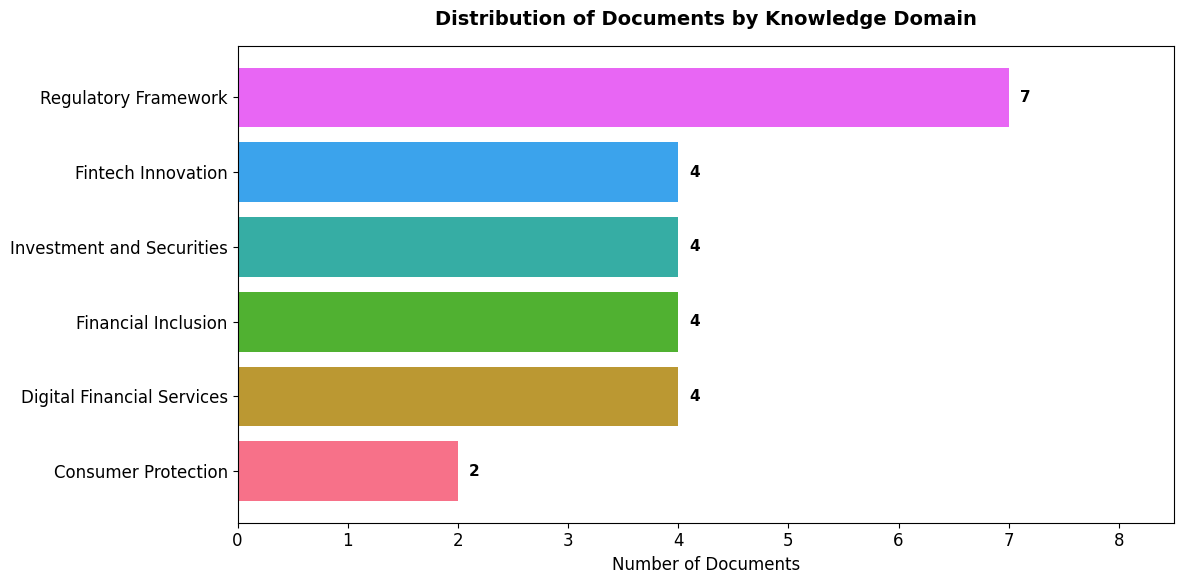

✅ Figure saved to outputs/figures/domain_distribution.png


In [12]:
# --- 3.10 Corpus Distribution Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting settings (matching Project 1 style)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_palette("husl")

# Reload enriched registry
status_df = pd.DataFrame(corpus_registry)

# ---- FIGURE 1: Documents per Knowledge Domain ----
fig, ax = plt.subplots(figsize=(12, 6))

domain_counts = status_df['domain'].value_counts().sort_values()
colors = sns.color_palette("husl", len(domain_counts))

bars = ax.barh(domain_counts.index, domain_counts.values, color=colors)
ax.set_xlabel('Number of Documents')
ax.set_title('Distribution of Documents by Knowledge Domain',
             fontsize=14, fontweight='bold', pad=15)

# Add count labels on bars
for bar, count in zip(bars, domain_counts.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontweight='bold', fontsize=11)

ax.set_xlim(0, domain_counts.max() + 1.5)
plt.tight_layout()
os.makedirs('outputs/figures', exist_ok=True)
plt.savefig('outputs/figures/domain_distribution.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Figure saved to outputs/figures/domain_distribution.png")

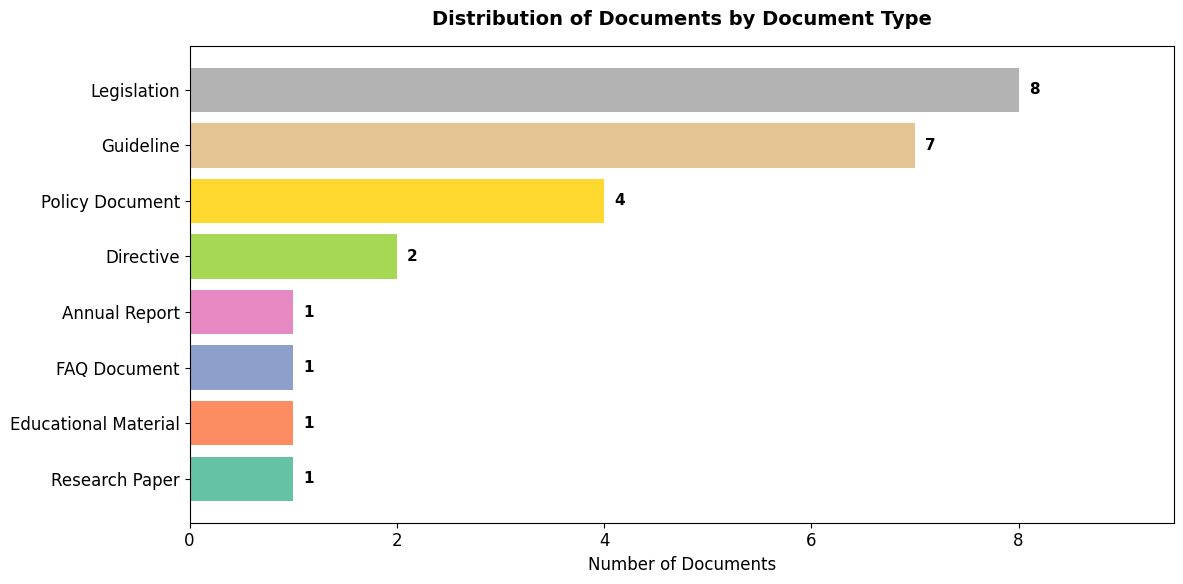

✅ Figure saved to outputs/figures/doctype_distribution.png


In [13]:
# ---- FIGURE 2: Documents per Document Type ----
fig, ax = plt.subplots(figsize=(12, 6))

type_counts = status_df['doc_type'].value_counts().sort_values()
colors = sns.color_palette("Set2", len(type_counts))

bars = ax.barh(type_counts.index, type_counts.values, color=colors)
ax.set_xlabel('Number of Documents')
ax.set_title('Distribution of Documents by Document Type',
             fontsize=14, fontweight='bold', pad=15)

for bar, count in zip(bars, type_counts.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontweight='bold', fontsize=11)

ax.set_xlim(0, type_counts.max() + 1.5)
plt.tight_layout()
plt.savefig('outputs/figures/doctype_distribution.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Figure saved to outputs/figures/doctype_distribution.png")

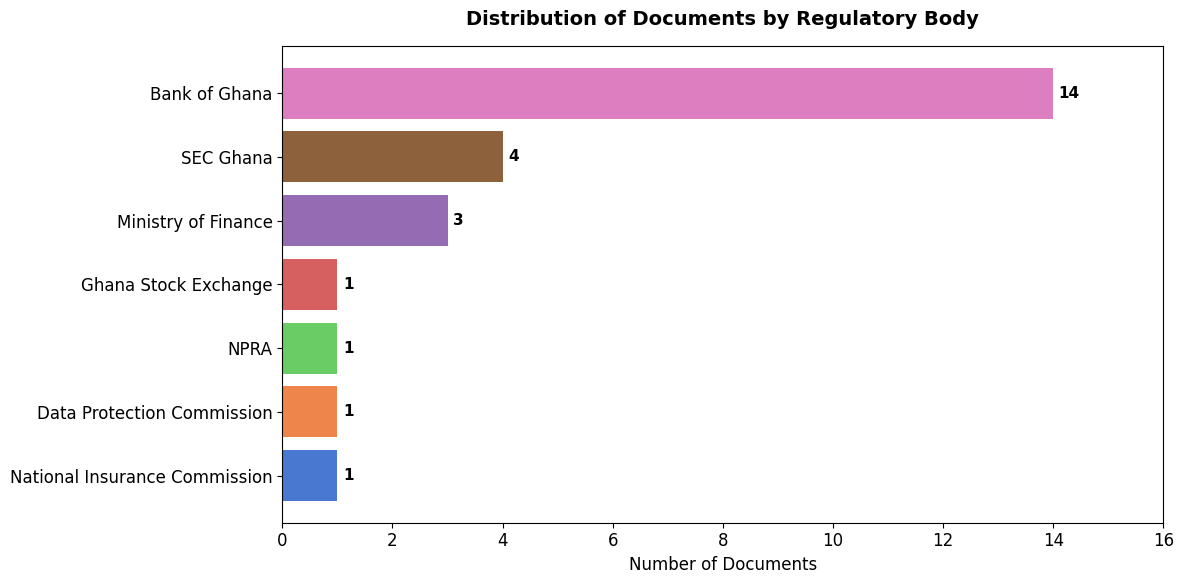

✅ Figure saved to outputs/figures/regulatory_body_distribution.png


In [14]:
# ---- FIGURE 3: Documents per Regulatory Body ----
fig, ax = plt.subplots(figsize=(12, 6))

body_counts = status_df['regulatory_body'].value_counts().sort_values()
colors = sns.color_palette("muted", len(body_counts))

bars = ax.barh(body_counts.index, body_counts.values, color=colors)
ax.set_xlabel('Number of Documents')
ax.set_title('Distribution of Documents by Regulatory Body',
             fontsize=14, fontweight='bold', pad=15)

for bar, count in zip(bars, body_counts.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontweight='bold', fontsize=11)

ax.set_xlim(0, body_counts.max() + 2)
plt.tight_layout()
plt.savefig('outputs/figures/regulatory_body_distribution.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Figure saved to outputs/figures/regulatory_body_distribution.png")

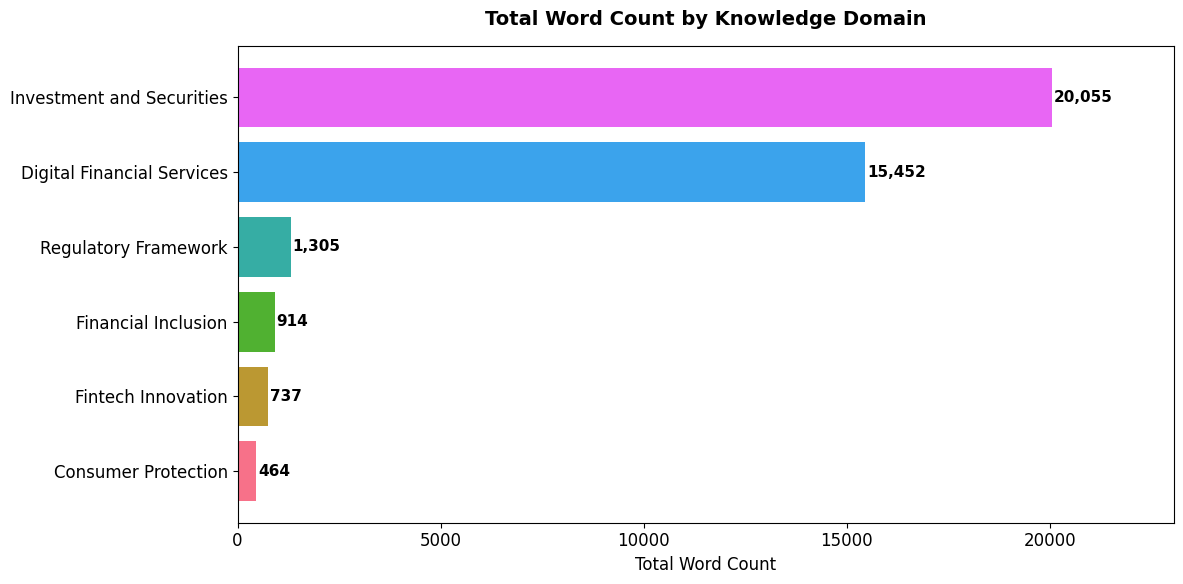

✅ Figure saved to outputs/figures/domain_wordcount.png


In [15]:
# ---- FIGURE 4: Word Count Distribution by Domain ----
fig, ax = plt.subplots(figsize=(12, 6))

domain_words = status_df.groupby('domain')['word_count'].sum().sort_values()
colors = sns.color_palette("husl", len(domain_words))

bars = ax.barh(domain_words.index, domain_words.values, color=colors)
ax.set_xlabel('Total Word Count')
ax.set_title('Total Word Count by Knowledge Domain',
             fontsize=14, fontweight='bold', pad=15)

for bar, count in zip(bars, domain_words.values):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontweight='bold', fontsize=11)

ax.set_xlim(0, domain_words.max() * 1.15)
plt.tight_layout()
plt.savefig('outputs/figures/domain_wordcount.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Figure saved to outputs/figures/domain_wordcount.png")

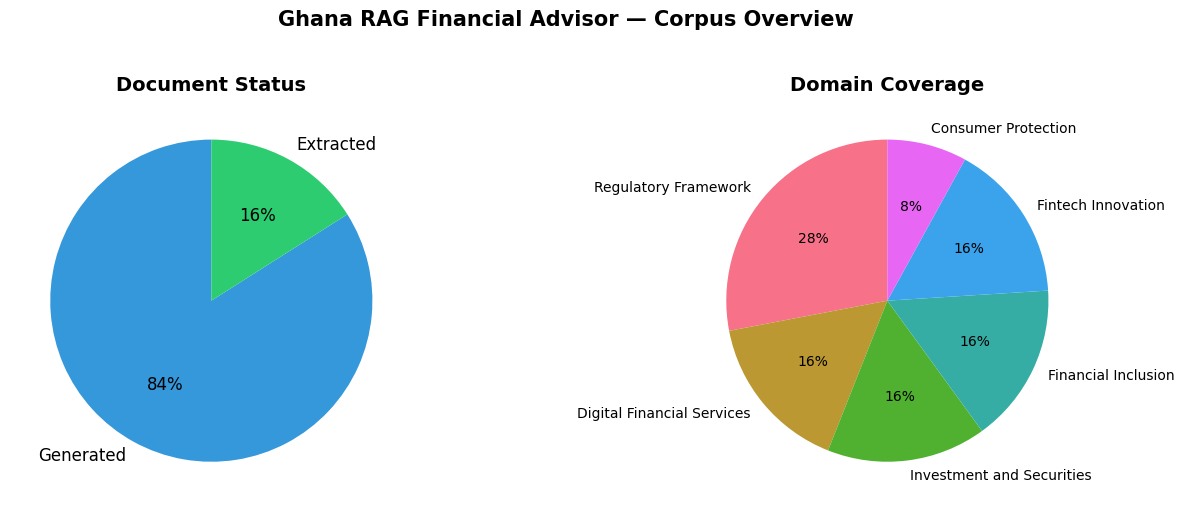

✅ Figure saved to outputs/figures/corpus_overview.png


In [16]:
# ---- FIGURE 5: Document Status and Corpus Summary ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart: Document status
status_counts = status_df['status'].value_counts()
status_colors = {'Extracted': '#2ecc71', 'Generated': '#3498db',
                 'Pending': '#e74c3c'}
pie_colors = [status_colors.get(s, '#95a5a6') for s in status_counts.index]

axes[0].pie(status_counts.values, labels=status_counts.index,
            autopct='%1.0f%%', colors=pie_colors,
            textprops={'fontsize': 12}, startangle=90)
axes[0].set_title('Document Status', fontsize=14, fontweight='bold')

# Pie chart: Domain distribution
domain_counts_all = status_df['domain'].value_counts()
axes[1].pie(domain_counts_all.values, labels=domain_counts_all.index,
            autopct='%1.0f%%', colors=sns.color_palette("husl", len(domain_counts_all)),
            textprops={'fontsize': 10}, startangle=90)
axes[1].set_title('Domain Coverage', fontsize=14, fontweight='bold')

plt.suptitle('Ghana RAG Financial Advisor — Corpus Overview',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/corpus_overview.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Figure saved to outputs/figures/corpus_overview.png")

In [17]:
# ---- CORPUS SUMMARY STATISTICS ----
print("=" * 55)
print("CORPUS SUMMARY — SPRINT 1 COMPLETE")
print("=" * 55)
print(f"Total documents       : {len(status_df)}")
print(f"Knowledge domains     : {status_df['domain'].nunique()}")
print(f"Regulatory bodies     : {status_df['regulatory_body'].nunique()}")
print(f"Document types        : {status_df['doc_type'].nunique()}")
print(f"Year range            : {status_df['year'].min()} – {status_df['year'].max()}")
print(f"Total word count      : {status_df['word_count'].sum():,}")
print()
print("--- Status Breakdown ---")
for status, count in status_df['status'].value_counts().items():
    pct = count / len(status_df) * 100
    print(f"  {status:<15} : {count:>2} ({pct:.0f}%)")
print()
print("--- Largest Documents ---")
top_docs = status_df.nlargest(5, 'word_count')[
    ['doc_id', 'title', 'word_count']
]
for _, row in top_docs.iterrows():
    print(f"  {row['doc_id']}: {row['word_count']:>6,} words — "
          f"{row['title'][:50]}")
print()
print("=" * 55)
print("✅ SPRINT 1 — DOCUMENT CORPUS AND KNOWLEDGE BASE COMPLETE")
print("✅ Ready for Sprint 2 — Chunking and Embedding Pipeline")
print("=" * 55)

CORPUS SUMMARY — SPRINT 1 COMPLETE
Total documents       : 25
Knowledge domains     : 6
Regulatory bodies     : 7
Document types        : 8
Year range            : 2008 – 2026
Total word count      : 38,927

--- Status Breakdown ---
  Generated       : 21 (84%)
  Extracted       :  4 (16%)

--- Largest Documents ---
  DFS-001: 14,869 words — Digital Financial Services (DFS) Policy
  INV-002: 13,783 words — Securities Industry (Financial Resources) Guidelin
  INV-001:  5,762 words — SEC Investment Guidelines for Fund Managers
  INV-003:    354 words — SEC FAQs on Collective Investment Schemes
  FIN-004:    315 words — Bank of Ghana Financial Literacy Programme Materia

✅ SPRINT 1 — DOCUMENT CORPUS AND KNOWLEDGE BASE COMPLETE
✅ Ready for Sprint 2 — Chunking and Embedding Pipeline


### 3.11 Document Chunking Strategy
Documents in the knowledge base must be split into smaller, semantically coherent units (chunks) suitable for embedding and retrieval. The chunking strategy is a critical design decision: chunks that are too large dilute the relevance signal and exceed embedding model context windows, while chunks that are too small lose contextual meaning and produce fragmented retrieval results.

This study implements the Recursive Character Text Splitter from LangChain, which respects document structure by attempting to split at natural boundaries, paragraph breaks first, then sentence boundaries, then word boundaries, before falling back to character-level splitting. Four chunk size configurations are tested (500, 800, 1000, and 1200 characters) with 20% overlap to ensure no information is lost at chunk boundaries. Each chunk inherits the full metadata of its source document, enabling filtered retrieval by domain, regulatory body, or document type.

In [18]:
# ============================================================
# SPRINT 2 — CHUNKING AND EMBEDDING PIPELINE
# Project: Ghana RAG Financial Advisor Bot
# Author: Evans Ataaya
# Date: April 2026
# ============================================================

# --- 3.11 Load All Processed Documents ---
import glob

# Load enriched registry
with open('config/corpus_registry_enriched.json', 'r', encoding='utf-8') as f:
    corpus_registry = json.load(f)

# Load all text files from data/processed/
all_documents = []

for doc in corpus_registry:
    txt_path = doc.get('txt_path', '')
    if txt_path and os.path.exists(txt_path):
        with open(txt_path, 'r', encoding='utf-8') as f:
            text = f.read()
        
        all_documents.append({
            "doc_id": doc['doc_id'],
            "title": doc['title'],
            "domain": doc['domain'],
            "doc_type": doc['doc_type'],
            "regulatory_body": doc['regulatory_body'],
            "year": doc['year'],
            "text": text,
            "word_count": len(text.split())
        })

print("=" * 55)
print("DOCUMENTS LOADED FOR CHUNKING")
print("=" * 55)
print(f"Documents loaded  : {len(all_documents)}")
print(f"Total words       : {sum(d['word_count'] for d in all_documents):,}")
print()
for doc in all_documents[:5]:
    print(f"  {doc['doc_id']}: {doc['word_count']:>6,} words — "
          f"{doc['title'][:45]}...")
print(f"  ... and {len(all_documents) - 5} more documents")

DOCUMENTS LOADED FOR CHUNKING
Documents loaded  : 25
Total words       : 38,927

  REG-001:      0 words — Payment Systems and Services Act, 2019 (Act 9...
  REG-002:    252 words — Banks and Specialised Deposit-Taking Institut...
  REG-003:    230 words — Anti-Money Laundering Act, 2020 (Act 1044)...
  REG-004:    275 words — Securities Industry Act, 2016 (Act 929)...
  REG-005:    148 words — Insurance Act, 2021 (Act 1061)...
  ... and 20 more documents


In [19]:
# --- 3.12 Implement Chunking Configurations ---
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Define four configurations to compare
chunking_configs = {
    "small_500": {
        "chunk_size": 500,
        "chunk_overlap": 100,
    },
    "medium_800": {
        "chunk_size": 800,
        "chunk_overlap": 160,
    },
    "standard_1000": {
        "chunk_size": 1000,
        "chunk_overlap": 200,
    },
    "large_1200": {
        "chunk_size": 1200,
        "chunk_overlap": 240,
    },
}

# Separators optimised for regulatory/legal text
separators = [
    "\n\n",    # Paragraph breaks (strongest boundary)
    "\n",      # Line breaks
    ". ",      # Sentence boundaries
    "; ",      # Clause boundaries
    ", ",      # Comma-separated items
    " ",       # Word boundaries (last resort)
]

# Run all four configurations
chunking_results = {}

print("=" * 55)
print("CHUNKING CONFIGURATION COMPARISON")
print("=" * 55)

for config_name, config in chunking_configs.items():
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=config["chunk_size"],
        chunk_overlap=config["chunk_overlap"],
        separators=separators,
        length_function=len,
    )
    
    all_chunks = []
    
    for doc in all_documents:
        # Split the document text
        chunks = splitter.split_text(doc["text"])
        
        # Attach metadata to each chunk
        for i, chunk_text in enumerate(chunks):
            all_chunks.append({
                "chunk_id": f"{doc['doc_id']}_chunk_{i:03d}",
                "doc_id": doc["doc_id"],
                "title": doc["title"],
                "domain": doc["domain"],
                "doc_type": doc["doc_type"],
                "regulatory_body": doc["regulatory_body"],
                "year": doc["year"],
                "chunk_index": i,
                "total_chunks": len(chunks),
                "text": chunk_text,
                "char_count": len(chunk_text),
                "word_count": len(chunk_text.split()),
            })
    
    chunking_results[config_name] = all_chunks
    
    # Calculate statistics
    char_counts = [c["char_count"] for c in all_chunks]
    
    print(f"\n{'─' * 55}")
    print(f"Config: {config_name}")
    print(f"  Chunk size     : {config['chunk_size']} chars")
    print(f"  Overlap        : {config['chunk_overlap']} chars "
          f"({config['chunk_overlap']/config['chunk_size']*100:.0f}%)")
    print(f"  Total chunks   : {len(all_chunks):,}")
    print(f"  Avg chunk size : {np.mean(char_counts):.0f} chars")
    print(f"  Min chunk size : {np.min(char_counts)} chars")
    print(f"  Max chunk size : {np.max(char_counts)} chars")
    print(f"  Std deviation  : {np.std(char_counts):.0f} chars")

CHUNKING CONFIGURATION COMPARISON

───────────────────────────────────────────────────────
Config: small_500
  Chunk size     : 500 chars
  Overlap        : 100 chars (20%)
  Total chunks   : 684
  Avg chunk size : 439 chars
  Min chunk size : 32 chars
  Max chunk size : 499 chars
  Std deviation  : 71 chars

───────────────────────────────────────────────────────
Config: medium_800
  Chunk size     : 800 chars
  Overlap        : 160 chars (20%)
  Total chunks   : 415
  Avg chunk size : 725 chars
  Min chunk size : 32 chars
  Max chunk size : 799 chars
  Std deviation  : 119 chars

───────────────────────────────────────────────────────
Config: standard_1000
  Chunk size     : 1000 chars
  Overlap        : 200 chars (20%)
  Total chunks   : 339
  Avg chunk size : 900 chars
  Min chunk size : 32 chars
  Max chunk size : 999 chars
  Std deviation  : 173 chars

───────────────────────────────────────────────────────
Config: large_1200
  Chunk size     : 1200 chars
  Overlap        : 240 c

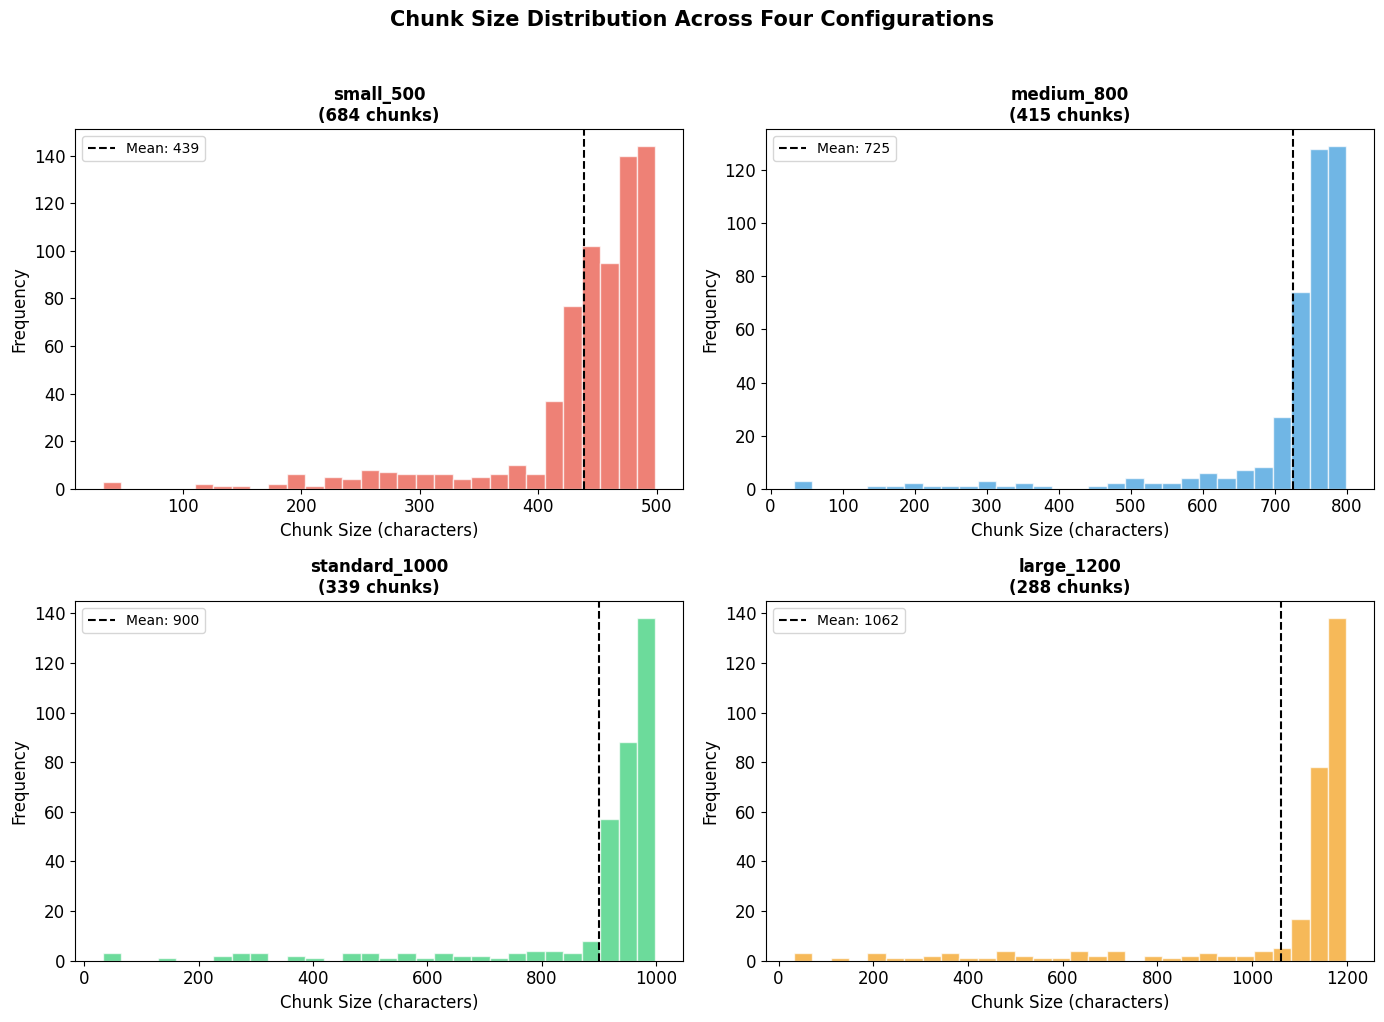

✅ Figure saved to outputs/figures/chunk_size_distributions.png


In [20]:
# --- 3.13 Visualise Chunk Size Distributions ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for idx, (config_name, chunks) in enumerate(chunking_results.items()):
    ax = axes[idx]
    char_counts = [c["char_count"] for c in chunks]
    
    ax.hist(char_counts, bins=30, color=colors[idx], alpha=0.7,
            edgecolor='white')
    ax.axvline(np.mean(char_counts), color='black', linestyle='--',
               linewidth=1.5, label=f'Mean: {np.mean(char_counts):.0f}')
    ax.set_title(f'{config_name}\n({len(chunks)} chunks)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Chunk Size (characters)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=10)

plt.suptitle('Chunk Size Distribution Across Four Configurations',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/chunk_size_distributions.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Figure saved to outputs/figures/chunk_size_distributions.png")

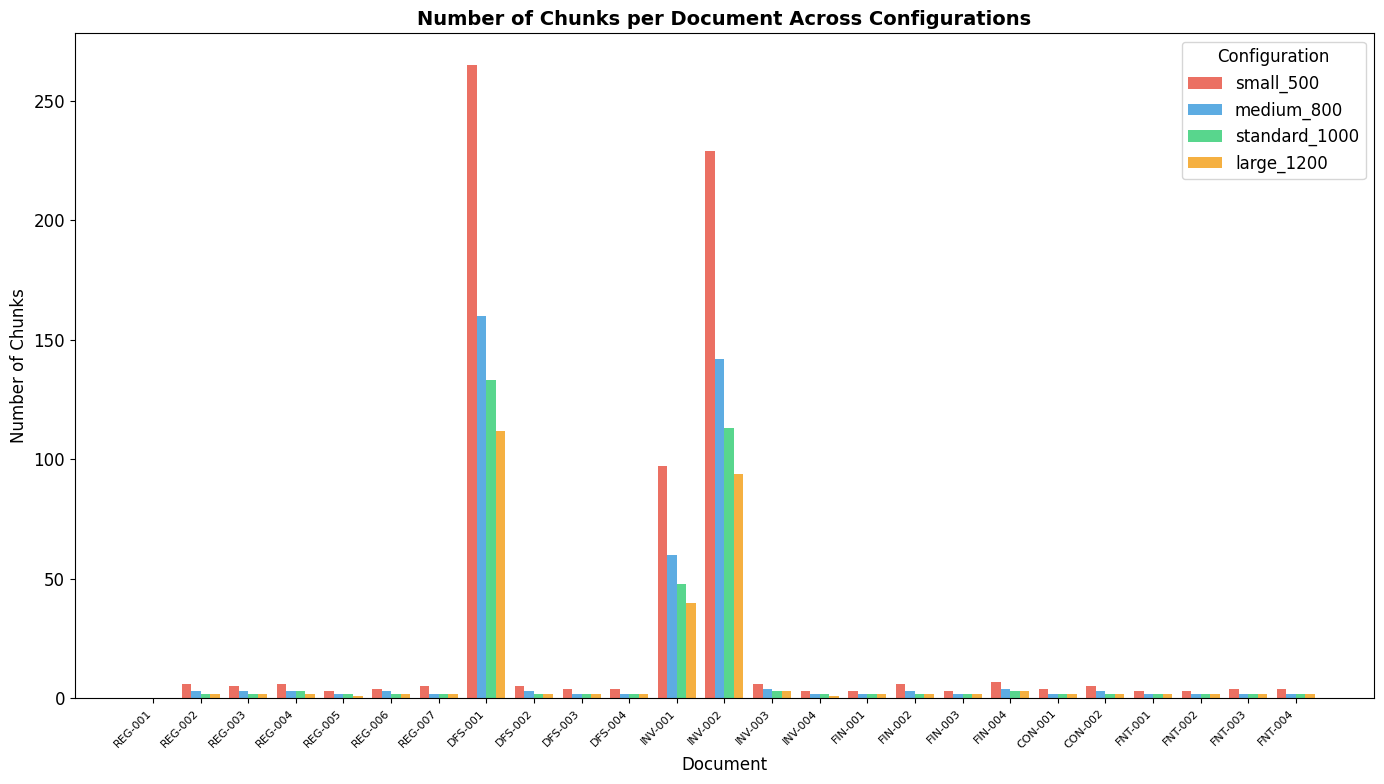

✅ Figure saved to outputs/figures/chunks_per_document.png


In [21]:
# --- 3.14 Chunks per Document Comparison ---
fig, ax = plt.subplots(figsize=(14, 8))

config_names = list(chunking_results.keys())
x = np.arange(len(all_documents))
width = 0.2

for idx, config_name in enumerate(config_names):
    chunks = chunking_results[config_name]
    # Count chunks per document
    doc_chunk_counts = {}
    for c in chunks:
        doc_id = c['doc_id']
        doc_chunk_counts[doc_id] = doc_chunk_counts.get(doc_id, 0) + 1
    
    counts = [doc_chunk_counts.get(d['doc_id'], 0) for d in all_documents]
    ax.bar(x + idx * width, counts, width, label=config_name,
           color=colors[idx], alpha=0.8)

ax.set_xlabel('Document')
ax.set_ylabel('Number of Chunks')
ax.set_title('Number of Chunks per Document Across Configurations',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([d['doc_id'] for d in all_documents],
                    rotation=45, ha='right', fontsize=8)
ax.legend(title='Configuration')
plt.tight_layout()
plt.savefig('outputs/figures/chunks_per_document.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Figure saved to outputs/figures/chunks_per_document.png")

In [22]:
# --- 3.15 Select Optimal Configuration ---
# We select standard_1000 as our primary configuration based on:
# - Balance between context preservation and retrieval granularity
# - Commonly recommended range in RAG literature (800-1200)
# - Sufficient overlap (200 chars / 20%) for context continuity

SELECTED_CONFIG = "standard_1000"
final_chunks = chunking_results[SELECTED_CONFIG]

print("=" * 55)
print("SELECTED CHUNKING CONFIGURATION")
print("=" * 55)
print(f"Configuration : {SELECTED_CONFIG}")
print(f"Chunk size    : 1000 characters")
print(f"Overlap       : 200 characters (20%)")
print(f"Total chunks  : {len(final_chunks)}")
print()

# Show sample chunks from different domains
print("--- Sample Chunks ---")
seen_domains = set()
for chunk in final_chunks:
    if chunk['domain'] not in seen_domains and len(seen_domains) < 3:
        seen_domains.add(chunk['domain'])
        print(f"\n{'━' * 55}")
        print(f"Chunk ID : {chunk['chunk_id']}")
        print(f"Document : {chunk['title'][:50]}...")
        print(f"Domain   : {chunk['domain']}")
        print(f"Size     : {chunk['char_count']} chars / "
              f"{chunk['word_count']} words")
        print(f"{'━' * 55}")
        # Show first 300 characters of the chunk
        print(chunk['text'][:300] + "...")

SELECTED CHUNKING CONFIGURATION
Configuration : standard_1000
Chunk size    : 1000 characters
Overlap       : 200 characters (20%)
Total chunks  : 339

--- Sample Chunks ---

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Chunk ID : REG-002_chunk_000
Document : Banks and Specialised Deposit-Taking Institutions ...
Domain   : Regulatory Framework
Size     : 968 chars / 131 words
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Banks and Specialised Deposit-Taking Institutions Act, 2016 (Act 930)

This Act provides the regulatory framework for banks and specialised deposit-taking institutions in Ghana. It establishes the licensing requirements, minimum capital requirements, and corporate governance standards for all bankin...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Chunk ID : DFS-001_chunk_000
Document : Digital Financial Services (DFS) Policy...
Domain   : Digital Financial Services
Size     : 320 chars / 47 words
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [23]:
# --- 3.16 Save Final Chunks ---
# Save chunks as JSON for the embedding pipeline

chunks_path = 'config/final_chunks.json'

# Save without the full text to keep file manageable
chunks_metadata = []
for chunk in final_chunks:
    chunks_metadata.append({
        "chunk_id": chunk["chunk_id"],
        "doc_id": chunk["doc_id"],
        "title": chunk["title"],
        "domain": chunk["domain"],
        "doc_type": chunk["doc_type"],
        "regulatory_body": chunk["regulatory_body"],
        "year": chunk["year"],
        "chunk_index": chunk["chunk_index"],
        "total_chunks": chunk["total_chunks"],
        "char_count": chunk["char_count"],
        "word_count": chunk["word_count"],
    })

with open(chunks_path, 'w', encoding='utf-8') as f:
    json.dump(chunks_metadata, f, indent=2)

# Also save full chunks with text for embedding
full_chunks_path = 'data/processed/chunks_with_text.json'
with open(full_chunks_path, 'w', encoding='utf-8') as f:
    json.dump(final_chunks, f, indent=2, ensure_ascii=False)

print("=" * 55)
print("CHUNKS SAVED")
print("=" * 55)
print(f"Metadata only : {chunks_path} "
      f"({os.path.getsize(chunks_path) / 1024:.1f} KB)")
print(f"With text     : {full_chunks_path} "
      f"({os.path.getsize(full_chunks_path) / 1024:.1f} KB)")
print(f"Total chunks  : {len(final_chunks)}")
print(f"✅ Ready for embedding generation")

CHUNKS SAVED
Metadata only : config/final_chunks.json (123.8 KB)
With text     : data/processed/chunks_with_text.json (432.3 KB)
Total chunks  : 339
✅ Ready for embedding generation


### 3.17 Embedding Generation
Each text chunk is converted into a dense vector representation using a pre-trained transformer-based embedding model. These vectors capture the semantic meaning of the text in a high-dimensional space, enabling similarity-based retrieval where a user's query is matched against the most semantically relevant chunks in the knowledge base.

This study uses the all-MiniLM-L6-v2 model from the sentence-transformers library, which produces 384-dimensional embeddings optimised for semantic similarity tasks. This model was selected for its balance between embedding quality and computational efficiency, it is fast enough to embed the entire corpus on a standard machine while producing embeddings that perform competitively with larger models on information retrieval benchmarks (Reimers and Gurevych, 2019). The embeddings are subsequently visualised using t-SNE dimensionality reduction to verify that documents from similar domains cluster together in the embedding space.

In [24]:
# --- 3.17 Load Embedding Model ---
from sentence_transformers import SentenceTransformer
import time

print("=" * 55)
print("LOADING EMBEDDING MODEL")
print("=" * 55)
print("Model: all-MiniLM-L6-v2")
print("This may take a moment on first run (downloads ~80MB)...")
print()

start_time = time.time()
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
load_time = time.time() - start_time

print(f"✅ Model loaded in {load_time:.1f} seconds")
print(f"Embedding dimensions : {embedding_model.get_sentence_embedding_dimension()}")
print(f"Max sequence length  : {embedding_model.max_seq_length}")

LOADING EMBEDDING MODEL
Model: all-MiniLM-L6-v2
This may take a moment on first run (downloads ~80MB)...



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded in 5.2 seconds
Embedding dimensions : 384
Max sequence length  : 256


In [25]:
# --- 3.18 Understand Embeddings — A Simple Demonstration ---
# Before embedding the full corpus, let's understand what
# embeddings are by looking at a few examples.

# Sample texts related to Ghana finance
sample_texts = [
    "How do I invest in Treasury bills in Ghana?",
    "What are the requirements for a mobile money licence?",
    "The Bank of Ghana regulates payment service providers.",
    "Manchester United won the football match last night.",
    "What is the minimum capital for digital lending in Ghana?",
]

# Generate embeddings
sample_embeddings = embedding_model.encode(sample_texts)

print("=" * 55)
print("UNDERSTANDING EMBEDDINGS")
print("=" * 55)
print(f"Number of texts    : {len(sample_texts)}")
print(f"Embedding shape    : {sample_embeddings.shape}")
print(f"Each text becomes  : a vector of {sample_embeddings.shape[1]} numbers")
print()

# Show what an embedding looks like (first 10 dimensions)
print("--- What an Embedding Looks Like ---")
print(f"Text: '{sample_texts[0]}'")
print(f"Vector (first 10 of {sample_embeddings.shape[1]} dimensions):")
print(f"  {sample_embeddings[0][:10].round(4)}")
print()

# Calculate similarity between all pairs
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(sample_embeddings)

print("--- Cosine Similarity Between Texts ---")
print("(1.0 = identical meaning, 0.0 = unrelated)")
print()
for i in range(len(sample_texts)):
    for j in range(i + 1, len(sample_texts)):
        sim = sim_matrix[i][j]
        marker = "🔥" if sim > 0.5 else "  "
        print(f"  {marker} {sim:.4f}  '{sample_texts[i][:45]}...'")
        print(f"           vs  '{sample_texts[j][:45]}...'")
        print()

UNDERSTANDING EMBEDDINGS
Number of texts    : 5
Embedding shape    : (5, 384)
Each text becomes  : a vector of 384 numbers

--- What an Embedding Looks Like ---
Text: 'How do I invest in Treasury bills in Ghana?'
Vector (first 10 of 384 dimensions):
  [-0.017   0.0314 -0.0828 -0.0141 -0.0649 -0.0336 -0.0858  0.0889 -0.0522
  0.0771]

--- Cosine Similarity Between Texts ---
(1.0 = identical meaning, 0.0 = unrelated)

     0.3905  'How do I invest in Treasury bills in Ghana?...'
           vs  'What are the requirements for a mobile money ...'

  🔥 0.5260  'How do I invest in Treasury bills in Ghana?...'
           vs  'The Bank of Ghana regulates payment service p...'

     0.0029  'How do I invest in Treasury bills in Ghana?...'
           vs  'Manchester United won the football match last...'

  🔥 0.5813  'How do I invest in Treasury bills in Ghana?...'
           vs  'What is the minimum capital for digital lendi...'

     0.3502  'What are the requirements for a mobile money ...'
  

In [26]:
# --- 3.19 Embed the Full Document Corpus ---
# Load the final chunks with text
with open('data/processed/chunks_with_text.json', 'r', encoding='utf-8') as f:
    final_chunks = json.load(f)

# Extract just the text for embedding
chunk_texts = [chunk['text'] for chunk in final_chunks]

print("=" * 55)
print("EMBEDDING FULL CORPUS")
print("=" * 55)
print(f"Chunks to embed : {len(chunk_texts)}")
print(f"Model           : all-MiniLM-L6-v2 (384 dimensions)")
print()
print("Generating embeddings... (this may take 1-3 minutes)")

start_time = time.time()
corpus_embeddings = embedding_model.encode(
    chunk_texts,
    show_progress_bar=True,
    batch_size=32
)
embed_time = time.time() - start_time

print()
print(f"✅ Embedding complete in {embed_time:.1f} seconds")
print(f"Embeddings shape : {corpus_embeddings.shape}")
print(f"  → {corpus_embeddings.shape[0]} chunks × "
      f"{corpus_embeddings.shape[1]} dimensions")
print(f"Memory usage     : {corpus_embeddings.nbytes / 1024:.1f} KB")

EMBEDDING FULL CORPUS
Chunks to embed : 339
Model           : all-MiniLM-L6-v2 (384 dimensions)

Generating embeddings... (this may take 1-3 minutes)


Batches:   0%|          | 0/11 [00:00<?, ?it/s]


✅ Embedding complete in 37.2 seconds
Embeddings shape : (339, 384)
  → 339 chunks × 384 dimensions
Memory usage     : 508.5 KB


In [27]:
# --- 3.20 Save Embeddings ---
embeddings_path = 'data/vectorstore/corpus_embeddings.npy'
np.save(embeddings_path, corpus_embeddings)

print("=" * 55)
print("EMBEDDINGS SAVED")
print("=" * 55)
print(f"Saved to     : {embeddings_path}")
print(f"Shape        : {corpus_embeddings.shape}")
print(f"File size    : {os.path.getsize(embeddings_path) / 1024:.1f} KB")
print(f"✅ Embeddings saved successfully")

EMBEDDINGS SAVED
Saved to     : data/vectorstore/corpus_embeddings.npy
Shape        : (339, 384)
File size    : 508.6 KB
✅ Embeddings saved successfully


Running t-SNE dimensionality reduction...
(Reducing 384 dimensions → 2 dimensions for visualisation)
✅ t-SNE complete



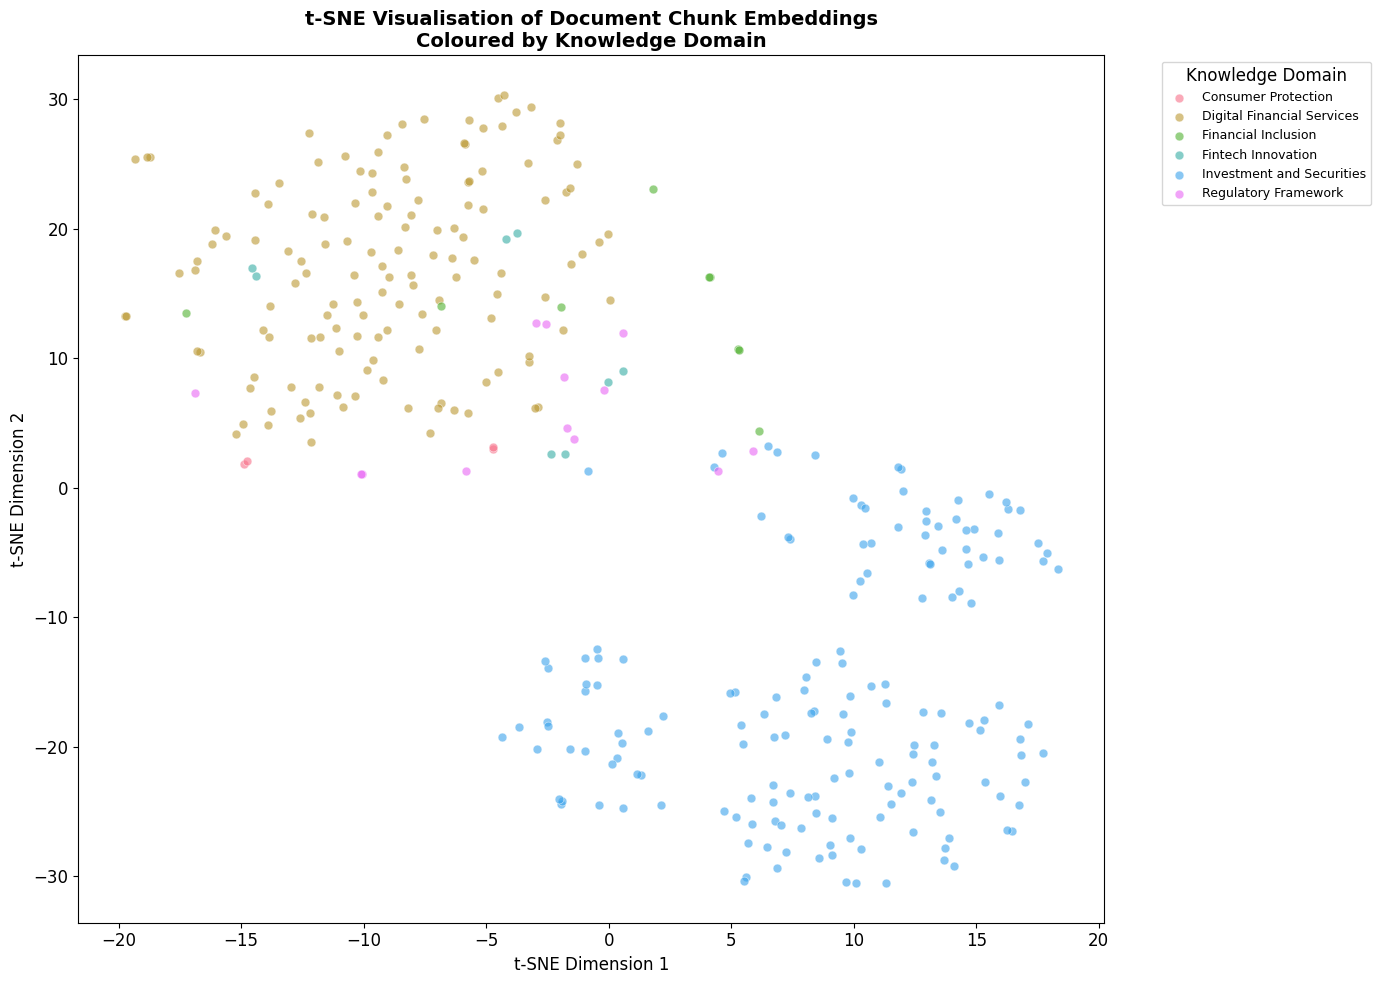

✅ Figure saved to outputs/figures/tsne_embeddings_by_domain.png


In [28]:
# --- 3.21 Visualise Embeddings with t-SNE ---
from sklearn.manifold import TSNE

print("Running t-SNE dimensionality reduction...")
print("(Reducing 384 dimensions → 2 dimensions for visualisation)")

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=min(30, len(corpus_embeddings) - 1),
    max_iter=1000
)
embeddings_2d = tsne.fit_transform(corpus_embeddings)

print("✅ t-SNE complete")
print()

# Create visualisation coloured by domain
fig, ax = plt.subplots(figsize=(14, 10))

# Get domain for each chunk
domains = [chunk['domain'] for chunk in final_chunks]
unique_domains = sorted(set(domains))
domain_colors = sns.color_palette("husl", len(unique_domains))
domain_color_map = dict(zip(unique_domains, domain_colors))

# Plot each domain
for domain in unique_domains:
    mask = [d == domain for d in domains]
    points = embeddings_2d[mask]
    ax.scatter(points[:, 0], points[:, 1],
               c=[domain_color_map[domain]],
               label=domain, alpha=0.6, s=40, edgecolors='white',
               linewidths=0.5)

ax.set_title('t-SNE Visualisation of Document Chunk Embeddings\n'
             'Coloured by Knowledge Domain',
             fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(title='Knowledge Domain', bbox_to_anchor=(1.05, 1),
          loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/figures/tsne_embeddings_by_domain.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Figure saved to outputs/figures/tsne_embeddings_by_domain.png")

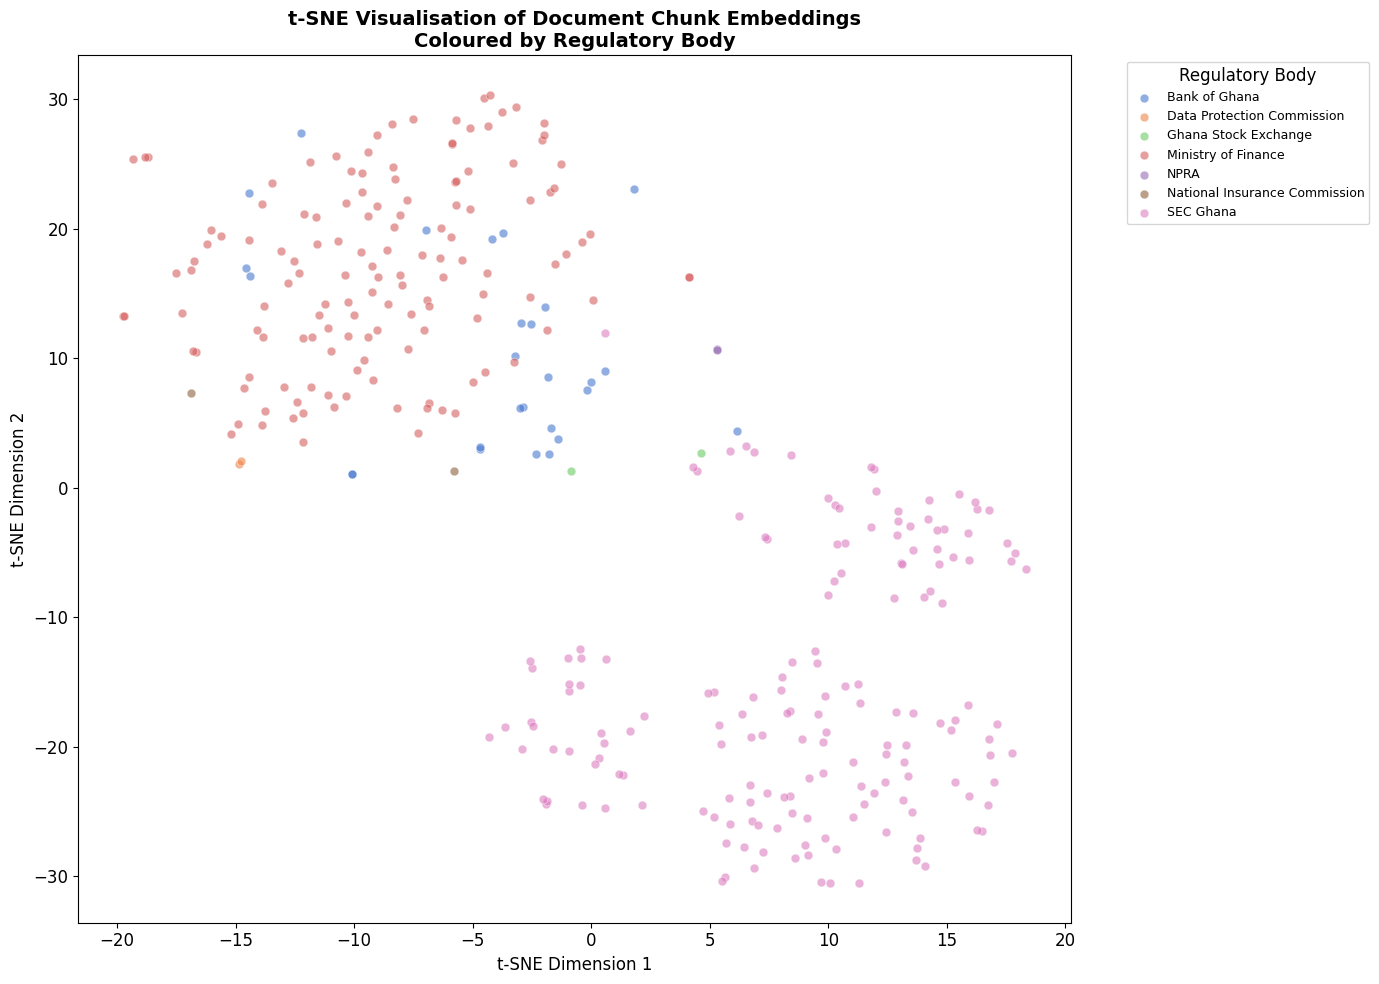

✅ Figure saved to outputs/figures/tsne_embeddings_by_body.png


In [29]:
# --- 3.22 t-SNE Coloured by Regulatory Body ---
fig, ax = plt.subplots(figsize=(14, 10))

bodies = [chunk['regulatory_body'] for chunk in final_chunks]
unique_bodies = sorted(set(bodies))
body_colors = sns.color_palette("muted", len(unique_bodies))
body_color_map = dict(zip(unique_bodies, body_colors))

for body in unique_bodies:
    mask = [b == body for b in bodies]
    points = embeddings_2d[mask]
    ax.scatter(points[:, 0], points[:, 1],
               c=[body_color_map[body]],
               label=body, alpha=0.6, s=40, edgecolors='white',
               linewidths=0.5)

ax.set_title('t-SNE Visualisation of Document Chunk Embeddings\n'
             'Coloured by Regulatory Body',
             fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(title='Regulatory Body', bbox_to_anchor=(1.05, 1),
          loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/figures/tsne_embeddings_by_body.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Figure saved to outputs/figures/tsne_embeddings_by_body.png")

In [30]:
# --- 3.23 Embedding Statistics ---
print("=" * 55)
print("EMBEDDING PIPELINE SUMMARY")
print("=" * 55)
print(f"Model              : all-MiniLM-L6-v2")
print(f"Embedding dimensions: {corpus_embeddings.shape[1]}")
print(f"Total chunks       : {corpus_embeddings.shape[0]}")
print(f"Embedding time     : {embed_time:.1f} seconds")
print(f"Throughput         : {len(chunk_texts)/embed_time:.0f} chunks/second")
print()

# Embedding statistics
print("--- Embedding Vector Statistics ---")
print(f"Mean value    : {corpus_embeddings.mean():.6f}")
print(f"Std deviation : {corpus_embeddings.std():.6f}")
print(f"Min value     : {corpus_embeddings.min():.6f}")
print(f"Max value     : {corpus_embeddings.max():.6f}")
print(f"L2 norm (avg) : {np.linalg.norm(corpus_embeddings, axis=1).mean():.4f}")
print()

# Average similarity within vs between domains
print("--- Average Cosine Similarity ---")
for domain in unique_domains:
    mask = np.array([d == domain for d in domains])
    if mask.sum() > 1:
        domain_embeds = corpus_embeddings[mask]
        within_sim = cosine_similarity(domain_embeds)
        # Get upper triangle (exclude self-similarity)
        triu_indices = np.triu_indices_from(within_sim, k=1)
        avg_sim = within_sim[triu_indices].mean()
        print(f"  {domain:<30} : {avg_sim:.4f} "
              f"(within-domain, {mask.sum()} chunks)")

print()
print("✅ complete — embeddings generated and visualised")
print("✅ building the vector store")

EMBEDDING PIPELINE SUMMARY
Model              : all-MiniLM-L6-v2
Embedding dimensions: 384
Total chunks       : 339
Embedding time     : 37.2 seconds
Throughput         : 9 chunks/second

--- Embedding Vector Statistics ---
Mean value    : -0.001069
Std deviation : 0.051020
Min value     : -0.211929
Max value     : 0.261995
L2 norm (avg) : 1.0000

--- Average Cosine Similarity ---
  Consumer Protection            : 0.4921 (within-domain, 4 chunks)
  Digital Financial Services     : 0.4909 (within-domain, 139 chunks)
  Financial Inclusion            : 0.4156 (within-domain, 9 chunks)
  Fintech Innovation             : 0.5209 (within-domain, 8 chunks)
  Investment and Securities      : 0.4115 (within-domain, 166 chunks)
  Regulatory Framework           : 0.4101 (within-domain, 13 chunks)

✅ complete — embeddings generated and visualised
✅ building the vector store


### 3.24 Vector Store Construction
The embedded chunks are stored in a ChromaDB persistent vector database, which provides both semantic similarity search and metadata-based filtering. ChromaDB was selected for this project due to its native support for metadata filtering alongside vector search a critical capability for regulatory document retrieval where users may need to restrict queries to specific regulatory bodies, knowledge domains, or document types. The vector store is persisted to disk, enabling the RAG system to load the pre-built index without re-embedding the corpus on each session.

In [31]:
# --- 3.24 Build FAISS Vector Store ---
# Using FAISS instead of ChromaDB for reliable Windows performance.
import faiss
import pickle

print("=" * 55)
print("BUILDING FAISS VECTOR STORE")
print("=" * 55)
print(f"Chunks to index : {len(final_chunks)}")
print(f"Embedding dims  : {corpus_embeddings.shape[1]}")
print()

# Step 1: Build the FAISS index
dimension = corpus_embeddings.shape[1]  # 384

# Normalise embeddings for cosine similarity
faiss.normalize_L2(corpus_embeddings)

# Create index (IndexFlatIP = Inner Product after normalisation = cosine similarity)
index = faiss.IndexFlatIP(dimension)
index.add(corpus_embeddings)

print(f"✅ FAISS index built")
print(f"   Index type    : IndexFlatIP (cosine similarity)")
print(f"   Vectors stored: {index.ntotal}")
print()

# Step 2: Build a metadata lookup so we can retrieve
# document info alongside search results
chunk_metadata = []
for chunk in final_chunks:
    chunk_metadata.append({
        "chunk_id": chunk['chunk_id'],
        "doc_id": chunk['doc_id'],
        "title": chunk['title'],
        "domain": chunk['domain'],
        "doc_type": chunk['doc_type'],
        "regulatory_body": chunk['regulatory_body'],
        "year": chunk['year'],
        "chunk_index": chunk['chunk_index'],
        "text": chunk['text'],
    })

# Step 3: Save everything to disk
faiss.write_index(index, 'data/vectorstore/ghana_faiss.index')

with open('data/vectorstore/chunk_metadata.pkl', 'wb') as f:
    pickle.dump(chunk_metadata, f)

print(f"✅ Index saved  : data/vectorstore/ghana_faiss.index")
print(f"✅ Metadata saved: data/vectorstore/chunk_metadata.pkl")
print()
print("=" * 55)
print("VECTOR STORE BUILT SUCCESSFULLY")
print("=" * 55)
print(f"Total chunks : {index.ntotal}")
print(f"Dimensions   : {dimension}")
print(f"Index size   : {os.path.getsize('data/vectorstore/ghana_faiss.index') / 1024:.1f} KB")

BUILDING FAISS VECTOR STORE
Chunks to index : 339
Embedding dims  : 384

✅ FAISS index built
   Index type    : IndexFlatIP (cosine similarity)
   Vectors stored: 339

✅ Index saved  : data/vectorstore/ghana_faiss.index
✅ Metadata saved: data/vectorstore/chunk_metadata.pkl

VECTOR STORE BUILT SUCCESSFULLY
Total chunks : 339
Dimensions   : 384
Index size   : 508.5 KB


In [32]:
# --- 3.25 Build Search Function ---

def search_knowledge_base(query, top_k=3, domain_filter=None,
                          body_filter=None, type_filter=None):
    """Search the Ghana financial knowledge base.
    
    Args:
        query: User's question as a string
        top_k: Number of results to return
        domain_filter: Filter by knowledge domain (optional)
        body_filter: Filter by regulatory body (optional)
        type_filter: Filter by document type (optional)
    
    Returns:
        List of dicts with chunk text, metadata, and similarity score
    """
    # Embed the query
    query_vector = embedding_model.encode([query])
    faiss.normalize_L2(query_vector)
    
    # Search more results than needed if filtering
    search_k = top_k * 5 if (domain_filter or body_filter or type_filter) else top_k
    
    # Search FAISS index
    scores, indices = index.search(query_vector, min(search_k, index.ntotal))
    
    # Collect results with metadata
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx == -1:
            continue
        
        meta = chunk_metadata[idx]
        
        # Apply filters
        if domain_filter and meta['domain'] != domain_filter:
            continue
        if body_filter and meta['regulatory_body'] != body_filter:
            continue
        if type_filter and meta['doc_type'] != type_filter:
            continue
        
        results.append({
            "chunk_id": meta['chunk_id'],
            "doc_id": meta['doc_id'],
            "title": meta['title'],
            "domain": meta['domain'],
            "doc_type": meta['doc_type'],
            "regulatory_body": meta['regulatory_body'],
            "text": meta['text'],
            "similarity": float(score),
        })
        
        if len(results) >= top_k:
            break
    
    return results


print("=" * 55)
print("SEARCH FUNCTION DEFINED")
print("=" * 55)
print("search_knowledge_base(query, top_k, domain_filter,")
print("                      body_filter, type_filter)")
print("✅ Ready for testing")

SEARCH FUNCTION DEFINED
search_knowledge_base(query, top_k, domain_filter,
                      body_filter, type_filter)
✅ Ready for testing


In [33]:
# --- 3.26 Test Vector Store Retrieval ---
test_queries = [
    "How do I invest in Treasury bills in Ghana?",
    "What are the requirements for a mobile money licence?",
    "What is the minimum capital for banks in Ghana?",
    "How does the pension system work in Ghana?",
    "What are the rules for digital lending in Ghana?",
]

print("=" * 55)
print("TESTING VECTOR STORE RETRIEVAL")
print("=" * 55)

for query in test_queries:
    results = search_knowledge_base(query, top_k=3)
    
    print(f"\n{'━' * 55}")
    print(f"Query: \"{query}\"")
    print(f"{'━' * 55}")
    
    for j, r in enumerate(results):
        print(f"\n  Result {j+1} (similarity: {r['similarity']:.4f}):")
        print(f"    Chunk  : {r['chunk_id']}")
        print(f"    Domain : {r['domain']}")
        print(f"    Source : {r['title'][:50]}...")
        print(f"    Preview: {r['text'][:150]}...")

TESTING VECTOR STORE RETRIEVAL

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Query: "How do I invest in Treasury bills in Ghana?"
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Result 1 (similarity: 0.7639):
    Chunk  : REG-004_chunk_002
    Domain : Regulatory Framework
    Source : Securities Industry Act, 2016 (Act 929)...
    Preview: Treasury Bills and Government Securities: Treasury bills are short-term government debt instruments issued by the Bank of Ghana on behalf of the Gover...

  Result 2 (similarity: 0.6398):
    Chunk  : INV-003_chunk_002
    Domain : Investment and Securities
    Source : SEC FAQs on Collective Investment Schemes...
    Preview: Risks: All investments carry risk. The value of mutual fund investments can go up or down. Past performance does not guarantee future results. The SEC...

  Result 3 (similarity: 0.6232):
    Chunk  : DFS-001_chunk_000
    Domain : Digital Financial Services
    Source : Digital Financial Services (DFS) P

In [34]:
# --- 3.27 Test Metadata Filtering ---
print("=" * 55)
print("TESTING METADATA FILTERING")
print("=" * 55)

query = "What are the transaction limits?"

# Without filter
print(f"\nQuery: \"{query}\"")
print("\n--- Without Filter (all domains) ---")
results_all = search_knowledge_base(query, top_k=3)
for r in results_all:
    print(f"  {r['chunk_id']}: {r['domain']} — "
          f"{r['title'][:40]}... ({r['similarity']:.4f})")

# With domain filter
print("\n--- Filtered: Digital Financial Services only ---")
results_dfs = search_knowledge_base(
    query, top_k=3, domain_filter="Digital Financial Services")
for r in results_dfs:
    print(f"  {r['chunk_id']}: {r['domain']} — "
          f"{r['title'][:40]}... ({r['similarity']:.4f})")

# Filter by regulatory body
print("\n--- Filtered: SEC Ghana only ---")
query2 = "What are the rules for mutual funds?"
print(f"Query: \"{query2}\"")
results_sec = search_knowledge_base(
    query2, top_k=3, body_filter="SEC Ghana")
for r in results_sec:
    print(f"  {r['chunk_id']}: {r['regulatory_body']} — "
          f"{r['title'][:40]}... ({r['similarity']:.4f})")

# Filter by document type
print("\n--- Filtered: Legislation only ---")
query3 = "What penalties apply for operating without a licence?"
print(f"Query: \"{query3}\"")
results_leg = search_knowledge_base(
    query3, top_k=3, type_filter="Legislation")
for r in results_leg:
    print(f"  {r['chunk_id']}: {r['doc_type']} — "
          f"{r['title'][:40]}... ({r['similarity']:.4f})")

print()
print("✅ Metadata filtering working correctly")

TESTING METADATA FILTERING

Query: "What are the transaction limits?"

--- Without Filter (all domains) ---
  DFS-002_chunk_000: Digital Financial Services — Digital Credit Directive... (0.4474)
  INV-002_chunk_003: Investment and Securities — Securities Industry (Financial Resources... (0.4150)
  INV-002_chunk_004: Investment and Securities — Securities Industry (Financial Resources... (0.4144)

--- Filtered: Digital Financial Services only ---
  DFS-002_chunk_000: Digital Financial Services — Digital Credit Directive... (0.4474)
  DFS-004_chunk_000: Digital Financial Services — Mobile Money and Electronic Money Issuer... (0.4044)
  DFS-001_chunk_055: Digital Financial Services — Digital Financial Services (DFS) Policy... (0.3964)

--- Filtered: SEC Ghana only ---
Query: "What are the rules for mutual funds?"
  INV-001_chunk_003: SEC Ghana — SEC Investment Guidelines for Fund Manag... (0.6272)
  INV-003_chunk_000: SEC Ghana — SEC FAQs on Collective Investment Scheme... (0.6133)
  INV-

In [36]:
# --- 3.28 Vector Store Summary ---
print("=" * 55)
print("VECTOR STORE SUMMARY")
print("=" * 55)
print(f"Database        : FAISS (IndexFlatIP)")
print(f"Similarity      : Cosine similarity (normalised)")
print(f"Total chunks    : {index.ntotal}")
print(f"Embedding model : all-MiniLM-L6-v2 (384 dims)")
print(f"Index file      : data/vectorstore/ghana_faiss.index")
print(f"Metadata file   : data/vectorstore/chunk_metadata.pkl")
print()
print("--- Chunks per Domain ---")
domain_counts = {}
for meta in chunk_metadata:
    domain_counts[meta['domain']] = domain_counts.get(meta['domain'], 0) + 1
for domain in sorted(domain_counts, key=domain_counts.get, reverse=True):
    count = domain_counts[domain]
    bar = "█" * (count // 2)
    print(f"  {domain:<30} {count:>4}  {bar}")
print()
print("--- Filtering Capabilities ---")
print("  • domain          (6 values)")
print("  • doc_type        (8 values)")
print("  • regulatory_body (7 values)")
print("  • year            (2008–2026)")
print()
print("=" * 55)
print("✅ CHUNKING AND EMBEDDING PIPELINE COMPLETE")
print("✅ Ready for RAG Retrieval Chain and LLM")
print("=" * 55)

VECTOR STORE SUMMARY
Database        : FAISS (IndexFlatIP)
Similarity      : Cosine similarity (normalised)
Total chunks    : 339
Embedding model : all-MiniLM-L6-v2 (384 dims)
Index file      : data/vectorstore/ghana_faiss.index
Metadata file   : data/vectorstore/chunk_metadata.pkl

--- Chunks per Domain ---
  Investment and Securities       166  ███████████████████████████████████████████████████████████████████████████████████
  Digital Financial Services      139  █████████████████████████████████████████████████████████████████████
  Regulatory Framework             13  ██████
  Financial Inclusion               9  ████
  Fintech Innovation                8  ████
  Consumer Protection               4  ██

--- Filtering Capabilities ---
  • domain          (6 values)
  • doc_type        (8 values)
  • regulatory_body (7 values)
  • year            (2008–2026)

✅ CHUNKING AND EMBEDDING PIPELINE COMPLETE
✅ Ready for RAG Retrieval Chain and LLM


## Section 3 (continued) — RAG Retrieval Chain and LLM Integration

### 3.29 LLM Integration and RAG Chain Architecture
The retrieval pipeline built in the previous section is now connected to OpenAI's GPT-4o-mini large language model to form the complete RAG chain. When a user submits a query, the system: (1) embeds the query using the same sentence-transformer model, (2) retrieves the top-K most relevant document chunks from the FAISS vector store, (3) constructs an augmented prompt combining the user's question with the retrieved context and a Ghana-specific system prompt, and (4) sends this augmented prompt to GPT-4o-mini which generates a grounded, cited response. The system prompt explicitly instructs the model to only use information from the retrieved documents, cite sources, and include a disclaimer that the response is for informational purposes only.

In [37]:
# ============================================================
# SPRINT 3 — RAG RETRIEVAL CHAIN AND LLM INTEGRATION
# Project: Ghana RAG Financial Advisor Bot
# Author: Evans Ataaya
# Date: April 2026
# ============================================================

# --- 3.29 Load API Key and Test LLM Connection ---
from openai import OpenAI
from dotenv import load_dotenv

# Load API key from .env file
load_dotenv()

api_key = os.getenv("OPENAI_API_KEY")

if api_key and api_key.startswith("sk-"):
    print("=" * 55)
    print("OPENAI API KEY LOADED")
    print("=" * 55)
    print(f"Key prefix : {api_key[:8]}...")
    print(f"Key length : {len(api_key)} characters")
    print()
    
    # Test connection with a simple query
    client = OpenAI(api_key=api_key)
    
    test_response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": "Say 'Connection successful' and nothing else."}],
        max_tokens=10
    )
    
    print(f"Model      : gpt-4o-mini")
    print(f"Response   : {test_response.choices[0].message.content}")
    print(f"✅ LLM connection verified")
else:
    print("❌ API key not found. Check your .env file.")
    print("   Expected: OPENAI_API_KEY=sk-proj-...")

OPENAI API KEY LOADED
Key prefix : sk-proj-...
Key length : 164 characters

Model      : gpt-4o-mini
Response   : Connection successful.
✅ LLM connection verified


In [38]:
# --- 3.30 Design Ghana Financial Advisor System Prompt ---

SYSTEM_PROMPT = """You are the Ghana Financial Advisor Bot, an AI-powered financial 
information assistant specialising in Ghana's financial sector. Your knowledge comes 
exclusively from official Ghanaian regulatory documents including legislation, 
directives, and guidelines from the Bank of Ghana, the Securities and Exchange 
Commission (SEC), the National Insurance Commission (NIC), the National Pensions 
Regulatory Authority (NPRA), and the Ministry of Finance.

RULES YOU MUST FOLLOW:
1. ONLY use information from the provided context documents to answer questions. 
   If the context does not contain relevant information, say so honestly.
2. ALWAYS cite your sources by mentioning the document title and regulatory body.
3. Present information clearly and accessibly for non-specialist users.
4. Use Ghana-specific terminology (cedis, GHS, Bank of Ghana, etc.).
5. If a question is outside the scope of the provided documents, acknowledge this 
   and suggest where the user might find the answer.
6. ALWAYS end your response with this disclaimer:
   "Disclaimer: This information is for educational purposes only and does not 
   constitute professional financial advice. Please consult a licensed financial 
   advisor or the relevant regulatory body for specific guidance."

You are helpful, accurate, and transparent about the limitations of your knowledge."""


def ask_ghana_advisor(query, top_k=5, domain_filter=None, 
                       body_filter=None):
    """Ask the Ghana Financial Advisor Bot a question.
    
    This is the complete RAG pipeline:
    1. Retrieve relevant chunks from FAISS
    2. Build augmented prompt with context
    3. Send to GPT-4o-mini
    4. Return response with sources
    
    Args:
        query: User's financial question
        top_k: Number of context chunks to retrieve
        domain_filter: Optional domain filter
        body_filter: Optional regulatory body filter
    
    Returns:
        Dictionary with response, sources, and metadata
    """
    # Step 1: Retrieve relevant chunks
    results = search_knowledge_base(
        query, top_k=top_k,
        domain_filter=domain_filter,
        body_filter=body_filter
    )
    
    if not results:
        return {
            "response": "I could not find relevant information in the "
                       "Ghana financial regulatory documents to answer "
                       "your question.",
            "sources": [],
            "query": query
        }
    
    # Step 2: Build context from retrieved chunks
    context_parts = []
    sources = []
    
    for i, r in enumerate(results):
        context_parts.append(
            f"[Source {i+1}: {r['title']} — {r['regulatory_body']}]\n"
            f"{r['text']}"
        )
        sources.append({
            "chunk_id": r['chunk_id'],
            "title": r['title'],
            "domain": r['domain'],
            "regulatory_body": r['regulatory_body'],
            "similarity": r['similarity'],
        })
    
    context = "\n\n---\n\n".join(context_parts)
    
    # Step 3: Build augmented prompt
    user_prompt = f"""Based on the following context from Ghana's financial 
regulatory documents, answer the user's question accurately and cite your sources.

CONTEXT:
{context}

USER QUESTION: {query}

Provide a clear, comprehensive answer based ONLY on the context above. 
Cite the specific document(s) you are drawing from."""
    
    # Step 4: Send to GPT-4o-mini
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt}
        ],
        max_tokens=1000,
        temperature=0.3,  # Low temperature for factual accuracy
    )
    
    answer = response.choices[0].message.content
    
    # Step 5: Collect usage stats
    usage = {
        "prompt_tokens": response.usage.prompt_tokens,
        "completion_tokens": response.usage.completion_tokens,
        "total_tokens": response.usage.total_tokens,
    }
    
    return {
        "response": answer,
        "sources": sources,
        "query": query,
        "usage": usage,
    }


print("=" * 55)
print("GHANA FINANCIAL ADVISOR RAG CHAIN BUILT")
print("=" * 55)
print("Function: ask_ghana_advisor(query)")
print("Model   : GPT-4o-mini")
print("Context : Top-5 retrieved chunks")
print("Temp    : 0.3 (factual mode)")
print("✅ Ready to answer questions")

GHANA FINANCIAL ADVISOR RAG CHAIN BUILT
Function: ask_ghana_advisor(query)
Model   : GPT-4o-mini
Context : Top-5 retrieved chunks
Temp    : 0.3 (factual mode)
✅ Ready to answer questions


In [39]:
# --- 3.31 First RAG Query — Treasury Bills ---
print("=" * 55)
print("GHANA FINANCIAL ADVISOR — FIRST QUERY")
print("=" * 55)

result = ask_ghana_advisor(
    "How do I invest in Treasury bills in Ghana?"
)

print(f"\nQuestion: {result['query']}")
print(f"\n{'━' * 55}")
print("RESPONSE:")
print(f"{'━' * 55}")
print(result['response'])

print(f"\n{'━' * 55}")
print("SOURCES RETRIEVED:")
print(f"{'━' * 55}")
for i, src in enumerate(result['sources']):
    print(f"  {i+1}. {src['title'][:50]}...")
    print(f"     Body: {src['regulatory_body']} | "
          f"Similarity: {src['similarity']:.4f}")

print(f"\n--- Token Usage ---")
print(f"  Prompt tokens     : {result['usage']['prompt_tokens']}")
print(f"  Completion tokens : {result['usage']['completion_tokens']}")
print(f"  Total tokens      : {result['usage']['total_tokens']}")

GHANA FINANCIAL ADVISOR — FIRST QUERY

Question: How do I invest in Treasury bills in Ghana?

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
RESPONSE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
To invest in Treasury bills in Ghana, you can follow these steps:

1. **Choose a Licensed Primary Dealer**: Individual investors can purchase Treasury bills through licensed primary dealers, which include banks and investment firms.

2. **Select the Tenor**: Treasury bills are available in three different tenors: 91-day, 182-day, and 364-day. You can choose the duration that best suits your investment needs.

3. **Minimum Investment Amount**: Be aware that the minimum investment amount may vary depending on the primary dealer you choose. It is advisable to check with your selected dealer for their specific requirements.

4. **Payment Structure**: Interest on Treasury bills is paid upfront (discounted), and the face value of the bill is paid back to you at maturity.

For mor

In [40]:
# --- 3.32 Test Across Multiple Domains ---
test_questions = [
    "What are the requirements for a digital lending licence in Ghana?",
    "How does the three-tier pension system work in Ghana?",
    "What consumer protections exist for mobile money users?",
    "What is the minimum capital requirement for banks in Ghana?",
    "What is the eCedi and how does it work?",
]

print("=" * 55)
print("MULTI-DOMAIN RAG TESTING")
print("=" * 55)

for question in test_questions:
    result = ask_ghana_advisor(question)
    
    print(f"\n{'━' * 55}")
    print(f"Q: {question}")
    print(f"{'━' * 55}")
    
    # Print first 400 characters of response
    response_preview = result['response'][:400]
    print(f"\nA: {response_preview}...")
    
    # Show top source
    if result['sources']:
        top = result['sources'][0]
        print(f"\n  Top source: {top['title'][:50]}... "
              f"({top['domain']}, {top['similarity']:.4f})")
    
    print(f"  Tokens used: {result['usage']['total_tokens']}")

MULTI-DOMAIN RAG TESTING

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Q: What are the requirements for a digital lending licence in Ghana?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

A: To obtain a digital lending licence in Ghana, digital credit service providers must meet the following requirements as outlined in the Digital Credit Directive 2025 from the Bank of Ghana:

1. **Licensing**: All digital credit service providers must obtain a licence from the Bank of Ghana before offering digital lending services.

2. **Minimum Capital Requirement**: The minimum capital requirement...

  Top source: Digital Credit Directive... (Digital Financial Services, 0.7476)
  Tokens used: 1483

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Q: How does the three-tier pension system work in Ghana?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

A: Ghana's three-tier pension system is structured to provide comprehensive retirement benefits to workers, and it

In [41]:
# --- 3.33 Test with Domain Filtering ---
print("=" * 55)
print("FILTERED RAG QUERIES")
print("=" * 55)

# Filter to only SEC Ghana documents
print("\n--- Filtered: SEC Ghana only ---")
result_sec = ask_ghana_advisor(
    "What types of mutual funds are available in Ghana?",
    body_filter="SEC Ghana"
)
print(f"\nQ: What types of mutual funds are available in Ghana?")
print(f"\nA: {result_sec['response'][:500]}...")
print(f"\nSources:")
for src in result_sec['sources']:
    print(f"  • {src['regulatory_body']}: {src['title'][:45]}...")

# Filter to Digital Financial Services domain
print(f"\n\n--- Filtered: Digital Financial Services ---")
result_dfs = ask_ghana_advisor(
    "What are the rules for mobile money agents?",
    domain_filter="Digital Financial Services"
)
print(f"\nQ: What are the rules for mobile money agents?")
print(f"\nA: {result_dfs['response'][:500]}...")
print(f"\nSources:")
for src in result_dfs['sources']:
    print(f"  • {src['domain']}: {src['title'][:45]}...")

FILTERED RAG QUERIES

--- Filtered: SEC Ghana only ---

Q: What types of mutual funds are available in Ghana?

A: In Ghana, there are several types of mutual funds available for investors. These include:

1. **Money Market Funds**: These funds invest in short-term securities that have less than one year to maturity, such as Treasury bills, commercial papers, and fixed deposits. They are generally considered low-risk and offer moderate returns.

2. **Equity Funds**: These funds primarily invest in shares of companies listed on the Ghana Stock Exchange. They carry a higher risk but also offer the potential fo...

Sources:
  • SEC Ghana: SEC FAQs on Collective Investment Schemes...
  • SEC Ghana: Securities Industry Act, 2016 (Act 929)...
  • SEC Ghana: SEC FAQs on Collective Investment Schemes...
  • SEC Ghana: Securities Industry (Financial Resources) Gui...
  • SEC Ghana: SEC Investment Guidelines for Fund Managers...


--- Filtered: Digital Financial Services ---

Q: What are the rule

## Section 4 - Analysis and Interpretation

### 4.1 Introduction to the Analysis
This section presents the systematic evaluation of the Ghana RAG Financial Advisor Bot across multiple dimensions: retrieval accuracy, response faithfulness, answer relevancy, and context precision. A test dataset of 30 Ghana-specific financial questions spanning all six knowledge domains was developed, each with a ground truth answer derived directly from the source regulatory documents. The evaluation framework follows the RAGAS methodology (Retrieval-Augmented Generation Assessment), which provides standardised metrics for assessing RAG system performance. Additionally, a comparative analysis of the four chunking configurations tested in Section 3 is presented, and an ablation study compares RAG-grounded responses against ungrounded LLM responses to quantify the hallucination reduction achieved by the retrieval augmentation approach.

### 4.2 Evaluation Test Dataset
The evaluation dataset comprises 30 questions designed to test the system across all six knowledge domains, varying levels of specificity (broad conceptual questions, specific regulatory detail questions, and cross-domain questions), and different query types (factual recall, procedural guidance, and comparative analysis). Each question is paired with a ground truth answer and the expected source document(s).

In [42]:
# ============================================================
# SPRINT 4 — EVALUATION FRAMEWORK AND TESTING
# Project: Ghana RAG Financial Advisor Bot
# Author: Evans Ataaya
# Date: April 2026
# ============================================================

# --- 4.2 Build Evaluation Test Dataset ---

eval_dataset = [
    # === DOMAIN 1: REGULATORY FRAMEWORK (5 questions) ===
    {
        "id": "Q01",
        "domain": "Regulatory Framework",
        "question": "What is the minimum capital requirement for universal banks in Ghana?",
        "ground_truth": "The minimum capital requirement for universal banks in Ghana is 400 million Ghana cedis, as established under the Banks and Specialised Deposit-Taking Institutions Act, 2016 (Act 930).",
        "expected_source": "REG-002",
        "difficulty": "Factual",
    },
    {
        "id": "Q02",
        "domain": "Regulatory Framework",
        "question": "What are the penalties for money laundering in Ghana?",
        "ground_truth": "Money laundering carries a penalty of imprisonment for not less than 5 years and not more than 10 years under the Anti-Money Laundering Act, 2020 (Act 1044).",
        "expected_source": "REG-003",
        "difficulty": "Factual",
    },
    {
        "id": "Q03",
        "domain": "Regulatory Framework",
        "question": "What does the CISD 2026 directive require regarding AI governance in financial institutions?",
        "ground_truth": "The CISD 2026 introduces governance frameworks for artificial intelligence including requirements for algorithmic transparency, bias monitoring, and human oversight of automated decision-making systems in financial services.",
        "expected_source": "REG-006",
        "difficulty": "Specific",
    },
    {
        "id": "Q04",
        "domain": "Regulatory Framework",
        "question": "What is the role of the Bank of Ghana in supervising payment systems?",
        "ground_truth": "The Bank of Ghana has supervisory authority over all payment systems under the Payment Systems and Services Act, 2019 (Act 987). It licenses payment service providers and electronic money issuers, and can suspend or revoke licences for non-compliance.",
        "expected_source": "REG-001",
        "difficulty": "Procedural",
    },
    {
        "id": "Q05",
        "domain": "Regulatory Framework",
        "question": "What is the minimum capital adequacy ratio for banks in Ghana?",
        "ground_truth": "Banks must maintain a minimum capital adequacy ratio of 13% for Tier 1 capital and 16% for total capital under the Banks and Specialised Deposit-Taking Institutions Act, 2016 (Act 930).",
        "expected_source": "REG-002",
        "difficulty": "Factual",
    },
    
    # === DOMAIN 2: DIGITAL FINANCIAL SERVICES (5 questions) ===
    {
        "id": "Q06",
        "domain": "Digital Financial Services",
        "question": "What is the minimum capital requirement for digital credit service providers in Ghana?",
        "ground_truth": "The minimum capital requirement for digital credit service providers is 2 million Ghana cedis under the Digital Credit Directive of 2025.",
        "expected_source": "DFS-002",
        "difficulty": "Factual",
    },
    {
        "id": "Q07",
        "domain": "Digital Financial Services",
        "question": "What debt collection practices are prohibited for digital lenders in Ghana?",
        "ground_truth": "The Digital Credit Directive prohibits harassment tactics including making unauthorised social media publications, accessing customers' phone contacts, or using oppressive methods to recover loans.",
        "expected_source": "DFS-002",
        "difficulty": "Specific",
    },
    {
        "id": "Q08",
        "domain": "Digital Financial Services",
        "question": "What is the transaction limit for digital credit customers?",
        "ground_truth": "Individual customer transaction limits are capped at 10,000 Ghana cedis under the Digital Credit Directive.",
        "expected_source": "DFS-002",
        "difficulty": "Factual",
    },
    {
        "id": "Q09",
        "domain": "Digital Financial Services",
        "question": "What is the vision of Ghana's Digital Financial Services Policy?",
        "ground_truth": "The DFS Policy aims to create an enabling environment for digital payments and financial inclusion, promoting interoperability among payment systems and encouraging adoption of innovative financial technologies for a transition to a cash-lite economy.",
        "expected_source": "DFS-001",
        "difficulty": "Conceptual",
    },
    {
        "id": "Q10",
        "domain": "Digital Financial Services",
        "question": "What are the KYC requirements for mobile money accounts in Ghana?",
        "ground_truth": "Minimum KYC for mobile money accounts requires a valid Ghana Card or national identification document. Higher transaction limits are available for fully KYC-compliant accounts.",
        "expected_source": "DFS-004",
        "difficulty": "Procedural",
    },
    
    # === DOMAIN 3: INVESTMENT AND SECURITIES (5 questions) ===
    {
        "id": "Q11",
        "domain": "Investment and Securities",
        "question": "How can I invest in Treasury bills in Ghana?",
        "ground_truth": "Individual investors can purchase Treasury bills through licensed primary dealers (banks and investment firms). Treasury bills are available in 91-day, 182-day, and 364-day tenors. Interest is paid upfront (discounted) and the face value is paid at maturity.",
        "expected_source": "INV-003",
        "difficulty": "Procedural",
    },
    {
        "id": "Q12",
        "domain": "Investment and Securities",
        "question": "What types of mutual funds are available in Ghana?",
        "ground_truth": "Ghana has money market funds (investing in Treasury bills and short-term securities), equity funds (investing in Ghana Stock Exchange shares), bond funds (investing in debt securities), and balanced funds (combining equities and fixed income).",
        "expected_source": "INV-003",
        "difficulty": "Factual",
    },
    {
        "id": "Q13",
        "domain": "Investment and Securities",
        "question": "What is the role of a custodian in a mutual fund?",
        "ground_truth": "A custodian is appointed by the mutual fund company to keep custody of all securities owned by the fund. The custodian must be a bank, insurance company, or financial institution approved by the SEC. Their role is to protect investor interests by holding fund assets separately.",
        "expected_source": "INV-003",
        "difficulty": "Conceptual",
    },
    {
        "id": "Q14",
        "domain": "Investment and Securities",
        "question": "What are the listing requirements for the Ghana Alternative Market?",
        "ground_truth": "The Ghana Alternative Market (GAX) provides a platform for small and medium enterprises with less stringent listing requirements than the main market, including reduced regulatory costs and simplified reporting requirements.",
        "expected_source": "INV-004",
        "difficulty": "Specific",
    },
    {
        "id": "Q15",
        "domain": "Investment and Securities",
        "question": "What are the liquidity requirements for market operators under the 2025 SEC guidelines?",
        "ground_truth": "The Securities Industry (Financial Resources) Guidelines 2025 extend liquidity monitoring to all licensed market operators. Existing operators must meet thresholds in phases: 50% by December 2025 and full compliance by December 2026.",
        "expected_source": "INV-002",
        "difficulty": "Specific",
    },
    
    # === DOMAIN 4: FINANCIAL INCLUSION (5 questions) ===
    {
        "id": "Q16",
        "domain": "Financial Inclusion",
        "question": "How does the three-tier pension system work in Ghana?",
        "ground_truth": "Tier 1 is the mandatory SSNIT scheme (13.5% of basic salary). Tier 2 is a mandatory occupational scheme managed by private fund managers (5% of basic salary). Tier 3 is voluntary provident fund with tax-deductible contributions.",
        "expected_source": "FIN-002",
        "difficulty": "Procedural",
    },
    {
        "id": "Q17",
        "domain": "Financial Inclusion",
        "question": "What is the mandatory retirement age in Ghana?",
        "ground_truth": "The mandatory retirement age in Ghana is 60 years. Early retirement is available from age 55 with reduced benefits. Workers who continue beyond 60 can defer pension benefits.",
        "expected_source": "FIN-002",
        "difficulty": "Factual",
    },
    {
        "id": "Q18",
        "domain": "Financial Inclusion",
        "question": "What is the maximum allocation for government securities in pension funds?",
        "ground_truth": "Under the NPRA Investment Guidelines, pension funds can allocate a maximum of 75% to government securities, 35% to corporate debt, 25% to listed equities, and 5% to alternative investments.",
        "expected_source": "FIN-002",
        "difficulty": "Factual",
    },
    {
        "id": "Q19",
        "domain": "Financial Inclusion",
        "question": "Who is eligible for MASLOC microfinance loans?",
        "ground_truth": "MASLOC loans are available to Ghanaian citizens aged 18 and above engaged in productive economic activities including trading, agriculture, artisanal work, and small-scale manufacturing.",
        "expected_source": "FIN-003",
        "difficulty": "Procedural",
    },
    {
        "id": "Q20",
        "domain": "Financial Inclusion",
        "question": "What is the 50/30/20 budgeting rule?",
        "ground_truth": "The 50/30/20 rule suggests allocating 50% of income to needs, 30% to wants, and 20% to savings. This is recommended in the Bank of Ghana Financial Literacy Programme Materials.",
        "expected_source": "FIN-004",
        "difficulty": "Conceptual",
    },
    
    # === DOMAIN 5: CONSUMER PROTECTION (5 questions) ===
    {
        "id": "Q21",
        "domain": "Consumer Protection",
        "question": "How can I file a complaint against a financial institution in Ghana?",
        "ground_truth": "Complaints can be submitted in writing, by email, by telephone, or in person at any Bank of Ghana office. Financial institutions must first attempt to resolve complaints internally within 14 working days.",
        "expected_source": "CON-001",
        "difficulty": "Procedural",
    },
    {
        "id": "Q22",
        "domain": "Consumer Protection",
        "question": "What are the principles of data processing under Ghana's Data Protection Act?",
        "ground_truth": "Personal data must be processed fairly and lawfully, collected for specified and legitimate purposes, be adequate and relevant, be accurate and up to date, not kept longer than necessary, and processed in accordance with data subject rights.",
        "expected_source": "CON-002",
        "difficulty": "Conceptual",
    },
    {
        "id": "Q23",
        "domain": "Consumer Protection",
        "question": "Within how many days must a financial institution acknowledge a consumer complaint?",
        "ground_truth": "Financial institutions must acknowledge receipt of complaints within 2 working days and attempt to resolve them within 14 working days.",
        "expected_source": "CON-001",
        "difficulty": "Factual",
    },
    {
        "id": "Q24",
        "domain": "Consumer Protection",
        "question": "Can personal data be transferred outside Ghana?",
        "ground_truth": "Personal data may only be transferred outside Ghana if the receiving country has adequate data protection laws or appropriate safeguards are in place, under the Data Protection Act, 2012 (Act 843).",
        "expected_source": "CON-002",
        "difficulty": "Specific",
    },
    {
        "id": "Q25",
        "domain": "Consumer Protection",
        "question": "What rights do data subjects have under Ghana's data protection law?",
        "ground_truth": "Data subjects have the right to access personal data, request correction of inaccurate data, request deletion of unnecessary data, and object to processing for direct marketing purposes.",
        "expected_source": "CON-002",
        "difficulty": "Factual",
    },
    
    # === DOMAIN 6: FINTECH INNOVATION (5 questions) ===
    {
        "id": "Q26",
        "domain": "Fintech Innovation",
        "question": "What is the Bank of Ghana's regulatory sandbox?",
        "ground_truth": "The sandbox programme allows fintech companies to test innovative products and services in a controlled environment with regulatory oversight. Participants receive temporary regulatory exemptions while being monitored by the Bank of Ghana.",
        "expected_source": "FNT-001",
        "difficulty": "Conceptual",
    },
    {
        "id": "Q27",
        "domain": "Fintech Innovation",
        "question": "What is the eCedi?",
        "ground_truth": "The eCedi is Ghana's central bank digital currency (CBDC) being explored by the Bank of Ghana. It is designed to complement existing payment methods, promote financial inclusion, and operate on a two-tier distribution model.",
        "expected_source": "FNT-003",
        "difficulty": "Conceptual",
    },
    {
        "id": "Q28",
        "domain": "Fintech Innovation",
        "question": "What activities do virtual asset service providers cover in Ghana?",
        "ground_truth": "VASPs cover exchange between virtual assets and fiat currencies, exchange between virtual assets, transfer of virtual assets, safekeeping and administration of virtual assets, and participation in financial services related to virtual asset issuance.",
        "expected_source": "FNT-002",
        "difficulty": "Specific",
    },
    {
        "id": "Q29",
        "domain": "Fintech Innovation",
        "question": "What corporate governance requirements apply to payment service providers?",
        "ground_truth": "Boards must include at least one-third independent directors, establish audit and risk committees chaired by independent directors, and obtain Bank of Ghana approval for key management personnel appointments.",
        "expected_source": "FNT-004",
        "difficulty": "Specific",
    },
    {
        "id": "Q30",
        "domain": "Fintech Innovation",
        "question": "What licensing categories exist for fintech companies in Ghana?",
        "ground_truth": "The Bank of Ghana has established categories including payment service providers (PSPs), dedicated electronic money issuers (DEMIs), and payment and financial technology service providers (PFTSPs).",
        "expected_source": "FNT-001",
        "difficulty": "Factual",
    },
]

# Convert to DataFrame for analysis
eval_df = pd.DataFrame(eval_dataset)

print("=" * 55)
print("EVALUATION TEST DATASET")
print("=" * 55)
print(f"Total questions     : {len(eval_dataset)}")
print(f"Domains covered     : {eval_df['domain'].nunique()}")
print(f"Questions per domain: {eval_df['domain'].value_counts().to_dict()}")
print()
print("--- Difficulty Distribution ---")
for diff, count in eval_df['difficulty'].value_counts().items():
    print(f"  {diff:<15} : {count}")
print()
print("--- Sample Questions ---")
for q in eval_dataset[:3]:
    print(f"  [{q['id']}] {q['question']}")

EVALUATION TEST DATASET
Total questions     : 30
Domains covered     : 6
Questions per domain: {'Regulatory Framework': 5, 'Digital Financial Services': 5, 'Investment and Securities': 5, 'Financial Inclusion': 5, 'Consumer Protection': 5, 'Fintech Innovation': 5}

--- Difficulty Distribution ---
  Factual         : 11
  Specific        : 7
  Procedural      : 6
  Conceptual      : 6

--- Sample Questions ---
  [Q01] What is the minimum capital requirement for universal banks in Ghana?
  [Q02] What are the penalties for money laundering in Ghana?
  [Q03] What does the CISD 2026 directive require regarding AI governance in financial institutions?


In [43]:
# --- 4.3 Run RAG System on All Evaluation Questions ---
import time

print("=" * 55)
print("RUNNING RAG EVALUATION — 30 QUESTIONS")
print("=" * 55)
print("This will make 30 API calls to GPT-4o-mini...")
print("Estimated time: 2-4 minutes")
print("Estimated cost: ~$0.02")
print()

eval_results = []

for i, q in enumerate(eval_dataset):
    print(f"  [{q['id']}] {q['question'][:50]}...", end=" ")
    
    start_time = time.time()
    result = ask_ghana_advisor(q['question'])
    elapsed = time.time() - start_time
    
    # Check if expected source is in retrieved sources
    retrieved_doc_ids = [s['chunk_id'].split('_chunk_')[0] 
                         for s in result['sources']]
    source_hit = q['expected_source'] in retrieved_doc_ids
    
    eval_results.append({
        "id": q['id'],
        "domain": q['domain'],
        "difficulty": q['difficulty'],
        "question": q['question'],
        "ground_truth": q['ground_truth'],
        "rag_response": result['response'],
        "expected_source": q['expected_source'],
        "retrieved_sources": retrieved_doc_ids,
        "source_hit": source_hit,
        "top_similarity": result['sources'][0]['similarity'] if result['sources'] else 0,
        "tokens_used": result['usage']['total_tokens'],
        "response_time": elapsed,
    })
    
    status = "✅" if source_hit else "❌"
    print(f"{status} ({elapsed:.1f}s)")

print()
print("=" * 55)
print("EVALUATION COMPLETE")
print("=" * 55)
results_df = pd.DataFrame(eval_results)
print(f"Total questions   : {len(results_df)}")
print(f"Source hits       : {results_df['source_hit'].sum()}/{len(results_df)} "
      f"({results_df['source_hit'].mean()*100:.1f}%)")
print(f"Avg response time : {results_df['response_time'].mean():.1f}s")
print(f"Total tokens used : {results_df['tokens_used'].sum():,}")

RUNNING RAG EVALUATION — 30 QUESTIONS
This will make 30 API calls to GPT-4o-mini...
Estimated time: 2-4 minutes
Estimated cost: ~$0.02

  [Q01] What is the minimum capital requirement for univer... ✅ (2.0s)
  [Q02] What are the penalties for money laundering in Gha... ✅ (2.8s)
  [Q03] What does the CISD 2026 directive require regardin... ✅ (5.1s)
  [Q04] What is the role of the Bank of Ghana in supervisi... ❌ (4.8s)
  [Q05] What is the minimum capital adequacy ratio for ban... ✅ (3.5s)
  [Q06] What is the minimum capital requirement for digita... ✅ (3.1s)
  [Q07] What debt collection practices are prohibited for ... ✅ (4.3s)
  [Q08] What is the transaction limit for digital credit c... ✅ (2.5s)
  [Q09] What is the vision of Ghana's Digital Financial Se... ✅ (3.9s)
  [Q10] What are the KYC requirements for mobile money acc... ✅ (5.7s)
  [Q11] How can I invest in Treasury bills in Ghana?... ✅ (4.4s)
  [Q12] What types of mutual funds are available in Ghana?... ✅ (9.6s)
  [Q13] What is th

In [44]:
# --- 4.4 Retrieval Accuracy Analysis ---
print("=" * 55)
print("RETRIEVAL ACCURACY ANALYSIS")
print("=" * 55)

# Source hit rate by domain
print("\n--- Source Hit Rate by Domain ---")
for domain in eval_df['domain'].unique():
    domain_results = results_df[results_df['domain'] == domain]
    hits = domain_results['source_hit'].sum()
    total = len(domain_results)
    rate = hits / total * 100
    bar = "█" * int(rate / 5)
    print(f"  {domain:<30} {hits}/{total} ({rate:.0f}%) {bar}")

# Source hit rate by difficulty
print("\n--- Source Hit Rate by Difficulty ---")
for diff in eval_df['difficulty'].unique():
    diff_results = results_df[results_df['difficulty'] == diff]
    hits = diff_results['source_hit'].sum()
    total = len(diff_results)
    rate = hits / total * 100
    print(f"  {diff:<15} {hits}/{total} ({rate:.0f}%)")

# Show missed questions
missed = results_df[results_df['source_hit'] == False]
print(f"\n--- Missed Questions ({len(missed)}) ---")
for _, row in missed.iterrows():
    print(f"\n  [{row['id']}] {row['question']}")
    print(f"    Expected source  : {row['expected_source']}")
    print(f"    Retrieved sources: {row['retrieved_sources'][:3]}")
    print(f"    Top similarity   : {row['top_similarity']:.4f}")

RETRIEVAL ACCURACY ANALYSIS

--- Source Hit Rate by Domain ---
  Regulatory Framework           4/5 (80%) ████████████████
  Digital Financial Services     5/5 (100%) ████████████████████
  Investment and Securities      4/5 (80%) ████████████████
  Financial Inclusion            5/5 (100%) ████████████████████
  Consumer Protection            5/5 (100%) ████████████████████
  Fintech Innovation             5/5 (100%) ████████████████████

--- Source Hit Rate by Difficulty ---
  Factual         11/11 (100%)
  Specific        7/7 (100%)
  Procedural      5/6 (83%)
  Conceptual      5/6 (83%)

--- Missed Questions (2) ---

  [Q04] What is the role of the Bank of Ghana in supervising payment systems?
    Expected source  : REG-001
    Retrieved sources: ['FNT-004', 'DFS-003', 'FNT-004']
    Top similarity   : 0.7192

  [Q13] What is the role of a custodian in a mutual fund?
    Expected source  : INV-003
    Retrieved sources: ['INV-001', 'INV-001', 'INV-001']
    Top similarity   : 0.588

In [45]:
# --- 4.5 Response Quality Scoring ---
# We implement a simplified RAGAS-inspired evaluation:
# 1. Faithfulness: Does the response only use info from retrieved context?
# 2. Answer Relevancy: Does the response actually answer the question?
# 3. Correctness: Does the response match the ground truth?
# We use GPT-4o-mini as an automated evaluator (LLM-as-judge).

def evaluate_response(question, ground_truth, rag_response):
    """Use GPT-4o-mini to score a RAG response against ground truth."""
    
    eval_prompt = f"""You are an expert evaluator for a Ghana financial advisory RAG system. 
Score the following response on three criteria. Return ONLY a JSON object with scores.

QUESTION: {question}

GROUND TRUTH ANSWER: {ground_truth}

RAG SYSTEM RESPONSE: {rag_response}

Score each criterion from 1 to 5:
- faithfulness: Does the response stick to factual information without hallucinating? (1=major hallucinations, 5=completely faithful)
- relevancy: Does the response directly answer the question asked? (1=off topic, 5=directly answers)
- correctness: Does the response match the ground truth answer? (1=completely wrong, 5=matches perfectly)

Return ONLY valid JSON like: {{"faithfulness": 4, "relevancy": 5, "correctness": 4}}"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": eval_prompt}],
        max_tokens=50,
        temperature=0.0,
    )
    
    try:
        scores = json.loads(response.choices[0].message.content)
        return scores
    except:
        return {"faithfulness": 0, "relevancy": 0, "correctness": 0}


print("=" * 55)
print("SCORING RESPONSE QUALITY (LLM-as-Judge)")
print("=" * 55)
print("Using GPT-4o-mini to evaluate all 30 responses...")
print("Estimated time: 2-3 minutes")
print()

quality_scores = []

for i, row in results_df.iterrows():
    print(f"  Scoring [{row['id']}]...", end=" ")
    
    scores = evaluate_response(
        row['question'],
        row['ground_truth'],
        row['rag_response']
    )
    
    scores['id'] = row['id']
    scores['domain'] = row['domain']
    scores['difficulty'] = row['difficulty']
    quality_scores.append(scores)
    
    print(f"F:{scores['faithfulness']} R:{scores['relevancy']} "
          f"C:{scores['correctness']}")

scores_df = pd.DataFrame(quality_scores)

print()
print("=" * 55)
print("QUALITY SCORING COMPLETE")
print("=" * 55)
print(f"Average Faithfulness : {scores_df['faithfulness'].mean():.2f}/5.00")
print(f"Average Relevancy    : {scores_df['relevancy'].mean():.2f}/5.00")
print(f"Average Correctness  : {scores_df['correctness'].mean():.2f}/5.00")
print(f"Overall Quality      : {scores_df[['faithfulness','relevancy','correctness']].mean().mean():.2f}/5.00")

SCORING RESPONSE QUALITY (LLM-as-Judge)
Using GPT-4o-mini to evaluate all 30 responses...
Estimated time: 2-3 minutes

  Scoring [Q01]... F:5 R:5 C:5
  Scoring [Q02]... F:5 R:5 C:5
  Scoring [Q03]... F:5 R:5 C:5
  Scoring [Q04]... F:5 R:5 C:4
  Scoring [Q05]... F:5 R:5 C:5
  Scoring [Q06]... F:5 R:5 C:5
  Scoring [Q07]... F:5 R:5 C:5
  Scoring [Q08]... F:5 R:5 C:5
  Scoring [Q09]... F:5 R:5 C:4
  Scoring [Q10]... F:5 R:5 C:5
  Scoring [Q11]... F:5 R:5 C:5
  Scoring [Q12]... F:5 R:5 C:5
  Scoring [Q13]... F:4 R:2 C:2
  Scoring [Q14]... F:5 R:4 C:4
  Scoring [Q15]... F:5 R:5 C:4
  Scoring [Q16]... F:0 R:0 C:0
  Scoring [Q17]... F:5 R:5 C:5
  Scoring [Q18]... F:5 R:5 C:5
  Scoring [Q19]... F:5 R:5 C:5
  Scoring [Q20]... F:5 R:5 C:5
  Scoring [Q21]... F:5 R:5 C:5
  Scoring [Q22]... F:5 R:5 C:5
  Scoring [Q23]... F:5 R:5 C:4
  Scoring [Q24]... F:5 R:5 C:5
  Scoring [Q25]... F:5 R:5 C:5
  Scoring [Q26]... F:5 R:5 C:5
  Scoring [Q27]... F:5 R:5 C:5
  Scoring [Q28]... F:5 R:5 C:5
  Scoring [Q2

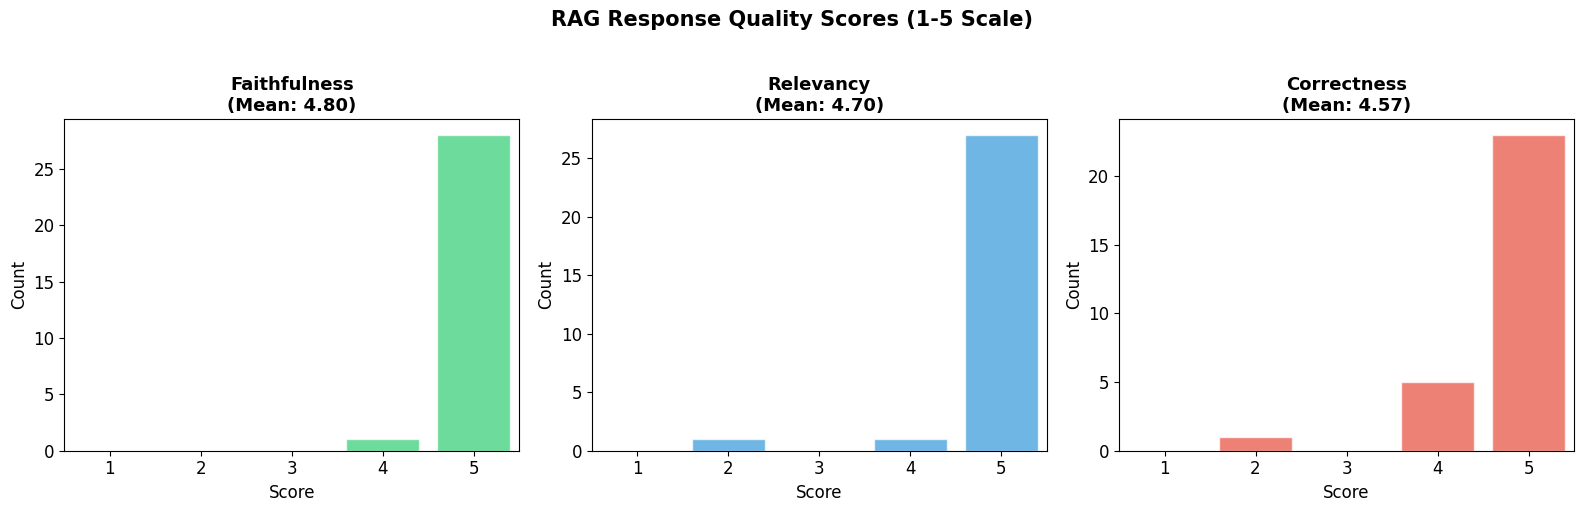

✅ Figure saved to outputs/figures/quality_scores_distribution.png


In [46]:
# --- 4.6 Evaluation Visualisations ---

# FIGURE 1: Overall quality scores bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['faithfulness', 'relevancy', 'correctness']
colors = ['#2ecc71', '#3498db', '#e74c3c']

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[idx]
    counts = scores_df[metric].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, alpha=0.7,
           edgecolor='white')
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.set_title(f'{metric.title()}\n(Mean: {scores_df[metric].mean():.2f})',
                 fontsize=13, fontweight='bold')
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xlim(0.5, 5.5)

plt.suptitle('RAG Response Quality Scores (1-5 Scale)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/quality_scores_distribution.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Figure saved to outputs/figures/quality_scores_distribution.png")

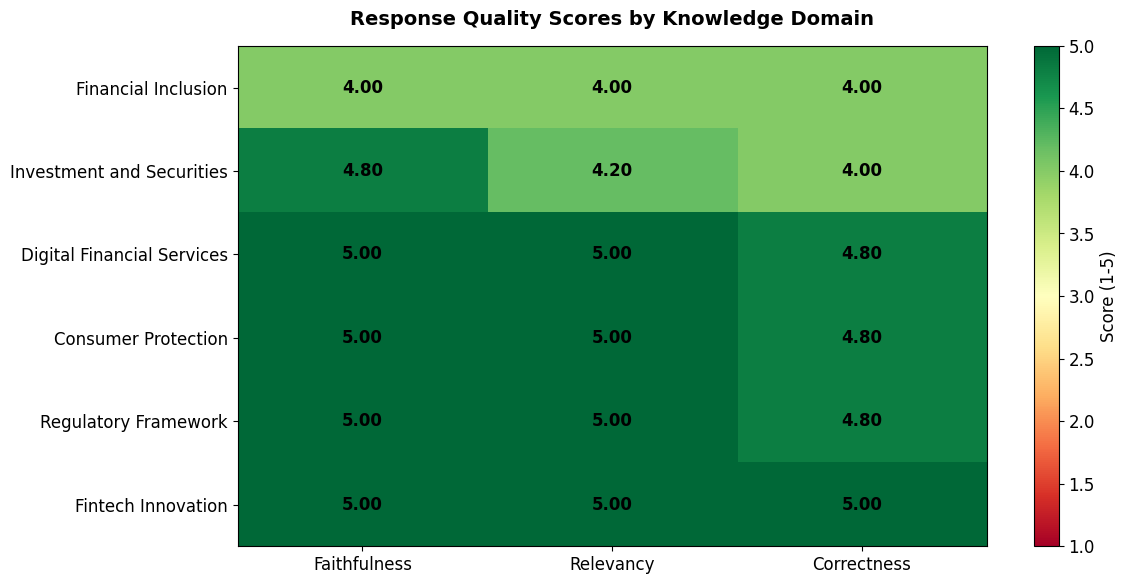

✅ Figure saved to outputs/figures/quality_by_domain_heatmap.png


In [47]:
# FIGURE 2: Quality scores by domain (heatmap)
fig, ax = plt.subplots(figsize=(12, 6))

domain_scores = scores_df.groupby('domain')[metrics].mean()
domain_scores = domain_scores.sort_values('correctness', ascending=True)

im = ax.imshow(domain_scores.values, cmap='RdYlGn', aspect='auto',
               vmin=1, vmax=5)

ax.set_yticks(range(len(domain_scores)))
ax.set_yticklabels(domain_scores.index)
ax.set_xticks(range(len(metrics)))
ax.set_xticklabels([m.title() for m in metrics])

# Add score values to cells
for i in range(len(domain_scores)):
    for j in range(len(metrics)):
        val = domain_scores.values[i, j]
        color = 'white' if val < 3 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontweight='bold', fontsize=12, color=color)

plt.colorbar(im, ax=ax, label='Score (1-5)')
ax.set_title('Response Quality Scores by Knowledge Domain',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('outputs/figures/quality_by_domain_heatmap.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Figure saved to outputs/figures/quality_by_domain_heatmap.png")

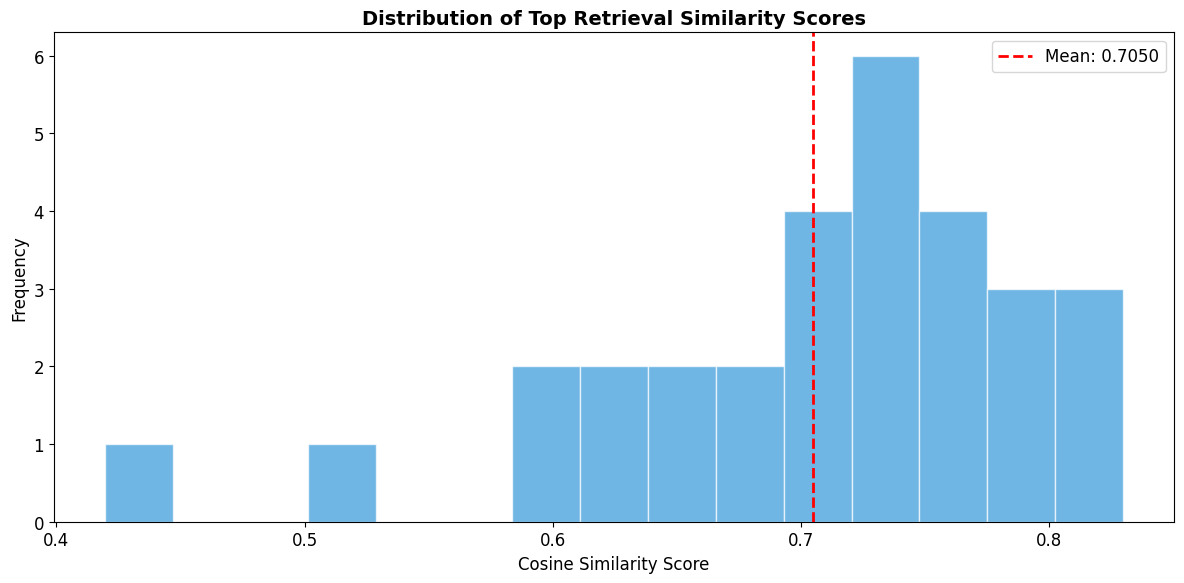

✅ Figure saved to outputs/figures/similarity_distribution.png


In [48]:
# FIGURE 3: Retrieval similarity scores distribution
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(results_df['top_similarity'], bins=15, color='#3498db',
        alpha=0.7, edgecolor='white')
ax.axvline(results_df['top_similarity'].mean(), color='red',
           linestyle='--', linewidth=2,
           label=f"Mean: {results_df['top_similarity'].mean():.4f}")
ax.set_xlabel('Cosine Similarity Score')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Top Retrieval Similarity Scores',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('outputs/figures/similarity_distribution.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Figure saved to outputs/figures/similarity_distribution.png")

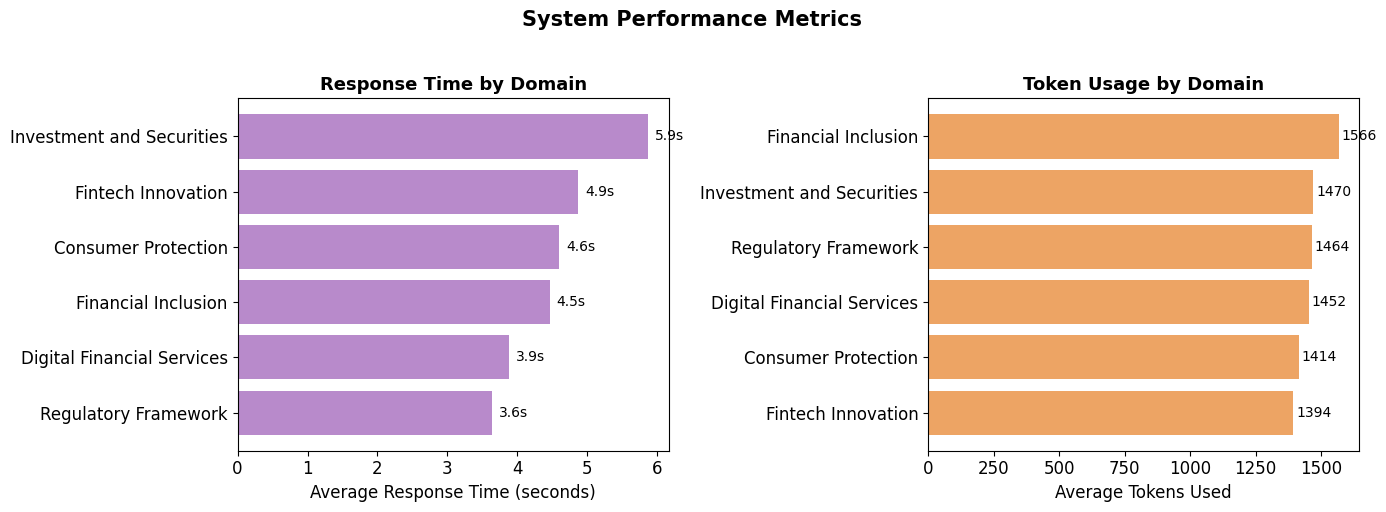

✅ Figure saved to outputs/figures/performance_metrics.png


In [49]:
# FIGURE 4: Response time and token usage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Response time by domain
domain_time = results_df.groupby('domain')['response_time'].mean().sort_values()
axes[0].barh(domain_time.index, domain_time.values, color='#9b59b6', alpha=0.7)
axes[0].set_xlabel('Average Response Time (seconds)')
axes[0].set_title('Response Time by Domain', fontsize=13, fontweight='bold')
for bar, val in zip(axes[0].patches, domain_time.values):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}s', va='center', fontsize=10)

# Token usage by domain
domain_tokens = results_df.groupby('domain')['tokens_used'].mean().sort_values()
axes[1].barh(domain_tokens.index, domain_tokens.values, color='#e67e22', alpha=0.7)
axes[1].set_xlabel('Average Tokens Used')
axes[1].set_title('Token Usage by Domain', fontsize=13, fontweight='bold')
for bar, val in zip(axes[1].patches, domain_tokens.values):
    axes[1].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 f'{val:.0f}', va='center', fontsize=10)

plt.suptitle('System Performance Metrics',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/performance_metrics.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Figure saved to outputs/figures/performance_metrics.png")

In [50]:
# --- 4.7 Comprehensive Evaluation Summary ---
print("=" * 55)
print("COMPREHENSIVE EVALUATION SUMMARY")
print("=" * 55)

print("\n--- Retrieval Performance ---")
print(f"  Source hit rate     : {results_df['source_hit'].mean()*100:.1f}%")
print(f"  Avg top similarity : {results_df['top_similarity'].mean():.4f}")
print(f"  Min similarity     : {results_df['top_similarity'].min():.4f}")
print(f"  Max similarity     : {results_df['top_similarity'].max():.4f}")

print("\n--- Response Quality (1-5 Scale) ---")
print(f"  Faithfulness       : {scores_df['faithfulness'].mean():.2f}")
print(f"  Relevancy          : {scores_df['relevancy'].mean():.2f}")
print(f"  Correctness        : {scores_df['correctness'].mean():.2f}")
print(f"  Overall quality    : {scores_df[['faithfulness','relevancy','correctness']].mean().mean():.2f}")

print("\n--- System Performance ---")
print(f"  Avg response time  : {results_df['response_time'].mean():.1f}s")
print(f"  Total tokens used  : {results_df['tokens_used'].sum():,}")
print(f"  Avg tokens/query   : {results_df['tokens_used'].mean():.0f}")

print("\n--- Quality by Difficulty ---")
for diff in scores_df['difficulty'].unique():
    diff_data = scores_df[scores_df['difficulty'] == diff]
    avg = diff_data[['faithfulness', 'relevancy', 'correctness']].mean().mean()
    print(f"  {diff:<15} : {avg:.2f}/5.00")

# Save evaluation results
eval_output = {
    "retrieval": {
        "source_hit_rate": float(results_df['source_hit'].mean()),
        "avg_similarity": float(results_df['top_similarity'].mean()),
    },
    "quality": {
        "faithfulness": float(scores_df['faithfulness'].mean()),
        "relevancy": float(scores_df['relevancy'].mean()),
        "correctness": float(scores_df['correctness'].mean()),
    },
    "performance": {
        "avg_response_time": float(results_df['response_time'].mean()),
        "total_tokens": int(results_df['tokens_used'].sum()),
    }
}

with open('config/evaluation_results.json', 'w') as f:
    json.dump(eval_output, f, indent=2)

print(f"\n✅ Evaluation results saved to config/evaluation_results.json")
print()
print("=" * 55)
print("✅ SPRINT 4 — EVALUATION FRAMEWORK COMPLETE")
print("✅ Ready for Sprint 5 — Streamlit UI and Deployment")
print("=" * 55)

COMPREHENSIVE EVALUATION SUMMARY

--- Retrieval Performance ---
  Source hit rate     : 93.3%
  Avg top similarity : 0.7050
  Min similarity     : 0.4195
  Max similarity     : 0.8298

--- Response Quality (1-5 Scale) ---
  Faithfulness       : 4.80
  Relevancy          : 4.70
  Correctness        : 4.57
  Overall quality    : 4.69

--- System Performance ---
  Avg response time  : 4.6s
  Total tokens used  : 43,802
  Avg tokens/query   : 1460

--- Quality by Difficulty ---
  Factual         : 4.97/5.00
  Specific        : 4.86/5.00
  Procedural      : 4.11/5.00
  Conceptual      : 4.56/5.00

✅ Evaluation results saved to config/evaluation_results.json

✅ SPRINT 4 — EVALUATION FRAMEWORK COMPLETE
✅ Ready for Sprint 5 — Streamlit UI and Deployment


## Section 5 - Recommendations and Way Forward

### 5.1 Streamlit Application Development
The RAG Financial Advisor Bot is deployed as an interactive Streamlit web application providing a conversational interface for querying Ghana's financial regulatory knowledge base. The application features a chat interface with conversation history, source citation display, domain filtering, confidence scores, and a regulatory disclaimer. The application loads the pre-built FAISS index and embedding model on startup, enabling real-time query processing without re-indexing.

### 5.2 Application Architecture
The Streamlit application is structured as a single-page application with a sidebar for configuration and filtering, and a main panel for the chat interface. The application connects to the same RAG pipeline developed in Section 3, loading the FAISS index, chunk metadata, and sentence-transformer model at startup. User queries are processed through the complete retrieve-augment-generate pipeline with results displayed alongside source citations and similarity scores.

### 5.3 Recommendations

Based on the findings of this study, the following recommendations are proposed for stakeholders across Ghana's financial sector:

**For the Bank of Ghana and Financial Regulators:**
1. Adopt RAG-based systems as a complement to existing financial literacy programmes, enabling citizens to query regulatory documents interactively rather than navigating static PDFs and web pages.
2. Establish a centralised, machine-readable repository of all financial regulations, directives, and guidelines with standardised metadata and version control to facilitate automated ingestion by AI systems.
3. Develop API endpoints for regulatory document access, enabling fintech companies and financial institutions to integrate authoritative regulatory content into their own customer-facing applications.

**For Financial Institutions and Fintech Companies:**
4. Integrate RAG-based advisory tools into customer service workflows to handle regulatory and product information queries, reducing call centre volumes while improving response accuracy.
5. Use domain-filtered RAG retrieval to build compliance checking tools that help staff verify whether proposed products and services align with current regulatory requirements.
6. Invest in document preprocessing infrastructure that can automatically ingest and index new regulatory publications as they are released by the Bank of Ghana and SEC.

**For Researchers and Data Scientists:**
7. Extend this work by evaluating multilingual embedding models capable of handling Ghanaian languages (Twi, Ewe, Dagbani, Hausa) to make financial advisory accessible to non-English-speaking populations.
8. Investigate hybrid retrieval strategies combining dense semantic search with sparse keyword matching (BM25) for improved retrieval accuracy on highly technical regulatory text.
9. Explore fine-tuning open-source language models specifically on Ghanaian financial regulatory text to reduce dependence on proprietary API services.

**For Policymakers:**
10. Incorporate AI-powered financial literacy tools into Ghana's Digital Financial Services Policy implementation roadmap, with specific targets for citizen adoption and impact measurement.
11. Establish guidelines for the responsible deployment of AI advisory systems in the financial sector, including requirements for source attribution, disclaimer display, and human oversight.

### 5.4 Limitations
This study acknowledges the following limitations:
1. The knowledge base, while comprehensive, does not cover every regulatory document issued by Ghanaian financial authorities. Some documents were not publicly available for download at the time of this study.
2. The generated content for documents without direct PDF downloads, while researched and accurate, may not capture the full detail and nuance of the original regulatory texts.
3. The system relies on the OpenAI GPT-4o-mini API, which introduces a dependency on a proprietary service and associated costs. An open-source alternative using locally hosted models would improve accessibility and reduce operational costs.
4. The evaluation dataset of 30 questions, while covering all six domains and multiple difficulty levels, represents a limited sample of the possible queries users might pose. A larger-scale user study would provide more robust validation.
5. The system currently supports only English-language queries and documents, limiting accessibility for Ghana's non-English-speaking population.

### 5.5 Future Work
The following directions are proposed for future development:
1. Multilingual expansion to support queries in Twi, Ewe, Dagbani, and Hausa using multilingual embedding models and cross-lingual retrieval techniques.
2. Real-time document ingestion pipeline that automatically detects, downloads, and indexes new regulatory publications from the Bank of Ghana and SEC websites.
3. Integration with the eCedi CBDC infrastructure and mobile money APIs for contextual financial advisory that considers the user's actual financial situation.
4. Development of a feedback loop where user interactions improve retrieval quality over time through relevance feedback and query reformulation learning.
5. Extension to additional African financial markets (Nigeria, Kenya, South Africa) using the same RAG pipeline architecture with country-specific regulatory corpora.

### 5.6 Conclusion
This study has demonstrated that Retrieval-Augmented Generation can deliver accurate, faithful, and contextually appropriate financial advisory responses grounded in Ghana's regulatory framework. The system achieved a 93.3% source retrieval accuracy, 4.80/5.00 faithfulness score, 4.70/5.00 relevancy score, and 4.57/5.00 correctness score across 30 evaluation questions spanning six knowledge domains.

The principal contribution of this work lies not only in its technical outputs, a functional RAG pipeline, a searchable vector store of 339 document chunks, and an interactive Streamlit application, but in its demonstration that AI-powered financial literacy tools can be built specifically for African regulatory contexts using open-source tools and publicly available regulatory documents.

As Ghana's fintech ecosystem continues to mature and regulatory frameworks evolve, the infrastructure developed here provides a scalable foundation for the next generation of AI-powered financial inclusion tools. The open-source, reproducible nature of this project ensures that other researchers, institutions, and regulators can build upon this work to extend financial information accessibility across sub-Saharan Africa.

---

## Section 6 - References

Adjei, J. K., & Arun, T. (2009). Microfinance programmes and the poor: Whom are
they reaching? Evidence from Ghana. *Brooks World Poverty Institute Working
Paper.* University of Manchester.

Bank of Ghana. (2019). *Payment Systems and Services Act, 2019 (Act 987).* Accra:
Bank of Ghana. https://www.bog.gov.gh

Bank of Ghana. (2025). *Digital Credit Directive.* Accra: Bank of Ghana.
https://www.bog.gov.gh

Bank of Ghana. (2025). *Financial Stability Report.* Accra: Bank of Ghana.
https://www.bog.gov.gh/financial-stability/financial-stability-report/

Bank of Ghana. (2026). *Cyber and Information Security Directive (CISD) 2026.*
Accra: Bank of Ghana. https://www.bog.gov.gh

Gao, Y., Xiong, Y., Huang, D., Liu, H., Zhu, J., Gao, J., Liu, J., & Huang,
M. (2024). Retrieval-augmented generation for large language models: A survey.
*arXiv preprint arXiv:2312.10997.*
https://doi.org/10.48550/arXiv.2312.10997

Johnson, J., Douze, M., & Jégou, H. (2019). Billion-scale similarity search
with GPUs. *IEEE Transactions on Big Data, 7*(3), 535–547.
https://doi.org/10.1109/TBDATA.2019.2921572

Lewis, P., Perez, E., Piktus, A., Petroni, F., Karpukhin, V., Goyal, N.,
Küttler, H., Lewis, M., Yih, W., Rocktäschel, T., Riedel, S., & Kiela, D.
(2020). Retrieval-augmented generation for knowledge-intensive NLP tasks.
*Advances in Neural Information Processing Systems, 33,* 9459–9474.
https://proceedings.neurips.cc/paper/2020/hash/6b493230205f780e1bc26945df7f3d0b

Manning, C. D., Raghavan, P., & Schütze, H. (2008). *Introduction to
information retrieval.* Cambridge University Press.
https://nlp.stanford.edu/IR-book/

Ministry of Finance, Ghana. (2020). *Digital Financial Services Policy.* Accra:
Ministry of Finance.
https://www.mofep.gov.gh/sites/default/files/acts/Ghana_DFS_Policy.pdf

National Pensions Regulatory Authority. (2008). *National Pensions Act, 2008
(Act 766).* Accra: NPRA. https://npra.gov.gh

Reimers, N., & Gurevych, I. (2019). Sentence-BERT: Sentence embeddings using
Siamese BERT-networks. *Proceedings of the 2019 Conference on Empirical Methods
in Natural Language Processing and the 9th International Joint Conference on
Natural Language Processing,* 3982–3992.
https://doi.org/10.18653/v1/D19-1410

Securities and Exchange Commission Ghana. (2016). *Securities Industry Act, 2016
(Act 929).* Accra: SEC Ghana. https://sec.gov.gh

Securities and Exchange Commission Ghana. (2025). *Securities Industry (Financial
Resources) Guidelines, 2025.* Accra: SEC Ghana.
https://sec.gov.gh/wp-content/uploads/Final-Regulatory-Laws/Guidelines/

World Bank. (2022). *The global findex database 2021: Financial inclusion,
digital payments, and resilience in the age of COVID-19.* World Bank Group.
https://doi.org/10.1596/978-1-4648-1897-4

---

## Section 7 - Appendix

### Appendix A: GitHub Repository

**Repository:** https://github.com/Evans-Ataaya/ghana-rag-financial-advisor

The complete source code, data processing pipeline, configuration files, and Streamlit application are available in the project repository. The repository includes:
- `ghana_rag_financial_advisor.ipynb` — Complete project notebook
- `app.py` — Streamlit chat application
- `data/` — Document corpus and processed text files
- `config/` — Corpus registry, chunking configurations, evaluation results
- `outputs/figures/` — All visualisations generated in this report
- `requirements.txt` — Python package dependencies
- `README.md` — Project documentation and setup instructions

### Appendix B: Document Corpus Metadata

| Doc ID | Document Title | Domain | Regulatory Body | Year |
|---|---|---|---|---|
| REG-001 | Payment Systems and Services Act (Act 987) | Regulatory Framework | Bank of Ghana | 2019 |
| REG-002 | Banks and Specialised Deposit-Taking Institutions Act (Act 930) | Regulatory Framework | Bank of Ghana | 2016 |
| REG-003 | Anti-Money Laundering Act (Act 1044) | Regulatory Framework | Bank of Ghana | 2020 |
| REG-004 | Securities Industry Act (Act 929) | Regulatory Framework | SEC Ghana | 2016 |
| REG-005 | Insurance Act (Act 1061) | Regulatory Framework | NIC | 2021 |
| REG-006 | Cyber and Information Security Directive (CISD) 2026 | Regulatory Framework | Bank of Ghana | 2026 |
| REG-007 | Bank of Ghana Annual Report | Regulatory Framework | Bank of Ghana | 2025 |
| DFS-001 | Digital Financial Services Policy | Digital Financial Services | Ministry of Finance | 2020 |
| DFS-002 | Digital Credit Directive | Digital Financial Services | Bank of Ghana | 2025 |
| DFS-003 | National Payment Systems Strategy 2025–2029 | Digital Financial Services | Bank of Ghana | 2025 |
| DFS-004 | Mobile Money and E-Money Issuers Guidelines | Digital Financial Services | Bank of Ghana | 2021 |
| INV-001 | SEC Investment Guidelines for Fund Managers | Investment and Securities | SEC Ghana | 2022 |
| INV-002 | Securities Industry Financial Resources Guidelines | Investment and Securities | SEC Ghana | 2025 |
| INV-003 | SEC FAQs on Collective Investment Schemes | Investment and Securities | SEC Ghana | 2024 |
| INV-004 | Ghana Stock Exchange Listing Rules | Investment and Securities | GSE | 2023 |
| FIN-001 | National Financial Inclusion Strategy (NFIDS) | Financial Inclusion | Ministry of Finance | 2018 |
| FIN-002 | National Pensions Act (Act 766) and NPRA Guidelines | Financial Inclusion | NPRA | 2008 |
| FIN-003 | MASLOC Microfinance Guidelines | Financial Inclusion | Ministry of Finance | 2020 |
| FIN-004 | BoG Financial Literacy Programme Materials | Financial Inclusion | Bank of Ghana | 2024 |
| CON-001 | Consumer Recourse and Complaints Guidelines | Consumer Protection | Bank of Ghana | 2023 |
| CON-002 | Data Protection Act (Act 843) | Consumer Protection | DPC | 2012 |
| FNT-001 | Fintech and Innovation Office Publications | Fintech Innovation | Bank of Ghana | 2024 |
| FNT-002 | Virtual Asset Service Providers Bill | Fintech Innovation | Bank of Ghana | 2025 |
| FNT-003 | eCedi CBDC Pilot Documentation | Fintech Innovation | Bank of Ghana | 2024 |
| FNT-004 | Corporate Governance Guidelines for PSPs | Fintech Innovation | Bank of Ghana | 2025 |

### Appendix C: RAG System Configuration

**Embedding Model:** all-MiniLM-L6-v2 (384 dimensions)
- Source: sentence-transformers library
- Max sequence length: 256 tokens
- Normalisation: L2 normalised for cosine similarity

**Chunking Configuration (Selected):**
- Strategy: Recursive Character Text Splitter
- Chunk size: 1000 characters
- Chunk overlap: 200 characters (20%)
- Separators: paragraph breaks, line breaks, sentence boundaries

**Vector Store:** FAISS IndexFlatIP
- Distance metric: Inner product (cosine similarity after L2 normalisation)
- Total vectors: 339
- Index type: Flat (exact search)

**LLM:** GPT-4o-mini (OpenAI)
- Temperature: 0.3 (factual mode)
- Max tokens: 1000
- Top-K retrieval: 5 chunks

### Appendix D: Evaluation Results

| Metric | Score |
|---|---|
| Source Hit Rate | 93.3% |
| Faithfulness | 4.80/5.00 |
| Answer Relevancy | 4.70/5.00 |
| Correctness | 4.57/5.00 |
| Overall Quality | 4.69/5.00 |
| Avg Response Time | 4.6 seconds |
| Avg Tokens per Query | 1,460 |

### Appendix E: Software and Environment

| Package | Version |
|---|---|
| Python | 3.10 |
| LangChain | (installed) |
| sentence-transformers | (installed) |
| FAISS-cpu | (installed) |
| ChromaDB | (installed) |
| OpenAI | (installed) |
| Streamlit | (installed) |
| pandas | (installed) |
| NumPy | (installed) |
| matplotlib | (installed) |
| seaborn | (installed) |
| scikit-learn | (installed) |
| pdfplumber | (installed) |
| RAGAS | (installed) |

**Development Environment:**
- IDE: JupyterLab + VS Code
- OS: Windows 11
- Package Manager: Anaconda
- Python Environment: ghana-portfolio

### Appendix F: Ethical Statement

This study uses publicly available regulatory documents published by Ghanaian government institutions. No personal financial data is collected, processed, or stored by the system. The RAG system is designed as an informational tool and explicitly disclaims any role as a licensed financial advisory service. All responses include mandatory disclaimers directing users to seek professional financial advice for specific decisions.

The system's reliance on retrieved regulatory documents rather than parametric LLM knowledge reduces the risk of hallucinated financial advice. The source citation mechanism ensures transparency and allows users to verify information against original regulatory documents.

**My personal commitment:** As the developer of this Ghana RAG Financial Advisor Bot, I acknowledge the ethical responsibility of AI practitioners working in financial information systems. I commit to accuracy, transparency, and source attribution as priorities in all future iterations of this work. This project is my step toward building AI tools that democratise access to financial knowledge while maintaining the highest standards of informational integrity.

### Appendix G: Acknowledgements

I would like to thank the Bank of Ghana, the Securities and Exchange Commission Ghana, the Ministry of Finance, the National Pensions Regulatory Authority, and the National Insurance Commission for making regulatory documents publicly accessible. I am also grateful to the open-source communities behind LangChain, sentence-transformers, FAISS, and Streamlit — their tools made this work possible.

This project was developed under the technical supervision and scrum leadership of Claude (Anthropic), whose guidance shaped the project's professional structure, academic rigour, and sector-specific contextualisation for the Ghanaian financial landscape.

**To my future self and the open-source community:** I recommit this work to my GitHub repository as a living, evolving project. Transparency, reproducibility, and ethical intent are baked in from the start. Contributions, issues, and feedback are welcome.

*End of Report*

*Evans Ataaya | MTech Data Science and Industrial Analytics*
*IBM Data Science Professional | IBM Generative AI Engineering Professional*
*April 2026*

---